# Bayesian Framework: Engineering Case Studies
---
**Manuscript Reference:** Section 4 (Subsections 4.4 and 4.5)

**Objective:** 
This notebook contains the validation phase of the framework using applied structural engineering scenarios. It addresses structural parameter identification under epistemic uncertainty from dynamic properties and handles physical material variability through an advanced Hierarchical Stochastic Model (HSM).

To ensure a fully self-contained execution without external file dependencies, all data arrays are defined directly within the code cells.

---
## 1. Case Study 1: Operational Modal Analysis and Stiffness Identification (Section 4.4)
Structural parameter identification and structural engineering inversion based on dynamic properties (frequencies and mode shapes).

## 2. Case Study 2: Hierarchical Steel4 Calibration (Section 4.5)
Calibration of a non-linear hysteretic constitutive material under physical variability using an advanced Hierarchical Stochastic Model (HSM). Experimental data from six physical tensile tests is embedded directly within this script as NumPy arrays.

## Librerias

Installing Libraries

In [1]:
# !pip install numpy matplotlib pymc arviz pandas xarray openseespy

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import math

from matplotlib.ticker import MultipleLocator
import openseespy.opensees as ops

Plotting Configuration

In [3]:
plt.rcParams.update(plt.rcParamsDefault)

plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({"axes.grid" : True, "grid.color": "0.8","lines.color": "k", "grid.linewidth": 0.5, "axes.edgecolor": "0.8", 'font.size': 20,
                    'xtick.minor.bottom': True, 'ytick.minor.left': True, 'xtick.bottom': True, 'ytick.left': True,
                     "font.family": "STIXGeneral", "mathtext.fontset": "stix"})

# Configurar rcParams para tick marks
# plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'out'
# plt.rcParams['xtick.major.size'] = 4
# plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['ytick.major.width'] = 1
# plt.rcParams['xtick.minor.size'] = 2
# plt.rcParams['xtick.minor.width'] = 0.5
# plt.rcParams['ytick.minor.size'] = 4
# plt.rcParams['ytick.minor.width'] = 1

# Case Study 1: Operational Modal Analysis and Stiffness Identification (Section 4.4)

In [ ]:
P = np.arange(0, 51, 0.1)

In [ ]:
def Three_Story_Shear_Frame(input):

    E = input[0]

    # ------------------------------
    # Start of model generation
    # -----------------------------
    # Remove existing model
    wipe()
    # Set modelbuilder
    model('basic', '-ndm', 2, '-ndf', 3)

    h = 144
    L = 2*h

    # create nodes
    node(1, 0.0, 0.0)
    node(2, L, 0.0)
    node(3, 0.0, h)
    node(4, L, h)
    node(5, 0.0, 2*h)
    node(6, L, 2*h)
    node(7, 0.0, 3*h)
    node(8, L, 3*h)

    # Single point constraints -- Boundary Conditions

    fix(1, 1, 1, 1)
    fix(2, 1, 1, 1)

    # MP constraints
    equalDOF(3, 4, 2, 3)
    equalDOF(5, 6, 2, 3)
    equalDOF(7, 8, 2, 3)

    # Define materials
    uniaxialMaterial("Elastic", 1, E)

    # Define geometric transform
    geomTransf('Linear', 1, 0, 0, 1);
    # Define mass

    m = 100.0/386.0

    mass(3, m, 0.0, 0.0)
    mass(4, m, 0.0, 0.0)
    mass(5, m/2, 0.0, 0.0)
    mass(6, m/2, 0.0, 0.0)
    mass(7, m/2, 0.0, 0.0)
    mass(8, m/2, 0.0, 0.0)

    # Define elements

    # Columns

    Ac = 63.41
    Ic = 320.0

    element('elasticBeamColumn', 1, 1, 3, Ac, E, 2*Ic, 1)
    element('elasticBeamColumn', 2, 3, 5, Ac, E, Ic, 1)
    element('elasticBeamColumn', 3, 5, 7, Ac, E, Ic, 1)

    element('elasticBeamColumn', 4, 2, 4, Ac, E, 2*Ic, 1)
    element('elasticBeamColumn', 5, 4, 6, Ac, E, Ic, 1)
    element('elasticBeamColumn', 6, 6, 8, Ac, E, Ic, 1)

    # Beams

    Ib = 10e+12
    Ab = 63.41

    element('elasticBeamColumn', 7, 3, 4, Ab, E, Ib, 1)
    element('elasticBeamColumn', 8, 5, 6, Ab, E, Ib, 1)
    element('elasticBeamColumn', 9, 7, 8, Ab, E, Ib, 1)

    # Eigen Analysis -------------------------------------------------------------
    # Natural frequencies
    numModes = 5
    M_Lambda = eigen('-generalized','-fullGenLapack',numModes)
    F = [];

    for f in range(len(M_Lambda)):
        F.append(math.sqrt(M_Lambda[f])/(2*math.pi));
    F = np.transpose(np.array(F))

    Mode_1 = []

    Mode_1.append(nodeEigenvector(1, 1, 1))
    Mode_1.append(nodeEigenvector(2, 1, 1))
    Mode_1.append(nodeEigenvector(3, 1, 1))
    Mode_1.append(nodeEigenvector(4, 1, 1))
    Mode_1.append(nodeEigenvector(5, 1, 1))
    Mode_1.append(nodeEigenvector(6, 1, 1))
    Mode_1.append(nodeEigenvector(7, 1, 1))
    Mode_1.append(nodeEigenvector(8, 1, 1))

    Mode_2 = []

    Mode_2.append(nodeEigenvector(1, 2, 1))
    Mode_2.append(nodeEigenvector(2, 2, 1))
    Mode_2.append(nodeEigenvector(3, 2, 1))
    Mode_2.append(nodeEigenvector(4, 2, 1))
    Mode_2.append(nodeEigenvector(5, 2, 1))
    Mode_2.append(nodeEigenvector(6, 2, 1))
    Mode_2.append(nodeEigenvector(7, 2, 1))
    Mode_2.append(nodeEigenvector(8, 2, 1))

    Mode_3 = []

    Mode_3.append(nodeEigenvector(1, 3, 1))
    Mode_3.append(nodeEigenvector(2, 3, 1))
    Mode_3.append(nodeEigenvector(3, 3, 1))
    Mode_3.append(nodeEigenvector(4, 3, 1))
    Mode_3.append(nodeEigenvector(5, 3, 1))
    Mode_3.append(nodeEigenvector(6, 3, 1))
    Mode_3.append(nodeEigenvector(7, 3, 1))
    Mode_3.append(nodeEigenvector(8, 3, 1))

    Mode_1 = np.array(Mode_1)
    Mode_2 = np.array(Mode_2)
    Mode_3 = np.array(Mode_3)

    Var_Mod = np.hstack((F, Mode_1))
    Var_Mod = np.hstack((Var_Mod, Mode_2))
    Var_Mod = np.hstack((Var_Mod, Mode_3))

    Var_Mod = Var_Mod.flatten()
    Var_Mod = Var_Mod.T

    return F

In [ ]:
E_real = [26000] # MPa
Var_Mod = Three_Story_Shear_Frame(E_real)
Var_Mod

In [ ]:
sigmaMod = 0.2
noiseMod = np.random.randn(Var_Mod.size)*sigmaMod
data = Var_Mod_Exp

## Loglike function

In [ ]:
def loglikeBuilding(theta, sigma0, P, data):#, sigma):
  # data: Datos observados
  # theta: Vector de parámetros a ajustar
  # model = runAnalizePYMC(P, theta[:-1], theta[-1])
  model = Three_Story_Shear_Frame(theta)
  sigma = sigma0
  try:
    log = -np.sum(0.5 * (np.log(2 * np.pi * sigma ** 2) + ((data - model) / sigma) ** 2))
  except:
    log = -np.sum(0.5 * (np.log(2 * np.pi * sigma ** 2) + ((data - 0) / sigma) ** 2))
  return log

## PYMC Model

In [ ]:
logl = LogLike(loglikeBuilding, data, P)
with pm.Model() as m_Building:
  E = pm.Normal('E', mu=28e3 , sigma= 2e3)
  sigma = pm.HalfNormal('sigma')
  theta = pt.as_tensor_variable([E])
  ## -------------------------- LIKELIHOOD --------------------------
  pm.Potential("likelihood", logl(theta, sigma))
  ## -------------------------- STEP AND SAMPLE --------------------------
  # idata = pm.sample(chains = 2)
  idata = pm.sample(1000, tune=500)

## Plot results

In [ ]:
# Initialize an empty list to store the first value of each result vector
values1 = []
values2 = []
values3 = []
values4 = []
values5 = []

In [ ]:
fig = plt.figure(figsize=(10,5))

# # Primer subgráfico
# plt.subplot(1, 3, 1)

ax1 = az.plot_dist(values1, rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('$f_1$ [Hz]', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([1.28, 1.32])
plt.ylim([0, 200])

ax1.grid(which='minor', alpha=0.2)
ax1.yaxis.grid(True, which='minor')
ax1.xaxis.set_minor_locator(MultipleLocator(0.001))
ax1.yaxis.set_minor_locator(MultipleLocator(10))

# Add vertical line at nominal value 1.30
plt.axvline(x=1.29287131, color='gray', linestyle='--')
plt.text(1.29287131*0.9999, 100, '1.293 Hz', rotation=90, verticalalignment='bottom', horizontalalignment='right', fontsize=30, color='gray')

plt.show()

# # Segundo  subgráfico
# plt.subplot(1, 3, 2)

fig = plt.figure(figsize=(10,5))

ax2 = az.plot_dist(values2, rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('$f_2$ [Hz]', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([2.95, 3.03])
plt.ylim([0, 75])

ax2.grid(which='minor', alpha=0.2)
ax2.yaxis.grid(True, which='minor')
ax2.xaxis.set_minor_locator(MultipleLocator(0.005))
ax2.yaxis.set_minor_locator(MultipleLocator(5))

# Add vertical line at nominal value 1.30
plt.axvline(x=2.97692874, color='gray', linestyle='--')
plt.text(2.97692874*0.9999, 40, '2.977 Hz', rotation=90, verticalalignment='bottom', horizontalalignment='right', fontsize=30, color='gray')

plt.show()

# # Tercer subgráfico
# plt.subplot(1, 3, 2)

fig = plt.figure(figsize=(10,5))

ax2 = az.plot_dist(values3, rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('$f_3$ [Hz]', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([4.3, 4.45])
plt.ylim([0, 60])

ax2.grid(which='minor', alpha=0.2)
ax2.yaxis.grid(True, which='minor')
ax2.xaxis.set_minor_locator(MultipleLocator(0.005))
ax2.yaxis.set_minor_locator(MultipleLocator(5))

# Add vertical line at nominal value 1.30
plt.axvline(x=4.34637316, color='gray', linestyle='--')
plt.text(4.34637316*0.9999, 30, '4.346 Hz', rotation=90, verticalalignment='bottom', horizontalalignment='right', fontsize=30, color='gray')

plt.show()


# # Cuatro  subgráfico
# plt.subplot(1, 3, 3)

fig = plt.figure(figsize=(10,5))

ax3 = az.plot_dist(values4, rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('$f_4$ [Hz]', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([33.2, 34.4])
plt.ylim([0, 6])

ax3.grid(which='minor', alpha=0.2)
ax3.yaxis.grid(True, which='minor')
ax3.xaxis.set_minor_locator(MultipleLocator(0.05))
ax3.yaxis.set_minor_locator(MultipleLocator(0.5))

# Add vertical line at nominal value 1.30
plt.axvline(x=33.65635633, color='gray', linestyle='--')
plt.text(33.65635633*0.9999, 1, '33.656 Hz', rotation=90, verticalalignment='bottom', horizontalalignment='right', fontsize=30, color='gray')

plt.show()

# # Quinto  subgráfico
# plt.subplot(1, 3, 3)

fig = plt.figure(figsize=(10,5))

ax5 = az.plot_dist(values5, rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('$f_5$ [Hz]', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([46.75, 48.25])
plt.ylim([0, 6])

ax5.grid(which='minor', alpha=0.2)
ax5.yaxis.grid(True, which='minor')
ax5.xaxis.set_minor_locator(MultipleLocator(0.1))
ax5.yaxis.set_minor_locator(MultipleLocator(0.5))

# Add vertical line at nominal value 1.30
plt.axvline(x=47.34299104, color='gray', linestyle='--')
plt.text(47.34299104*0.9999, 2.5, '47.343 Hz', rotation=90, verticalalignment='bottom', horizontalalignment='right', fontsize=30, color='gray')

# Ajustar el diseño de los subgráficos
plt.tight_layout()
plt.show()


# Case Study 2: Hierarchical Steel4 Calibration (Section 4.5)

## Data

In [4]:
Data = {
    0: {
            'Esf': [0.2887526454373053, 30.300906854306806, 59.07594990737381, 85.77963248142413, 110.0945025235975, 132.22925108948982, 152.76341756858514, 172.4055111248272, 191.76942418728322, 211.25046663794419, 231.02376212393438, 251.12585868501193, 271.5461106013456, 292.26231312224064, 313.19755356694577, 334.1278202964179, 354.6045928975606, 373.9558495943598, 391.3934526971216, 406.2025325925328, 417.9449177599144, 426.5949499204549, 432.549094111198, 436.50056401818006, 439.22471842843606, 441.3564063591576, 443.2417074595489, 444.91378787968097, 446.19071605373125, 446.84462620939615, 446.76673874049175, 446.0605220140033, 445.0303257527104, 444.07849815481023, 443.5604336053466, 443.6599085841474, 444.33341469935704, 445.34034807247275, 446.3407889169795, 447.01863074740294, 447.1830259872598, 446.81479176612385, 446.04873868112423, 445.10713066451893, 444.21467192607923, 443.5273897986126, 443.0978900388842, 442.88308043017355, 442.78436318031123, 442.700067782951, 442.5682522574783, 442.3843871281518, 442.18971334959207, 442.03784749662054, 441.9553562342247, 441.9138909125194, 441.82664517227533, 441.5722630676813, 441.0384500889339, 440.16945734035204, 438.9993623829288, 437.65754040669043, 436.3422575395055, 435.26940063500047, 434.6120146642169, 434.44967810102787, 434.7439817528868, 435.3486933809108, 436.05305070872936, 436.64678100176565, 436.98831028142814, 437.05508059091295, 436.95818285101626, 436.9128211022899, 437.1698563876558, 437.9280239285425, 439.2559901987736, 441.0532734746714, 443.0673791238958, 444.96445394117313, 446.4299939768073, 447.2636991556118, 447.4344958447571, 447.0777222577407, 446.4395569944167, 445.7936598797169, 445.3630807109774, 445.27404061098946, 445.5513825664556, 446.1469306363479, 446.98023813565766, 447.97068433728225, 449.0492763568034, 450.1519956114667, 451.20696746506036, 452.13018344905817, 452.8383659575186, 453.2765655864314, 453.4482368736515, 453.4320785713292, 453.3746719964588, 453.4584520688986, 453.8554252997106, 454.6828977328995, 455.9757121692122, 457.6816161759468, 459.6769243011046, 461.79347262812723, 463.847455762878, 465.66494350857965, 467.10395007082906, 468.07505066426717, 468.56029648848363, 468.62547752942913, 468.41761684435636, 468.14138239568274, 468.0153196644258, 468.21825459363924, 468.8427232865731, 469.87173992286176, 471.1871536409245, 472.6059460550679, 473.93089610553625, 474.99870207372993, 475.71270957338174, 476.0556037370961, 476.0847401334776, 475.9156489402749, 475.69771522708425, 475.5834108043266, 475.6925963875288, 476.077654219738, 476.7009492839564, 477.438234736711, 478.11594522046744, 478.57698656113115, 478.75403515017257, 478.7198829646709, 478.68782149131675, 478.9524311094159, 479.78611543903656, 481.32815190746817, 483.51031968583817, 486.05175803846197, 488.5297368671589, 490.5035510038869, 491.64844598186676, 491.85354248729794, 491.25228424863104, 490.1787039728668, 489.06727575084483, 488.3297180010766, 488.24541127801695, 488.89480641545174, 490.15163487676665, 491.7340201795682, 493.29949559349484, 494.55662040456843, 495.35918052375496, 495.7513146046425, 495.94541089000234, 496.23725395675496, 496.8873950720746, 498.01366899725707, 499.5385554629077, 501.2149429880466, 502.7220327635348, 503.7932085887265, 504.32332024380787, 504.4109191928311, 504.31826361465767, 504.3663795647849, 504.80909737615775, 505.73760032561364, 507.05306634783136, 508.5161425676106, 509.8507963588462, 510.85930421594213, 511.50253003439275, 511.915165895823, 512.3519973713753, 513.0874839555916, 514.3069591473693, 516.028443469543, 518.0808227139196, 520.1435162318987, 521.8330265723995, 522.8092821609264, 522.8717791583002, 522.0206923931744, 520.4679970271804, 518.5952157730266, 516.8660525011259, 515.7130478167855, 515.4260319861341, 516.0736946270687, 517.4846498269817, 519.2993544327902, 521.0816929649391, 522.4562625939922, 523.2241574034674, 523.4141565375867, 523.2488613906603, 523.039014395294, 523.049950210067, 523.3973571180944, 524.0175097220495, 524.7236805592067, 525.320271078026, 525.7185041611604, 525.9964465009261, 526.3731092454066, 527.1085871958959, 528.3785933817697, 530.1838686666678, 532.3367999875044, 534.52898734697, 536.4448068839965, 537.8669788573806, 538.7292578100394, 539.1017223400079, 539.1281002633026, 538.9541169400911, 538.6825522977956, 538.3693823072805, 538.0501019830614, 537.7704432467524, 537.5978646646298, 537.6056587432748, 537.8396981898885, 538.2881741174809, 538.8725162438773, 539.4659233456498, 539.9321857421797, 540.1691093145957, 540.1409961577041, 539.8913367633692, 539.5351961489555, 539.2362709197664, 539.1747705653981, 539.5108758561755, 540.3476716721052, 541.6990752756953, 543.4715285756203, 545.4698278210594, 547.4339150867962, 549.1036808945174, 550.2957451749729, 550.9659929259028, 551.2309024831816, 551.3325543437119, 551.5537392389509, 552.1121161855332, 553.0750070975622, 554.3314761366054, 555.6359683886658, 556.706968600871, 557.3390946221451, 557.4802706979237, 557.2412556953899, 556.8358758586774, 556.4819198549596, 556.3094621581367, 556.3175661412076, 556.3955262880875, 556.3939667213687, 556.2094108170069, 555.8429701450434, 555.4091637217118, 555.0953181473506, 555.0930302644393, 555.5316993763648, 556.4384484412354, 557.7341527179103, 559.2601723975143, 560.8214290585559, 562.2306906306462, 563.3438200702004, 564.0818190164665, 564.4393804839311, 564.4807466028512, 564.3236387185743, 564.112954880573, 563.9884220376272, 564.053134520733, 564.350787572779, 564.857242602277, 565.4876131946779, 566.1156065127675, 566.5995910216595, 566.8104209986658, 566.6581532473346, 566.1162522873907, 565.2411840370336, 564.182703039125, 563.1776269336273, 562.5200933343083, 562.5060108979043, 563.3584378538967, 565.1512840132252, 567.7564592800214, 570.8394669698902, 573.9175413745917, 576.4740828964557, 578.0997996978863, 578.6145540936116, 578.1236875502884, 576.982077679122, 575.6729470296964, 574.6431606518677, 574.156701807766, 574.2227976765472, 574.6254929007866, 575.0396702749908, 575.1830503086209, 574.9403174003991, 574.4097070048273, 573.8569858670902, 573.600808981528, 573.8800021374402, 574.7571407180008, 576.0941996304314, 577.6047274835099, 578.9568970851443, 579.8848549033061, 580.2673499251919, 580.1499360663562, 579.7112780253765, 579.1945157930949, 578.8333004847971, 578.7970715509322, 579.1659511879475, 579.9307175600715, 581.005499417552, 582.2431356988918, 583.45223075894, 584.4231919174108, 584.970795133616, 584.9911011540272, 584.5158626332808, 583.7375185504602, 582.9810587012413, 582.6174616479096, 582.9402422486079, 584.0489637199134, 585.7888473080698, 587.7786085733356, 589.5248939540859, 590.5854996601568, 590.7213713854449, 589.9797804179036, 588.6774992587048, 587.2917869348639, 586.3016771429228, 586.0381640379252, 586.5940843600819, 587.8181552853376, 589.3853275389398, 590.9107397554228, 592.0653638179189, 592.6583643742712, 592.6682662418486, 592.2237693698671, 591.5487055192646, 590.8914507737267, 590.4582031593287, 590.3649234047962, 590.617078673053, 591.1206394174268, 591.7216688369621, 592.2648857984739, 592.654749099182, 592.8986588526471, 593.114141350204, 593.4920348168916, 594.2237238786482, 595.4165258020286, 597.0299077348625, 598.8609231787657, 600.5901481806106, 601.8757793049157, 602.463479180743, 602.2720631942644, 601.4237266751248, 600.2084194450348, 598.9960365195672, 598.1274006021576, 597.8195409302773, 598.112623582819, 598.8701912873486, 599.8279450596483, 600.6742768566883, 601.1400355981348, 601.0748962533225, 600.4917205371243, 599.5674725078953, 598.5990825517305, 597.92410078593, 597.8266194280724, 598.4552304775212, 599.778516091061, 601.5936882220212, 603.5876630384289, 605.4321262914627, 606.8813206976332, 607.8386190317156, 608.3675195023332, 608.6422175048191, 608.8559254982304, 609.1229086169959, 609.4149770979951, 609.5615526980695, 609.3176911048249, 608.4760582915486, 606.9788796248724, 604.9835450896741, 602.8526384901955, 601.0686602839279, 600.1028761153083, 600.2840657962493, 601.7102185590876, 604.2271398543768, 607.4723386460497, 610.9620771898983, 614.1916707110131, 616.7243298489213, 618.2559730713377, 618.6542738562981, 617.9743327387323, 616.4510091821695, 614.4641703869418, 612.4739626246492, 610.9313061219726, 610.1811252600928, 610.3851128849271, 611.4899992888404, 613.2540792906273, 615.323772119167, 617.3328281234865, 618.9889518030051, 620.1202175226504, 620.6730265745286, 620.6748279971479, 620.1879030636333, 619.2794133012593, 618.0194307572775, 616.5008443337895, 614.8625093168531, 613.2958039613615, 612.0243920971195, 611.2613454090141, 611.1589712586182, 611.7695173393404, 613.0293033321601, 614.7690643087537, 616.7449208442289, 618.6808009813606, 620.3140175413022, 621.4381023971856, 621.9380049764035, 621.811809341263, 621.1723245327541, 620.2242123786322, 619.2188791775519, 618.3979826653172, 617.942425529045, 617.9428451334084, 618.3990520073196, 619.2434074380876, 620.3733523896009, 621.6767254648516, 623.0410256332682, 624.3497792277985, 625.4781817074279, 626.3004862210381, 626.7129654794569, 626.6642296029275, 626.177129240805, 625.3485845526199, 624.3245349896729, 623.2603136976835, 622.2841693773979, 621.4789962950751, 620.8864215675942, 620.5249833037749, 620.4075629453569, 620.5459947892655, 620.9406266120891, 621.563280541074, 622.3472012161775, 623.1943679994988, 624.0010231752536, 624.691809669123, 625.2471362308823, 625.7102639988153, 626.1692012656831, 626.7196969505223, 627.4242699793459, 628.2844482156987, 629.2382589117951],
            'def': [1.5384571523205649e-06, 0.00011716455408333034, 0.00023258185978685742, 0.0003479725175602444, 0.00046345450155891156, 0.0005790575873092036, 0.0006947471773189255, 0.0008104658850611359, 0.0009261676440691182, 0.0010418327943812998, 0.0011574655634966145, 0.0012730823328901278, 0.0013886995554709492, 0.001504326658731757, 0.0016199649120106198, 0.0017356102682824794, 0.0018512573097095076, 0.0019669021439345257, 0.00208254344266697, 0.0021981819477128167, 0.0023138192928989785, 0.0024294569319413873, 0.0025450955887944124, 0.0026607352496593965, 0.0027763754752044784, 0.002892015765943157, 0.0030076558017574652, 0.0031232955049326303, 0.0032389349729000944, 0.0033545743636715208, 0.00347021380281559, 0.0035858533429907378, 0.0037014929715964494, 0.0038171326432792124, 0.003932772313011663, 0.0040484119552981705, 0.004164051567017217, 0.004279691159473152, 0.004395330747551352, 0.004510970341837641, 0.004626609945856316, 0.004742249557488055, 0.004857889172223308, 0.004973528786091675, 0.005089168397143508, 0.005204808005448404, 0.005320447612226981, 0.0054360872188487066, 0.005551726826181861, 0.005667366434428653, 0.005783006043314897, 0.0058986456524055715, 0.0060142852613584525, 0.006129924870032585, 0.0062455644784652695, 0.006361204086782031, 0.006476843695106071, 0.006592483303506318, 0.006708122911990347, 0.006823762520526604, 0.006939402129074198, 0.007055041737604348, 0.007170681346107716, 0.007286320954590342, 0.007401960563064669, 0.007517600171541537, 0.007633239780026195, 0.007748879388518363, 0.00786451899701466, 0.007980158605511331, 0.00809579821400602, 0.0082114378224982, 0.00832707743098864, 0.008442717039478534, 0.00855835664796882, 0.008673996256459874, 0.008789635864951587, 0.008905275473443611, 0.009020915081935612, 0.009136554690427403, 0.009252194298918963, 0.009367833907410378, 0.009483473515901763, 0.009599113124393195, 0.009714752732884703, 0.00983039234137627, 0.009946031949867862, 0.010061671558359448, 0.010177311166851014, 0.010292950775342558, 0.01040859038383409, 0.010524229992325619, 0.010639869600817153, 0.010755509209308694, 0.010871148817800241, 0.01098678842629179, 0.01110242803478334, 0.01121806764327489, 0.011333707251766438, 0.011449346860257984, 0.011564986468749528, 0.011680626077241074, 0.011796265685732624, 0.011911905294224171, 0.012027544902715718, 0.01214318451120726, 0.012258824119698796, 0.012374463728190328, 0.012490103336681862, 0.012605742945173401, 0.012721382553664947, 0.012837022162156498, 0.01295266177064805, 0.0130683013791396, 0.013183940987631147, 0.013299580596122686, 0.013415220204614222, 0.013530859813105759, 0.013646499421597302, 0.01376213903008885, 0.013877778638580399, 0.013993418247071948, 0.014109057855563498, 0.014224697464055042, 0.014340337072546583, 0.014455976681038124, 0.014571616289529667, 0.014687255898021211, 0.014802895506512759, 0.014918535115004307, 0.015034174723495851, 0.015149814331987392, 0.015265453940478933, 0.015381093548970475, 0.01549673315746202, 0.015612372765953567, 0.01572801237444512, 0.01584365198293667, 0.01595929159142821, 0.016074931199919748, 0.01619057080841129, 0.01630621041690283, 0.01642185002539437, 0.016537489633885908, 0.01665312924237745, 0.016768768850868997, 0.01688440845936054, 0.01700004806785208, 0.017115687676343624, 0.017231327284835174, 0.017346966893326717, 0.01746260650181826, 0.017578246110309795, 0.017693885718801334, 0.01780952532729288, 0.017925164935784436, 0.01804080454427599, 0.018156444152767542, 0.018272083761259092, 0.018387723369750635, 0.018503362978242174, 0.018619002586733713, 0.018734642195225252, 0.018850281803716798, 0.018965921412208344, 0.019081561020699887, 0.019197200629191433, 0.01931284023768298, 0.019428479846174518, 0.019544119454666064, 0.019659759063157613, 0.019775398671649163, 0.01989103828014071, 0.02000667788863225, 0.02012231749712379, 0.02023795710561533, 0.020353596714106872, 0.020469236322598422, 0.02058487593108998, 0.020700515539581528, 0.020816155148073067, 0.020931794756564603, 0.021047434365056142, 0.021163073973547684, 0.02127871358203923, 0.02139435319053078, 0.02150999279902233, 0.02162563240751388, 0.021741272016005418, 0.021856911624496954, 0.021972551232988496, 0.022088190841480042, 0.02220383044997159, 0.02231947005846313, 0.022435109666954674, 0.022550749275446213, 0.02266638888393775, 0.02278202849242928, 0.022897668100920816, 0.023013307709412362, 0.023128947317903915, 0.023244586926395472, 0.02336022653488703, 0.02347586614337858, 0.023591505751870127, 0.02370714536036167, 0.023822784968853206, 0.023938424577344738, 0.02405406418583628, 0.02416970379432783, 0.024285343402819383, 0.024400983011310936, 0.024516622619802482, 0.024632262228294018, 0.02474790183678555, 0.024863541445277082, 0.024979181053768618, 0.025094820662260167, 0.02521046027075172, 0.025326099879243273, 0.02544173948773482, 0.025557379096226355, 0.025673018704717877, 0.0257886583132094, 0.025904297921700938, 0.026019937530192487, 0.026135577138684044, 0.026251216747175603, 0.026366856355667163, 0.02648249596415872, 0.026598135572650266, 0.02671377518114179, 0.026829414789633313, 0.02694505439812485, 0.027060694006616398, 0.027176333615107958, 0.02729197322359952, 0.027407612832091078, 0.02752325244058262, 0.027638892049074153, 0.027754531657565678, 0.027870171266057214, 0.027985810874548763, 0.02810145048304032, 0.02821709009153188, 0.028332729700023433, 0.02844836930851498, 0.028564008917006514, 0.02867964852549805, 0.028795288133989586, 0.028910927742481125, 0.02902656735097266, 0.029142206959464192, 0.029257846567955725, 0.029373486176447264, 0.029489125784938813, 0.029604765393430377, 0.02972040500192195, 0.02983604461041352, 0.029951684218905074, 0.030067323827396603, 0.030182963435888114, 0.03029860304437963, 0.030414242652871157, 0.030529882261362697, 0.030645521869854253, 0.03076116147834582, 0.030876801086837397, 0.030992440695328964, 0.031108080303820514, 0.031223719912312046, 0.03133935952080356, 0.031454999129295065, 0.031570638737786594, 0.03168627834627814, 0.03180191795476971, 0.03191755756326127, 0.03203319717175282, 0.032148836780244355, 0.032264476388735905, 0.03238011599722747, 0.03249575560571904, 0.03261139521421059, 0.03272703482270211, 0.032842674431193625, 0.03295831403968515, 0.0330739536481767, 0.03318959325666825, 0.0333052328651598, 0.03342087247365135, 0.033536512082142915, 0.0336521516906345, 0.03376779129912607, 0.03388343090761762, 0.03399907051610915, 0.034114710124600656, 0.034230349733092136, 0.034345989341583616, 0.03446162895007514, 0.03457726855856671, 0.0346929081670583, 0.034808547775549877, 0.034924187384041426, 0.03503982699253297, 0.03515546660102451, 0.03527110620951606, 0.03538674581800761, 0.035502385426499146, 0.035618025034990675, 0.03573366464348221, 0.03584930425197375, 0.035964943860465295, 0.03608058346895683, 0.03619622307744837, 0.0363118626859399, 0.03642750229443144, 0.036543141902922995, 0.03665878151141456, 0.03677442111990611, 0.036890060728397636, 0.037005700336889165, 0.03712133994538071, 0.037236979553872264, 0.03735261916236382, 0.03746825877085537, 0.03758389837934691, 0.037699537987838455, 0.03781517759633001, 0.03793081720482157, 0.038046456813313125, 0.03816209642180468, 0.03827773603029623, 0.03839337563878777, 0.0385090152472793, 0.03862465485577083, 0.038740294464262366, 0.038855934072753895, 0.03897157368124542, 0.03908721328973694, 0.039202852898228474, 0.03931849250672004, 0.03943413211521161, 0.03954977172370317, 0.03966541133219472, 0.03978105094068626, 0.03989669054917781, 0.04001233015766936, 0.04012796976616091, 0.040243609374652455, 0.04035924898314398, 0.040474888591635505, 0.04059052820012704, 0.0407061678086186, 0.04082180741711017, 0.04093744702560173, 0.04105308663409326, 0.041168726242584774, 0.0412843658510763, 0.04140000545956784, 0.041515645068059374, 0.04163128467655092, 0.04174692428504246, 0.041862563893534, 0.04197820350202555, 0.04209384311051711, 0.04220948271900867, 0.04232512232750024, 0.04244076193599179, 0.04255640154448332, 0.04267204115297484, 0.042787680761466364, 0.042903320369957906, 0.04301895997844946, 0.04313459958694101, 0.043250239195432555, 0.043365878803924104, 0.04348151841241567, 0.043597158020907224, 0.04371279762939876, 0.04382843723789029, 0.04394407684638182, 0.044059716454873346, 0.04417535606336489, 0.044290995671856445, 0.04440663528034801, 0.044522274888839565, 0.04463791449733111, 0.04475355410582264, 0.044869193714314186, 0.044984833322805735, 0.045100472931297285, 0.04521611253978882, 0.04533175214828035, 0.04544739175677189, 0.04556303136526346, 0.04567867097375504, 0.045794310582246596, 0.04590995019073812, 0.04602558979922963, 0.046141229407721175, 0.04625686901621274, 0.0463725086247043, 0.04648814823319586, 0.046603787841687394, 0.046719427450178916, 0.046835067058670424, 0.04695070666716194, 0.04706634627565348, 0.04718198588414505, 0.04729762549263664, 0.047413265101128255, 0.04752890470961987, 0.047644544318111416, 0.04776018392660284, 0.04787582353509415, 0.047991463143585426, 0.04810710275207683, 0.04822274236056853, 0.04833838196906063, 0.048454021577553005, 0.04856966118604526, 0.04868530079453682, 0.04880094040302716, 0.04891658001151631, 0.049032219620005174, 0.04914785922849551, 0.04926349883698925, 0.04937913844548719, 0.049494778053987595, 0.049610417662485695, 0.04972605727097506, 0.049841696879451114, 0.0499573364879158, 0.050072976096380784, 0.05018861570486579, 0.05030425531338984, 0.05041989492195678, 0.050535534530541666, 0.05065117413908867, 0.05076681374753017, 0.05088245335582801, 0.05099809296402247, 0.05111373257225839, 0.05122937218075292, 0.05134501178968744, 0.05146065139904892, 0.051576291008501515, 0.05169193061740407, 0.051807570225064256, 0.05192320983121073, 0.052038849436491265, 0.05215448904264953, 0.05227012865202233, 0.05238576826624443, 0.05250140788454941, 0.05261704750262804, 0.05273268711327825, 0.05284832670964116, 0.052963966290482306, 0.053079605865091105, 0.053195245453929015, 0.053310885081532214, 0.053426524761383216, 0.05354216447816145, 0.053657804178548464, 0.05377344378341395, 0.053889083227610594, 0.05400472251774912, 0.05412036177828387, 0.05423600124376208, 0.05435164116471135, 0.05446728163497967, 0.054582922411580616, 0.054698562854040844, 0.05481420211263175, 0.054929839603917466, 0.055045475628310137, 0.05516111177686895, 0.0552767506789468, 0.05539239480809904, 0.05550804455473753, 0.05562369646056711, 0.05573934302640231, 0.055854975351457156, 0.05597058867569358, 0.05608618881543038, 0.05620179539959064, 0.056317437258440683, 0.05643313778068362, 0.056548893872128664, 0.05666465942771848, 0.05678034865987518, 0.05689587093400571, 0.057011193891701534, 0.0571264085804147, 0.05724175017926488, 0.057357527582784756, 0.057473948881154244, 0.05759089707043857, 0.057707785525794315],
            'ey': 0.0035,
            'esh': 0.0105,
            'E': 193239.0,
            'Ey': 6680.0,
            'fy': 444.6,
            'fu': 684.4,
            'eu': np.float64(0.0577),
    },
    1: {
            'Esf': [5.1618990003962, 76.21996689055409, 142.9975463463111, 202.19186786838156, 252.1263833308984, 292.8492521504986, 325.70258539434286, 352.5772522390008, 375.16403415860077, 394.47240430113317, 410.743973598463, 423.71226624727046, 433.03180066176185, 438.6640266057913, 441.06486617862845, 441.1285523900515, 439.95017321189596, 438.53109144984586, 437.5511153221765, 437.28160310437164, 437.6447361832092, 438.3674744104909, 439.153990393614, 439.8104293528481, 440.2891678793064, 440.6583424867265, 441.03020540469055, 441.49038039230237, 442.05998330268693, 442.70139142773945, 443.3564831034918, 443.9922695506744, 444.6275672801273, 445.3250437757019, 446.1505080167397, 447.11821049696687, 448.14993719559016, 449.0725015334188, 449.6632652577707, 449.7319931398573, 449.2084715430101, 448.19770438042053, 446.97303989308546, 445.9005193413587, 445.3165925808295, 445.4039805097586, 446.1162374558449, 447.18630924342597, 448.2228311292747, 448.8622506376112, 448.91984411404934, 448.4793919827651, 447.88220427700503, 447.6139535634154, 448.12783961111325, 449.6690523928263, 452.167411288649, 455.24104130806427, 458.3128683140492, 460.799362785107, 462.3038405211373, 462.74531540647564, 462.37868045454906, 461.7027111189121, 461.2927028104555, 461.6188858625549, 462.91179078897204, 465.113559895364, 467.92068672258245, 470.892991514265, 473.5868248820055, 475.67108033875803, 476.99839205632713, 477.62235658609757, 477.7667406594253, 477.760598156579, 477.95507374754044, 478.63718248347317, 479.95611387602946, 481.8786254392436, 484.18882555462005, 486.5404247827494, 488.55531545430284, 489.9447011081039, 490.61536750871926, 490.7218814975323, 490.6393123786705, 490.85737119790434, 491.8261087258445, 493.80346595007614, 496.75705383544033, 500.35498372754824, 504.0501012745997, 507.23056178148323, 509.38912066600096, 510.2604019938592, 509.8889274869247, 508.6139533374588, 506.9810760765375, 505.6079009412811, 505.0387170213676, 505.6218578057861, 507.4358988521205, 510.27956439271014, 513.7267650566166, 517.2338970369693, 520.2736405144685, 522.4615093651892, 523.6419370806865, 523.9112747069231, 523.5734393202739, 523.0440827977635, 522.7336811394424, 522.9436297900738, 523.8017620280016, 525.2489976349724, 527.073645868758, 528.9794328157608, 530.6690532666292, 531.9249721206824, 532.6704566518039, 532.9954938443217, 533.1362521524525, 533.4059819675549, 534.0902617125587, 535.3361769420034, 537.0753743198056, 539.0170586898563, 540.7261782574088, 541.7698147596872, 541.8838131084808, 541.0963795524799, 539.7549531582242, 538.4359686901466, 537.7621881730392, 538.1908471283763, 539.8511965734702, 542.4943226601168, 545.5763886191476, 548.4449343800759, 550.5576577880327, 551.6511916880131, 551.7991536066347, 551.3450862793721, 550.7468111403228, 550.4019909736438, 550.5261537460856, 551.1246441784338, 552.0540880954311, 553.1293133854738, 554.2167567659039, 555.2707345353763, 556.3047396141044, 557.3264673643682, 558.2835013623453, 559.0578705256777, 559.517865112957, 559.6012662888548, 559.3839403317985, 559.0921375769277, 559.0433671316794, 559.5356827740093, 560.7310471713108, 562.5826939648924, 564.8376677386124, 567.11366124088, 569.0191908440488, 570.2711925223281, 570.7692289123831, 570.6060473450444, 570.0194745160316, 569.3096571015075, 568.7524144641912, 568.5344701814915, 568.7246703495869, 569.282850896985, 570.0983667780059, 571.0441143746342, 572.02855517644, 573.0279979981766, 574.0858338582141, 575.2759147101706, 576.6423219631309, 578.1417435449489, 579.619630661001, 580.8415342142022, 581.5776532460121, 581.7109710133216, 581.3213037959476, 580.7004471186856, 580.2792266468261, 580.4857087868111, 581.5874138350441, 583.5823199408464, 586.1865962439263, 588.9279012994863, 591.3091020350685, 592.9782534701768, 593.8393994186994, 594.0649957347928, 594.0118729880331, 594.0800316043897, 594.5715618761946, 595.5998944129391, 597.0733910945837, 598.7457531133699, 600.3031863236779, 601.4528246124991, 601.9873397025071, 601.8182372461984, 600.9842985705808, 599.6452174816002, 598.0643321795512, 596.575505713413, 595.5264204532239, 595.1985511068051, 595.7200942122056, 597.0028262033354, 598.7364284404802, 600.4585420184922, 601.6894269699404, 602.089169090487, 601.5785988546082, 600.3731401138101, 598.9110261410422, 597.7007823389779, 597.1478552131612, 597.4297074315459, 598.4670025208544, 599.9950330490594, 601.6946815112474, 603.3175823918982, 604.7478530368563, 605.9789138376649, 607.0302170408004, 607.8612929858922, 608.3420144542771, 608.3065976220176, 607.6699739733257, 606.5441487214296, 605.2817684722714, 604.4025887623574, 604.4144253873549, 605.5970021075892, 607.8458844760471, 610.6574653689629, 613.2790584557787, 614.9751505557069, 615.3054882956214, 614.2997244195766, 612.4535355668504, 610.5453874732448, 609.3483755362686, 609.3541760191089, 610.6176599450314, 612.7762442838796, 615.2232712042213, 617.3533157393869, 618.7751900858744, 619.4121992075362, 619.4646646018437, 619.2698603435431, 619.1328530764408, 619.2042064633565, 619.4502433854262, 619.7155011338306, 619.8367842682336, 619.7501863003008, 619.5415179948517, 619.4197609373862, 619.6281505973436, 620.3334379023785, 621.5412908687184, 623.0734306184312, 624.6163353220287, 625.8229752445408, 626.4289437235767, 626.3396802689797, 625.657426724291, 624.6401578849936, 623.6107592601019, 622.8530558442803, 622.534709880884, 622.6841409549182, 623.2247854715594, 624.0452728394644, 625.0691678086627, 626.289476707668, 627.7505937727665, 629.4860148207275, 631.4423707638339, 633.4289802560799, 635.1231735241075, 636.1390020190511, 636.1404468080251, 634.9609305818866, 632.6861977337701, 629.6684512192359, 626.4612134345407, 623.6890461048648, 621.886768983469, 621.3541246909978, 622.0711785666551, 623.7061035832306, 625.7215224784264, 627.5530930043602, 628.8041347629263, 629.3855405636508, 629.5415646631669, 629.7408280770877, 630.4662358842913, 631.9848993590492, 634.1959751317814, 636.6284853356159, 638.6004055937694, 639.4804853237041, 638.9475271519574, 637.1404284242401, 634.6370225643091, 632.2697928073493, 630.850240037848, 630.9045369187652, 632.5116442105007, 635.2911216860501, 638.5330191316493, 641.4180924746046, 643.2557032297042, 643.6702255053331, 642.6879083910674, 640.7061130399918, 638.3583750617709, 636.3162632542017, 635.0871070953866, 634.8696739682529, 635.5140437622182, 636.5990463199645, 637.6000642421164, 638.0866419720775, 637.8774765771764, 637.096498105181, 636.1124204835705, 635.3895807480861, 635.3110087465467, 636.0419962319521, 637.4822045088218, 639.3168009154828, 641.1390034862909, 642.5929435417545, 643.4841631826973, 643.8227852639382, 643.7919447801756, 643.6602941880681, 643.6739896278044, 643.9670284717705, 644.5199259007867, 645.1790652338557, 645.7278571986154, 645.9823305242555, 645.8742184229852, 645.4883190048221, 645.0378008295482, 644.7854639088048, 644.9409272092759, 645.5736624785139, 646.5752015538661, 647.6838677469915, 648.561323212928, 648.892615255818, 648.476648725411, 647.2817441613784, 645.4553988939215, 643.2914407497934, 641.1668822852347, 639.4643374650708, 638.4958451707271, 638.4424104259659, 639.3209890890596, 640.986127668255, 643.1663874189518, 645.5270504451911, 647.743177252862, 649.5639921517019, 650.8525002459706, 651.5923464259498, 651.8641750649556, 651.8023853763975, 651.5474471549873, 651.2080936526073, 650.8428803071721, 650.463883230752, 650.0587177088715, 649.6219625125098, 649.1842961212407, 648.8277527833146, 648.6788785589358, 648.8780560897836, 649.5316438709181, 650.6613749533708, 652.1695669372747, 653.83661404156, 655.3584619990163, 656.4185247028244, 656.7752659084069, 656.3385752498177, 655.2087946697519, 653.6623512291965, 652.084417001512, 650.8663125933678, 650.2974932871373, 650.4846296756001, 651.3224570464142, 652.5251820902494, 653.7084351781174, 654.4961875443216, 654.6198969667608, 653.980850170281, 652.6599358019998, 650.8770965212718, 648.9187958389515, 647.0600764212205, 645.5055561954798, 644.3628604957206, 643.6479525508545, 643.3109408126707, 643.2673713231068, 643.4238723463194, 643.6947191336964, 644.012422526693, 644.3372607437974, 644.667491288805, 645.046639375079, 645.5608141484099, 646.3202722960314, 647.4254158833096, 648.9252870900967, 650.7823843531546, 652.8581187537901, 654.9277196084868, 656.7238532315953, 657.9983325432461, 658.5848176182737, 658.4446045615165, 657.6824898045429, 656.5282817238256, 655.2887995460236, 654.2823679666345, 653.7712627774208, 653.9071054645539, 654.7007276401155, 656.0227731298044, 657.6352842425748, 659.2483484241359, 660.5901070731113, 661.4739924230566, 661.8454681660709, 661.7934205271, 661.519408801788, 661.2700746132081, 661.2507631226287, 661.5471217726059, 662.081942929957, 662.625253413093, 662.8588788459546, 662.4780056125278, 661.2984512043587, 659.334717710389, 656.8220149249155, 654.1725897090765, 651.8770848653944, 650.3786475232141, 649.9559515084896, 650.6489491574918, 652.2490326723879, 654.3570166331895, 656.4931149368555, 658.2282062851075, 659.2993171124336, 659.6762667551395, 659.5598208702521, 659.3108666559942, 659.3298709202876, 659.9209316470215, 661.1810178285493, 662.9503999058173, 664.8449384663254, 666.3674195647715, 667.0688326236819, 666.7092351054223, 665.3604109770047, 663.4052502101722, 661.421503526391, 659.9812166785179, 659.4352339401544, 659.7669015660462, 660.5800078215811, 661.2366501318726, 661.0994907231878, 659.7859417726785, 657.3312857562164, 654.1906300295373],
            'def': [6.559128948750928e-05, 0.00026786101060596716, 0.0004697654842199616, 0.0006716233414597911, 0.000873640959606618, 0.0010758704262736167, 0.0012782512185746623, 0.0014806829477817037, 0.0016830850278365497, 0.0018854230667200104, 0.002087704459778406, 0.0022899578638329995, 0.002492212060667709, 0.002694483542202313, 0.0028967745289446736, 0.0030990779412592077, 0.003301384301488398, 0.0035036868005638585, 0.003705983114849585, 0.003908274542018784, 0.004110563940195383, 0.004312853852427401, 0.004515145545159458, 0.004717438994252963, 0.004919733431165728, 0.0051220279821244654, 0.005324322087133002, 0.005526615610241532, 0.005728908721891078, 0.00593120169849826, 0.0061334947597257924, 0.006335787997691352, 0.006538081390352315, 0.006740374858369826, 0.006942668322975573, 0.007144961739568949, 0.007347255102689341, 0.007549548432111935, 0.007751841753876367, 0.007954135086500882, 0.008156428436150682, 0.008358721799118342, 0.008561015167515115, 0.008763308534395406, 0.008965601896348612, 0.009167895253496483, 0.0093701886079743, 0.009572481962177727, 0.009774775317625687, 0.009977068674671918, 0.010179362032836774, 0.010381655391359254, 0.010583948749640684, 0.01078624210743448, 0.010988535464805887, 0.011190828821974495, 0.011393122179155847, 0.01159541553647052, 0.011797708893931768, 0.012000002251484378, 0.012202295609056814, 0.012404588966598726, 0.012606882324093781, 0.012809175681552553, 0.013011469038996809, 0.013213762396445516, 0.013416055753907854, 0.01361834911138334, 0.013820642468866044, 0.014022935826349394, 0.014225229183829272, 0.014427522541304758, 0.014629815898777196, 0.01483210925624869, 0.015034402613720875, 0.015236695971194406, 0.015438989328669094, 0.015641282686144325, 0.01584357604361951, 0.01604586940109432, 0.016248162758568725, 0.016450456116042882, 0.016652749473516987, 0.016855042830991186, 0.017057336188465517, 0.017259629545939948, 0.01746192290341442, 0.017664216260888883, 0.017866509618363308, 0.018068802975837694, 0.01827109633331205, 0.01847338969078639, 0.01867568304826074, 0.018877976405735113, 0.019080269763209506, 0.01928256312068391, 0.01948485647815831, 0.019687149835632696, 0.019889443193107075, 0.02009173655058145, 0.020294029908055827, 0.020496323265530206, 0.02069861662300459, 0.020900909980478975, 0.021103203337953357, 0.021305496695427733, 0.021507790052902116, 0.021710083410376512, 0.021912376767850912, 0.022114670125325305, 0.022316963482799684, 0.02251925684027405, 0.02272155019774841, 0.02292384355522278, 0.023126136912697166, 0.023328430270171566, 0.023530723627645963, 0.02373301698512035, 0.02393531034259472, 0.024137603700069087, 0.024339897057543455, 0.02454219041501783, 0.024744483772492217, 0.024946777129966614, 0.025149070487441014, 0.025351363844915407, 0.02555365720238979, 0.02575595055986416, 0.02595824391733853, 0.02616053727481291, 0.0263628306322873, 0.02656512398976169, 0.02676741734723608, 0.026969710704710464, 0.027172004062184847, 0.027374297419659223, 0.0275765907771336, 0.027778884134607978, 0.027981177492082357, 0.02818347084955673, 0.028385764207031098, 0.02858805756450548, 0.02879035092197988, 0.02899264427945429, 0.02919493763692869, 0.029397230994403077, 0.029599524351877442, 0.0298018177093518, 0.030004111066826163, 0.030206404424300542, 0.030408697781774935, 0.030610991139249342, 0.030813284496723752, 0.031015577854198152, 0.03121787121167253, 0.0314201645691469, 0.031622457926621265, 0.03182475128409564, 0.03202704464157002, 0.03222933799904439, 0.03243163135651877, 0.032633924713993144, 0.03283621807146752, 0.033038511428941895, 0.03324080478641628, 0.033443098143890675, 0.03364539150136508, 0.033847684858839475, 0.034049978216313864, 0.03425227157378824, 0.0344545649312626, 0.034656858288736964, 0.034859151646211325, 0.0350614450036857, 0.035263738361160084, 0.03546603171863447, 0.03566832507610887, 0.03587061843358327, 0.03607291179105767, 0.03627520514853206, 0.03647749850600645, 0.036679791863480825, 0.0368820852209552, 0.037084378578429576, 0.037286671935903966, 0.03748896529337836, 0.037691258650852766, 0.03789355200832717, 0.03809584536580155, 0.03829813872327592, 0.03850043208075028, 0.03870272543822464, 0.038905018795699006, 0.039107312153173375, 0.039309605510647744, 0.039511898868122126, 0.03971419222559652, 0.03991648558307092, 0.04011877894054532, 0.040321072298019726, 0.0405233656554941, 0.040725659012968464, 0.04092795237044281, 0.04113024572791717, 0.04133253908539154, 0.04153483244286594, 0.04173712580034035, 0.04193941915781477, 0.04214171251528918, 0.04234400587276357, 0.042546299230237936, 0.0427485925877123, 0.042950885945186666, 0.04315317930266105, 0.04335547266013544, 0.04355776601760983, 0.043760059375084204, 0.04396235273255858, 0.04416464609003294, 0.04436693944750729, 0.04456923280498165, 0.044771526162456034, 0.04497381951993044, 0.045176112877404855, 0.04537840623487927, 0.045580699592353675, 0.04578299294982806, 0.04598528630730242, 0.04618757966477677, 0.04638987302225112, 0.04659216637972549, 0.04679445973719988, 0.04699675309467428, 0.047199046452148674, 0.04740133980962306, 0.04760363316709744, 0.04780592652457183, 0.04800821988204622, 0.048210513239520615, 0.04841280659699501, 0.0486150999544694, 0.04881739331194378, 0.04901968666941813, 0.04922198002689247, 0.04942427338436683, 0.049626566741841203, 0.04982886009931559, 0.050031153456790003, 0.050233446814264414, 0.050435740171738824, 0.050638033529213235, 0.05084032688668763, 0.05104262024416201, 0.051244913601636376, 0.05144720695911073, 0.05164950031658509, 0.05185179367405946, 0.052054087031533844, 0.05225638038900823, 0.052458673746482616, 0.05266096710395699, 0.05286326046143138, 0.05306555381890578, 0.053267847176380174, 0.05347014053385457, 0.05367243389132896, 0.05387472724880336, 0.05407702060627775, 0.054279313963752115, 0.054481607321226484, 0.054683900678700846, 0.0548861940361752, 0.05508848739364957, 0.05529078075112395, 0.05549307410859834, 0.055695367466072725, 0.05589766082354711, 0.056099954181021504, 0.05630224753849589, 0.05650454089597027, 0.05670683425344464, 0.056909127610919014, 0.05711142096839341, 0.057313714325867814, 0.05751600768334222, 0.05771830104081661, 0.05792059439829097, 0.058122887755765316, 0.05832518111323967, 0.05852747447071404, 0.05872976782818844, 0.05893206118566286, 0.059134354543137306, 0.059336647900611716, 0.05953894125808608, 0.05974123461556042, 0.059943527973034774, 0.06014582133050915, 0.060348114687983546, 0.06055040804545796, 0.060752701402932346, 0.06095499476040673, 0.061157288117881126, 0.061359581475355515, 0.061561874832829884, 0.06176416819030423, 0.06196646154777856, 0.062168754905252914, 0.062371048262727304, 0.06257334162020173, 0.06277563497767616, 0.06297792833515059, 0.06318022169262497, 0.06338251505009929, 0.06358480840757363, 0.06378710176504801, 0.0639893951225224, 0.0641916884799968, 0.06439398183747122, 0.06459627519494562, 0.06479856855242, 0.06500086190989438, 0.06520315526736875, 0.06540544862484313, 0.06560774198231752, 0.0658100353397919, 0.06601232869726625, 0.06621462205474057, 0.06641691541221492, 0.0666192087696893, 0.06682150212716371, 0.06702379548463815, 0.06722608884211256, 0.06742838219958695, 0.06763067555706131, 0.06783296891453568, 0.06803526227201004, 0.06823755562948443, 0.06843984898695883, 0.06864214234443325, 0.06884443570190767, 0.06904672905938207, 0.06924902241685645, 0.06945131577433081, 0.06965360913180517, 0.06985590248927954, 0.07005819584675393, 0.07026048920422831, 0.07046278256170266, 0.07066507591917702, 0.07086736927665141, 0.0710696626341258, 0.07127195599160019, 0.0714742493490746, 0.071676542706549, 0.07187883606402337, 0.07208112942149777, 0.07228342277897215, 0.0724857161364465, 0.07268800949392086, 0.07289030285139522, 0.0730925962088696, 0.07329488956634399, 0.0734971829238184, 0.07369947628129281, 0.0739017696387672, 0.07410406299624159, 0.07430635635371596, 0.07450864971119031, 0.07471094306866466, 0.07491323642613902, 0.0751155297836134, 0.07531782314108779, 0.07552011649856216, 0.07572240985603655, 0.07592470321351096, 0.07612699657098536, 0.07632928992845979, 0.0765315832859342, 0.07673387664340854, 0.0769361700008829, 0.07713846335835729, 0.07734075671583167, 0.07754305007330602, 0.07774534343078038, 0.07794763678825475, 0.07814993014572914, 0.07835222350320353, 0.07855451686067794, 0.07875681021815234, 0.07895910357562672, 0.07916139693310109, 0.07936369029057548, 0.07956598364804988, 0.07976827700552429, 0.07997057036299868, 0.08017286372047305, 0.08037515707794743, 0.08057745043542182, 0.0807797437928962, 0.08098203715037057, 0.08118433050784495, 0.08138662386531931, 0.08158891722279367, 0.08179121058026803, 0.0819935039377424, 0.08219579729521677, 0.08239809065269113, 0.08260038401016552, 0.08280267736763995, 0.08300497072511441, 0.08320726408258886, 0.08340955744006322, 0.08361185079753743, 0.08381414415501147, 0.08401643751248546, 0.08421873086995962, 0.08442102422743428, 0.08462331758490961, 0.08482561094238542, 0.08502790429986104, 0.08523019765733544, 0.08543249101480777, 0.08563478437227799, 0.08583707772974772, 0.08603937108722004, 0.0862416644446983, 0.08644395780218386, 0.08664625115967367, 0.08684854451715944, 0.08705083787462994, 0.08725313123207719, 0.08745542458950459, 0.08765771794693253, 0.08786001130439552, 0.08806230466192681, 0.08826459801953308, 0.08846689137717074, 0.08866918473474217, 0.08887147809212902, 0.08907377144926458, 0.08927606480621933, 0.08947835816324658, 0.08968065152072618, 0.08988294487897545, 0.09008523823797163, 0.09028753159712721, 0.09048982495532058, 0.09069211831134062, 0.09089441166471264, 0.09109670501656986, 0.09129899836996255, 0.09150129172897861, 0.09170358509647772, 0.09190587847111914, 0.09210817184536461, 0.09231046520661525, 0.09251275854287248, 0.09271505185197682, 0.09291734515017865, 0.09311963847327204, 0.09332193186417918, 0.09352422534648572, 0.09372651889339073, 0.0939288124116219, 0.09413110576275309, 0.09433339883281928, 0.09453569163338496, 0.09473798438216346, 0.09494027748945844, 0.09514257139352862, 0.09534486625854635, 0.09554716165944493, 0.09574945647581677, 0.0959517492211949, 0.09615403887494973, 0.09635632596260527, 0.09655861326747, 0.09676090538918448, 0.09696320665484574, 0.09716551774741808, 0.09736783261715651, 0.0975701381454123, 0.09777241876165649, 0.09797466613894906, 0.09817689045202753, 0.0983791260386141, 0.09858142333273774, 0.09878382324926613, 0.09898632037539777, 0.09918883405756629, 0.09939121422385959, 0.09959330232327282, 0.09979504174984552, 0.09999659177681454, 0.10019836381316291, 0.10040089822142677, 0.10060455902273788, 0.10080914153706388, 0.10101361955625081],
            'ey': 0.0032,
            'esh': 0.0107,
            'E': 208850.0,
            'Ey': 6889.6,
            'fy': 445.7,
            'fu': 685.1,
            'eu': np.float64(0.101),
    },
    2: {
            'Esf': [17.998357058998018, 51.966055131141786, 86.30573656876064, 121.3139710490702, 157.14805888649514, 193.77084220654095, 230.90745060999802, 268.0159066693594, 304.28137738485526, 338.6521866243354, 369.93580719421203, 396.9594410549266, 418.77475626572414, 434.86015454993947, 445.26024272411433, 450.6108361881688, 452.0290727659773, 450.89146956723334, 448.56089575420077, 446.1405911497852, 444.3222911744381, 443.36091663635716, 443.1644764125068, 443.4521320397851, 443.9185007416996, 444.351379816181, 444.67647135055756, 444.9338435374585, 445.2143447903064, 445.5925924502157, 446.08613926060275, 446.65346533388066, 447.22465777816507, 447.74529682571165, 448.2102826628342, 448.6703519474605, 449.20679057417357, 449.8842861675093, 450.70247544655854, 451.56922110996476, 452.31141094470775, 452.7242083240563, 452.64278675676746, 452.008944120082, 450.9045510690559, 449.53600627900835, 448.1742573439314, 447.07443343812827, 446.4081599481667, 446.23510432644525, 446.5208403826945, 447.1853426541863, 448.1523212533148, 449.3720584163673, 450.80842786552057, 452.4044199369494, 454.05591348223277, 455.6206630274573, 456.9686132467683, 458.0517240076621, 458.9528951895068, 459.8769434203688, 461.07295426809077, 462.71446853699365, 464.7921288817465, 467.07592383374674, 469.1769005276856, 470.69271188552204, 471.37947074713964, 471.27519435214157, 470.71708108240125, 470.2388753745407, 470.3856127970104, 471.5180805270308, 473.6833571155048, 476.60025021708685, 479.76243000697457, 482.61737377187734, 484.75333102814574, 486.0276171508239, 486.5946941510854, 486.83034190708025, 487.18438421915465, 488.0168635096249, 489.4750212737618, 491.45158789180766, 493.63528446791923, 495.63225823357476, 497.1131061906007, 497.9321816707544, 498.1766928628173, 498.1289185784576, 498.1565214613215, 498.5720088385942, 499.5133798618985, 500.8899457173848, 502.41331813878935, 503.7025664642719, 504.4258697132343, 504.42811838833296, 503.79913884479606, 502.85832071951125, 502.06076298972755, 501.8572748652836, 502.55617257572624, 504.2333339461447, 506.71893585096103, 509.6612924290372, 512.6407744074074, 515.2905326753917, 517.3819812308202, 518.8507606848913, 519.7650847953124, 520.2611987855638, 520.4802011658563, 520.5333212017048, 520.5036229292875, 520.4713087147945, 520.5378856608022, 520.8270069653313, 521.4547947384593, 522.4815871151076, 523.8701059090342, 525.4750424126606, 527.0757318501223, 528.4434269414955, 529.4176905031842, 529.9611088800499, 530.170593509759, 530.2424981484642, 530.4082203109855, 530.8674225828378, 531.7429710203418, 533.0678630597263, 534.7980923800834, 536.8356051834324, 539.0468250014897, 541.2723125977304, 543.3344346359576, 545.0545536002451, 546.2859437700697, 546.9566587671366, 547.1055761239177, 546.8920653145101, 546.5676780298577, 546.4134287838854, 546.6612998610535, 547.4265007436127, 548.6743359077734, 550.2336465753759, 551.852578375214, 553.2779200876041, 554.3314375025956, 554.958053006056, 555.2309751631511, 555.314598736716, 555.4015947284729, 555.649951740761, 556.1445381217494, 556.895907563584, 557.8713960417376, 559.0381917334777, 560.3927168876583, 561.958548309847, 563.7527659052481, 565.7392016238803, 567.796646607913, 569.7249420143999, 571.2938382615876, 572.317348688017, 572.7214827326217, 572.5738559132695, 572.0601484073021, 571.4169147727517, 570.8506392618405, 570.4788393480061, 570.3173695598031, 570.314782327134, 570.4115873331137, 570.5912571661497, 570.8962440850706, 571.4023095202301, 572.1672376485062, 573.1834234265693, 574.3611051188931, 575.5521722597408, 576.6029972814879, 577.4101751146176, 577.9527571004774, 578.2879195640488, 578.5161735072127, 578.7367174718023, 579.0159812124726, 579.3822991469726, 579.8432784611208, 580.4091966661427, 581.1030483133529, 581.9470877422488, 582.931681151726, 583.985949615329, 584.9729732003404, 585.7224368525176, 586.0946814537507, 586.0514144994344, 585.6996604338143, 585.2823888904442, 585.1099007758764, 585.451993814555, 586.4306597620939, 587.9572129637967, 589.7433626472371, 591.3878154343013, 592.5096108806508, 592.8792239742653, 592.4974544741741, 591.5914842342721, 590.529824523994, 589.6899831693005, 589.3310588366819, 589.5202735736835, 590.1390974175912, 590.9612315347429, 591.7656285246364, 592.43509393119, 592.9995862244281, 593.6087191041632, 594.4488941837341, 595.6437952386714, 597.1830746610812, 598.9107205652805, 600.5777099751169, 601.9347995263422, 602.8234021832933, 603.2237943650996, 603.2403570701053, 603.0341208659893, 602.7390385861972, 602.4068328154226, 602.01067673819, 601.5065697380187, 600.9185291909938, 600.3970061983778, 600.2094553295912, 600.6547808016794, 601.9338620685662, 604.0357039774143, 606.6976042280644, 609.466705238531, 611.8435527933834, 613.4488378723628, 614.1424865130664, 614.0462375971006, 613.4659925732628, 612.7557883213743, 612.188498316875, 611.8885827152602, 611.8461363694255, 611.9892758065132, 612.2658361955846, 612.6877210056177, 613.3182335328225, 614.2174002401277, 615.3828491943749, 616.7227948587523, 618.0759344741925, 619.2650279248973, 620.153439057574, 620.6761123253141, 620.8349637427505, 620.6705683490303, 620.2335125500992, 619.5737858319528, 618.750094642761, 617.8451231042892, 616.9685137940899, 616.2392787882193, 615.7561398087767, 615.5757218441386, 615.7157400800269, 616.1839418823117, 617.0136846250872, 618.2770696186485, 620.054763921789, 622.3655061103634, 625.085329905754, 627.9011611874508, 630.3358432976861, 631.8535536030812, 632.0185913175612, 630.6535368941885, 627.937375222079, 624.4026987009834, 620.8254234383438, 618.036679480862, 616.7116391555206, 617.1966828785247, 619.4241236243887, 622.9377731776008, 627.0208183436602, 630.8884335404191, 633.8892471402951, 635.6578716909381, 636.1765626768355, 635.7332454573535, 634.7959932432481, 633.8490300982305, 633.2439394665204, 633.1101628608674, 633.3463253992189, 633.6875789212456, 633.8225242364405, 633.5211707812289, 632.7337907169511, 631.6284773473742, 630.5514719381849, 629.9169789233131, 630.0578800632724, 631.087649190022, 632.827529447122, 634.8357214239359, 636.5394618186615, 637.4289212842472, 637.2420261363134, 636.0669713917222, 634.3183366943961, 632.5925493129831, 631.457560374247, 631.2580613043411, 632.0096223191508, 633.4169758884411, 635.0011045524827, 636.2792422299668, 636.9275865451381, 636.8714873893118, 636.2820230420529, 635.4943159822797, 634.8867515891001, 634.7648973805689, 635.2824367924793, 636.4128112932102, 637.968650383561, 639.6563689923092, 641.1502291370525, 642.1703983726516, 642.5501460090943, 642.2778981867598, 641.5023887298488, 640.4958294764854, 639.5809930501141, 639.0403168367944, 639.0334931291687, 639.549936799242, 640.4126375323815, 641.3331880941313, 642.0005300698144, 642.1749892356992, 641.7586688854772, 640.8228929618606, 639.5886011538944, 638.3699831097488, 637.5000102973315, 637.257161186047, 637.8075647017447, 639.17008296312, 641.2070388419979, 643.6413758873186, 646.100312461043, 648.1831903054145, 649.5455901809651, 649.9840152888065, 649.4991853627503, 648.3155590614685, 646.8426501298864, 645.5791519502644, 644.9795266999834, 645.318274437356, 646.5935324662998, 648.5052417591995, 650.5238882303325, 652.0381290924283, 652.5415638266097, 651.8004785160913, 649.9441468881478, 647.4405205091613, 644.9581410286506, 643.1571886971757, 642.4821199816731, 643.0316034524766, 644.5543957474362, 646.5713191894436, 648.5728990270316, 650.211247235092, 651.4077661896314, 652.3349331913776, 653.2853220251716, 654.489966208793, 655.9693301005744, 657.4842077466672, 658.6084568314811, 658.891595142431, 658.0413124004642, 656.0501461286714, 653.2177610048249, 650.0661775945804, 647.1881259690321, 645.0899218305797, 644.0830619678806, 644.2501156747365, 645.4764782551807, 647.5164934148623, 650.0590594510613, 652.7719033128686, 655.3246097163824, 657.405627773714, 658.7500228090323, 659.1832776738586, 658.6698910037185, 657.344277986653, 655.5026195385677, 653.5478481227553, 651.8991516538462, 650.89260952707, 650.7036118089209, 651.3133097173979, 652.5253407627466, 654.0231784757259, 655.4488920102038, 656.4827107823728, 656.9071684409089, 656.6456875661858, 655.7705633218504, 654.4794237747167, 653.0440676837804, 651.742069067642, 650.788174330201, 650.2856287732495, 650.2136547804794, 650.4558230258153, 650.8587088272434, 651.2976544205267, 651.7229499328723, 652.1677490829196, 652.7155407894036, 653.44276347474, 654.363154179179, 655.3997200653516, 656.3981992300868, 657.177927747328, 657.5999119135472, 657.624282420232, 657.3330514756369, 656.9074071949804, 656.566242951656, 656.4874926540657, 656.7406229391369, 657.2549719120643, 657.836039260113, 658.2250494611321, 658.1822734028513, 657.5669630491989, 656.3887255792554, 654.8154333641851, 653.1370268661002, 651.6974660154226, 650.8145292624541, 650.7078440349578, 651.4509573654254, 652.9563333150924, 654.9953423336258, 657.2494039012493, 659.3829064383184, 661.1228696687278, 662.3255897699033, 663.0095716949111, 663.340061826327, 663.5643507359282, 663.9154092831823, 664.5170785362516, 665.3286702983355, 666.155609127092, 666.7278096082235, 666.8183015695739, 666.3542970727864, 665.4719611441697, 664.4868984228929, 663.7869274457605, 663.6871763179507, 664.3048435077975, 665.5041405147844, 666.9338902822575, 668.1433230063813, 668.731565177439, 668.4751382751208, 667.3887266526225, 665.7015400631217, 663.763064431028, 661.9158489187605, 660.3815841921422, 659.1989390078342, 658.2319345618623],
            'def': [2.4743297007865496e-06, 0.00018843796566608514, 0.0003740657987559864, 0.0005596507734764418, 0.000745382629890242, 0.0009313092565388914, 0.0011173750096221192, 0.0013034875933045672, 0.0014895729180175814, 0.0016755993642735708, 0.0018615737312389306, 0.0020475223655494687, 0.0022334717287297154, 0.0024194369831942383, 0.002605420170443433, 0.0027914147815704467, 0.002977412102964351, 0.003163405874473565, 0.003349393959783284, 0.003535377551954072, 0.0037213592787006177, 0.0039073414780617195, 0.004093325314386865, 0.004279310765483411, 0.004465297124765623, 0.004651283588899929, 0.004837269643034555, 0.0050232551621793645, 0.005209240303035182, 0.005395225319735152, 0.005581210414233754, 0.005767195671222549, 0.0059531810704358925, 0.006139166538930875, 0.006325152004289136, 0.006511137425505572, 0.006697122797559782, 0.006883108138632762, 0.007069093472664944, 0.007255078816681709, 0.007441064176351252, 0.007627049548265032, 0.007813034925170256, 0.007999020300681255, 0.008185005671662368, 0.008370991038225532, 0.008556976402333884, 0.008742961766189964, 0.00892894713119025, 0.009114932497659958, 0.009300917865158116, 0.009486903232985067, 0.009672888600590401, 0.009858873967747414, 0.010044859334516095, 0.010230844701098332, 0.01041683006769228, 0.0106028154344088, 0.010788800801260073, 0.01097478616819534, 0.011160771535148835, 0.011346756902074272, 0.011532742268956635, 0.011718727635805642, 0.011904713002641306, 0.012090698369481054, 0.012276683736333326, 0.012462669103197684, 0.01264865447006868, 0.012834639836940274, 0.013020625203808674, 0.013206610570673037, 0.013392595937534607, 0.01357858130439531, 0.013764566671256645, 0.013950552038119212, 0.014136537404982838, 0.014322522771846964, 0.01450850813871105, 0.014694493505574797, 0.01488047887243817, 0.015066464239301313, 0.015252449606164408, 0.015438434973027581, 0.015624420339890876, 0.01581040570675427, 0.01599639107361771, 0.01618237644048115, 0.016368361807344547, 0.016554347174207895, 0.016740332541071212, 0.01692631790793452, 0.017112303274797833, 0.017298288641661164, 0.017484274008524522, 0.01767025937538789, 0.017856244742251257, 0.018042230109114616, 0.018228215475977975, 0.01841420084284133, 0.018600186209704675, 0.018786171576568013, 0.01897215694343135, 0.019158142310294692, 0.019344127677158044, 0.01953011304402141, 0.01971609841088478, 0.019902083777748138, 0.02008806914461149, 0.02027405451147484, 0.02046003987833819, 0.020646025245201535, 0.020832010612064876, 0.021017995978928217, 0.02120398134579156, 0.021389966712654907, 0.021575952079518266, 0.021761937446381625, 0.02194792281324498, 0.02213390818010834, 0.022319893546971704, 0.022505878913835063, 0.022691864280698408, 0.022877849647561746, 0.02306383501442508, 0.02324982038128841, 0.02343580574815175, 0.0236217911150151, 0.023807776481878457, 0.02399376184874182, 0.02417974721560518, 0.024365732582468543, 0.0245517179493319, 0.024737703316195243, 0.024923688683058588, 0.02510967404992194, 0.025295659416785292, 0.025481644783648644, 0.025667630150512, 0.025853615517375354, 0.026039600884238706, 0.026225586251102058, 0.02641157161796541, 0.026597556984828755, 0.026783542351692093, 0.02696952771855543, 0.027155513085418775, 0.027341498452282138, 0.027527483819145503, 0.02771346918600886, 0.027899454552872207, 0.028085439919735552, 0.028271425286598904, 0.028457410653462262, 0.028643396020325614, 0.028829381387188956, 0.029015366754052294, 0.02920135212091563, 0.029387337487778987, 0.02957332285464236, 0.029759308221505725, 0.029945293588369077, 0.030131278955232422, 0.030317264322095767, 0.03050324968895912, 0.030689235055822477, 0.03087522042268583, 0.031061205789549167, 0.031247191156412515, 0.031433176523275874, 0.031619161890139226, 0.031805147257002564, 0.0319911326238659, 0.03217711799072924, 0.03236310335759259, 0.032549088724455964, 0.03273507409131933, 0.03292105945818268, 0.03310704482504603, 0.03329303019190937, 0.03347901555877272, 0.03366500092563607, 0.0338509862924994, 0.03403697165936273, 0.034222957026226075, 0.03440894239308944, 0.034594927759952813, 0.034780913126816165, 0.034966898493679496, 0.03515288386054283, 0.03533886922740616, 0.035524854594269496, 0.03571083996113285, 0.0358968253279962, 0.03608281069485956, 0.03626879606172294, 0.036454781428586325, 0.03664076679544972, 0.036826752162313105, 0.03701273752917647, 0.03719872289603981, 0.03738470826290313, 0.037570693629766456, 0.037756678996629774, 0.037942664363493084, 0.0381286497303564, 0.038314635097219746, 0.03850062046408311, 0.03868660583094649, 0.03887259119780988, 0.03905857656467325, 0.03924456193153661, 0.03943054729839993, 0.03961653266526324, 0.03980251803212657, 0.039988503398989905, 0.04017448876585326, 0.04036047413271663, 0.04054645949958001, 0.040732444866443375, 0.04091843023330673, 0.04110441560017008, 0.04129040096703345, 0.04147638633389683, 0.04166237170076022, 0.041848357067623576, 0.0420343424344869, 0.042220327801350196, 0.04240631316821349, 0.0425922985350768, 0.04277828390194014, 0.042964269268803514, 0.04315025463566691, 0.043336240002530294, 0.043522225369393666, 0.04370821073625703, 0.04389419610312039, 0.044080181469983735, 0.04426616683684707, 0.0444521522037104, 0.04463813757057372, 0.04482412293743705, 0.045010108304300404, 0.04519609367116377, 0.04538207903802713, 0.04556806440489048, 0.04575404977175382, 0.045940035138617163, 0.046126020505480515, 0.04631200587234385, 0.046497991239207205, 0.046683976606070564, 0.04686996197293392, 0.04705594733979728, 0.047241932706660626, 0.047427918073523964, 0.0476139034403873, 0.04779988880725063, 0.04798587417411397, 0.04817185954097733, 0.04835784490784071, 0.048543830274704096, 0.048729815641567475, 0.048915801008430834, 0.04910178637529418, 0.04928777174215751, 0.04947375710902084, 0.049659742475884186, 0.049845727842747524, 0.05003171320961086, 0.050217698576474214, 0.05040368394333758, 0.05058966931020096, 0.05077565467706433, 0.05096164004392768, 0.05114762541079103, 0.05133361077765439, 0.05151959614451775, 0.0517055815113811, 0.05189156687824443, 0.05207755224510776, 0.0522635376119711, 0.05244952297883444, 0.0526355083456978, 0.05282149371256115, 0.0530074790794245, 0.05319346444628785, 0.0533794498131512, 0.05356543518001455, 0.05375142054687791, 0.05393740591374127, 0.05412339128060463, 0.05430937664746799, 0.05449536201433134, 0.05468134738119469, 0.05486733274805803, 0.055053318114921354, 0.05523930348178469, 0.05542528884864805, 0.055611274215511416, 0.05579725958237479, 0.05598324494923817, 0.05616923031610154, 0.056355215682964886, 0.0565412010498282, 0.05672718641669152, 0.056913171783554845, 0.05709915715041818, 0.05728514251728154, 0.05747112788414491, 0.05765711325100826, 0.057843098617871604, 0.058029083984734935, 0.05821506935159826, 0.05840105471846158, 0.05858704008532492, 0.058773025452188266, 0.05895901081905163, 0.059144996185915025, 0.05933098155277843, 0.059516966919641826, 0.05970295228650518, 0.0598889376533685, 0.06007492302023181, 0.060260908387095136, 0.06044689375395849, 0.06063287912082185, 0.06081886448768522, 0.061004849854548585, 0.061190835221411936, 0.061376820588275274, 0.06156280595513861, 0.061748791322001964, 0.06193477668886531, 0.06212076205572865, 0.062306747422591985, 0.06249273278945534, 0.06267871815631869, 0.06286470352318205, 0.06305068889004538, 0.0632366742569087, 0.06342265962377204, 0.06360864499063543, 0.06379463035749881, 0.0639806157243622, 0.06416660109122557, 0.06435258645808896, 0.06453857182495233, 0.06472455719181566, 0.06491054255867897, 0.06509652792554226, 0.06528251329240557, 0.06546849865926894, 0.06565448402613235, 0.06584046939299573, 0.06602645475985908, 0.06621244012672238, 0.0663984254935857, 0.06658441086044901, 0.06677039622731233, 0.06695638159417566, 0.06714236696103904, 0.06732835232790245, 0.06751433769476592, 0.06770032306162936, 0.06788630842849272, 0.06807229379535602, 0.0682582791622193, 0.06844426452908257, 0.06863024989594588, 0.06881623526280922, 0.06900222062967257, 0.0691882059965359, 0.06937419136339924, 0.06956017673026263, 0.06974616209712604, 0.06993214746398943, 0.07011813283085278, 0.07030411819771609, 0.07049010356457942, 0.07067608893144277, 0.07086207429830613, 0.07104805966516947, 0.07123404503203282, 0.07142003039889619, 0.0716060157657596, 0.07179200113262302, 0.07197798649948639, 0.07216397186634972, 0.07234995723321304, 0.07253594260007634, 0.07272192796693966, 0.07290791333380299, 0.07309389870066633, 0.07327988406752967, 0.07346586943439302, 0.07365185480125644, 0.07383784016811987, 0.07402382553498324, 0.07420981090184657, 0.07439579626870989, 0.0745817816355732, 0.07476776700243651, 0.07495375236929981, 0.07513973773616313, 0.07532572310302645, 0.07551170846988975, 0.07569769383675308, 0.07588367920361645, 0.07606966457047992, 0.07625564993734343, 0.07644163530420692, 0.07662762067107029, 0.07681360603793347, 0.07699959140479647, 0.07718557677165942, 0.07737156213852256, 0.07755754750538615, 0.07774353287225036, 0.077929518239115, 0.07811550360597946, 0.07830148897284282, 0.07848747433970424, 0.07867345970656374, 0.0788594450734228, 0.07904543044028425, 0.07923141580715119, 0.07941740117402483, 0.07960338654090238, 0.0797893719077762, 0.079975357274636, 0.08016134264147444, 0.08034732800829458, 0.0805333133751152, 0.08071929874196801, 0.08090528410888363, 0.08109126947586824, 0.08127725484288174, 0.08146324020983435, 0.0816492255766173, 0.08183521094316921, 0.08202119630955486, 0.08220718167600709, 0.08239316704287519, 0.08257915241045094, 0.08276513777871342, 0.08295112314712245, 0.08313710851464683, 0.08332309388017303, 0.08350907924326466, 0.08369506460496359, 0.08388104996807424, 0.08406703533635496, 0.08425302071243487, 0.08443900609508137, 0.08462499147736387, 0.08481097684769913, 0.08499696219505581, 0.08518294751744851, 0.08536893282981761, 0.08555491816507164, 0.08574090356267258, 0.08592688904430465, 0.0861128745853275, 0.08629886009998808, 0.0864848454610196, 0.08667083056364437, 0.08685681541849452, 0.08704280022573235, 0.08722878536258466, 0.08741477123197972, 0.087600757984855, 0.0877867452304108, 0.08797273193856174, 0.08815871674267324, 0.08834469870439439, 0.08853067830688374, 0.0887166581090719, 0.0889026423397968, 0.08908863497732422, 0.08927463664956091, 0.08946064179446535, 0.08964663835095589, 0.08983261200373037, 0.09001855509712964, 0.09020447698564911, 0.09039040923885656, 0.09057639822501398, 0.09076248156061441, 0.09094865426921234, 0.09113484219917312, 0.09132090737671461, 0.09150670403250864, 0.0916921801239155, 0.09187748208427221, 0.09206298815659968, 0.09224919514181011, 0.09243643771527091, 0.09262452769734345, 0.09281252160821023],
            'ey': 0.0031,
            'esh': 0.0104,
            'E': 204491.0,
            'Ey': 6873.0,
            'fy': 447.3,
            'fu': 683.7,
            'eu': np.float64(0.0928),
    },
    3: {
            'Esf': [0.06108733986550141, 63.14279310705572, 122.86729938872372, 176.60183175814373, 222.907045565822, 261.65464610286784, 293.7759984922569, 320.76400956389057, 344.1214667269366, 364.94068974582825, 383.72477419411024, 400.45811356624716, 414.84643881899495, 426.6036982147129, 435.67148642660266, 442.30306618735517, 447.00459368390335, 450.3778352667219, 452.93643468818925, 454.96729079143586, 456.4846696418687, 457.2879220478113, 457.0967722768441, 455.7124997416085, 453.14643057982084, 449.6706117922189, 445.7744266824132, 442.04490388487153, 439.015103048805, 437.03422141789076, 436.20165212473063, 436.3803204795548, 437.2739679252004, 438.53177660634543, 439.8402552461076, 440.976367214136, 441.81880232130845, 442.3336028833067, 442.55638783306284, 442.5844562495599, 442.5751544687923, 442.73383349934284, 443.27509316649093, 444.35624316041753, 446.0037728244563, 448.06836435044977, 450.24025959611066, 452.13297152396564, 453.4097980944625, 453.90206098765356, 453.6659014431122, 452.94972598438767, 452.0859726198494, 451.35780239044414, 450.90381914970925, 450.70444125950723, 450.65147945027854, 450.65951990823976, 450.7564024502295, 451.10172213381975, 451.92089302059605, 453.38778183579626, 455.51751568271453, 458.127739736257, 460.8927234033211, 463.46743213651513, 465.6222442615277, 467.322409828308, 468.71355687797364, 470.02208878577784, 471.4229106420303, 472.94385201676505, 474.4571465471374, 475.76271812396664, 476.7192195095413, 477.3522080668027, 477.878682596298, 478.6288427280825, 479.89834846739984, 481.8010042095648, 484.1942014149916, 486.71643960293244, 488.9241017754655, 490.46863228104246, 491.2369625498763, 491.3952171485508, 491.31929807892817, 491.44503884033304, 492.1029776874538, 493.4050775101573, 495.22402813127985, 497.26415098775396, 499.18594988858547, 500.7296375523485, 501.7913257378483, 502.4318600353894, 502.8281786461306, 503.19684748290854, 503.7225154184547, 504.51309900200425, 505.5873307534096, 506.88792992291246, 508.30940462485756, 509.7316828090308, 511.0543198158757, 512.2268018482391, 513.2682273376588, 514.2678375065185, 515.360563946834, 516.680175317429, 518.303564733267, 520.2072161770851, 522.2557015003836, 524.2311512139263, 525.8962076652787, 527.0684868373413, 527.6789717797559, 527.7928385170537, 527.5862495007948, 527.2898138220386, 527.1211778415058, 527.2309143572376, 527.677715534897, 528.4354479356236, 529.4223598299199, 530.5367864684149, 531.6856221589821, 532.7992334190101, 533.8346899317944, 534.7738256131082, 535.6218869376586, 536.4078166203813, 537.1822055689572, 538.0072988933857, 538.9367260982812, 539.9893323575076, 541.1277696350211, 542.2542569258686, 543.2311219098558, 543.9238053090619, 544.2533082962467, 544.2387698152762, 544.0122918099951, 543.797023906224, 543.8522381462575, 544.4006056805598, 545.5591041627433, 547.2944682470804, 549.4178217777211, 551.6232634930682, 553.5638744363703, 554.9477777044358, 555.6287221331528, 555.663052767641, 555.3105936471015, 554.9715858152598, 555.0723281199922, 555.9317640281866, 557.6518083632101, 560.0700463472429, 562.7945320790174, 565.3130064664172, 567.1430594191816, 567.9752969988227, 567.7637498175004, 566.7355330864046, 565.3185194331832, 564.0121191528082, 563.2434800035353, 563.2543200485912, 564.0518643165509, 565.4353004076994, 567.0842554857206, 568.676233413533, 569.9920941087919, 570.9749136811206, 571.7254854943415, 572.4407540572096, 573.3212592402854, 574.4831612131675, 575.906584493113, 577.4369736910297, 578.8361588131427, 579.8626085772023, 580.3519104812149, 580.270911643156, 579.7299415817772, 578.9520830976381, 578.2111942422538, 577.7577622082589, 577.7528397975409, 578.226577235471, 579.071283349794, 580.0711373374357, 580.9624570234101, 581.5105154520768, 581.5827757466942, 581.1965629467861, 580.5240217503081, 579.8491727482609, 579.4880171870874, 579.6969047416092, 580.6001271175774, 582.1612657809084, 584.2060728737165, 586.48472618121, 588.7472005701777, 590.8034603330474, 592.5502948087079, 593.9629862993337, 595.0642219038681, 595.888589498014, 596.4577452587251, 596.7728671438961, 596.8228722060525, 596.6025592946963, 596.1341701634447, 595.4863320192791, 594.7839791299804, 594.2022277262829, 593.9389643162713, 594.1672816954527, 594.9788961216871, 596.3386547374768, 598.072154452707, 599.8997560917454, 601.5126957263084, 602.6677673060422, 603.2655412944137, 603.3800034029016, 603.2251052908264, 603.0691561214735, 603.1301884824517, 603.4942453678677, 604.0895169114871, 604.7259096938219, 605.1819869408754, 605.3014086511647, 605.0578230239199, 604.5620470263941, 604.011619039409, 603.6084782484578, 603.4838544715501, 603.6643060562692, 604.09172978745, 604.6832313852276, 605.3970675583254, 606.2681748744169, 607.3926008011891, 608.8667953213834, 610.7119675673213, 612.8232319783403, 614.9728884205409, 616.8716818513852, 618.2637983951072, 619.0146956223296, 619.1539626854209, 618.8565417849992, 618.3739264490911, 617.9480857034572, 617.7447422253642, 617.8286249835454, 618.1802585254188, 618.7347687966615, 619.4178052184565, 620.1630862976049, 620.9126218604756, 621.6130649634155, 622.2220999442433, 622.7277235579196, 623.1689194025416, 623.6391237623845, 624.2600670960544, 625.1304634279895, 626.2716867510857, 627.5996715191477, 628.9429950558797, 630.1049907784121, 630.9440905830122, 631.4343173667407, 631.6743712706824, 631.8368558346948, 632.077994022176, 632.4486329697293, 632.8492172285291, 633.0533404109989, 632.7945035347983, 631.8823648195967, 630.3007397566606, 628.2459416452866, 626.087636335354, 624.2647527499098, 623.1533584693998, 622.952458600474, 623.6252961904378, 624.9130863553496, 626.4143344242794, 627.7044257892267, 628.4614059875556, 628.5645427590678, 628.1395683783594, 627.535879596568, 627.2354694100445, 627.7105888449622, 629.2648359542457, 631.9049530199633, 635.2905692178986, 638.7912765611086, 641.6466379672585, 643.1856924445573, 643.0345105900418, 641.2377556279927, 638.2476154195163, 634.7818699652884, 631.6025960762405, 629.2965962548886, 628.1350203182003, 628.0546416224968, 628.7527424883942, 629.8439093693056, 631.0085555280183, 632.0757898004756, 633.0191954708886, 633.885421449596, 634.7035085734809, 635.4262855611761, 635.9344695224904, 636.1004090827578, 635.8777847661844, 635.3697540474898, 634.836632260942, 634.6308427072967, 635.0794973593779, 636.3593029881074, 638.4141278428206, 640.9502360333021, 643.5144318103759, 645.6284705733833, 646.9318971589705, 647.2830452593086, 646.784637015624, 645.7291825622134, 644.4888095181177, 643.3930570343156, 642.6396662927409, 642.2673272190468, 642.192305340895, 642.2839498378227, 642.4387543874255, 642.6161014481365, 642.8203505937703, 643.0441619723078, 643.2120955140462, 643.1680159790801, 642.7296004083008, 641.795903235585, 640.4577461884866, 639.0462201349176, 638.0735817924004, 638.0683775776179, 639.361457717284, 641.9136120446046, 645.2685813967385, 648.6664411445904, 651.282742849889, 652.5013615879633, 652.1121484854519, 650.3570695622566, 647.8148551915186, 645.1821515626441, 643.0468482846422, 641.7411891408925, 641.3163973380834, 641.6225345186756, 642.4359955096998, 643.569400451543, 644.922514363168, 646.4705452322643, 648.2161234982711, 650.14003997164, 652.1741850521527, 654.2001316336892, 656.0627021080882, 657.5870095086743, 658.5966424138444, 658.9396446519902, 658.5284327870979, 657.3883156599617, 655.6944589902364, 653.7706755577253, 652.0330653657629, 650.8852807755821, 650.5985193841133, 651.2234327236458, 652.5734540460427, 654.2912162482583, 655.9742345399609, 657.3099159999231, 658.1660368944534, 658.6031117576936, 658.8098699675948, 658.9959523336468, 659.2919667588426, 659.6997210321289, 660.1094191926366, 660.3688259748708, 660.3666803867353, 660.0887743771473, 659.6208073864277, 659.0992368641075, 658.636970945828, 658.2631153926554, 657.9095188691524, 657.4544683559567, 656.8056452180915, 655.9832762056349, 655.1604455218832, 654.6335428438333, 654.7256368458299, 655.6564398382292, 657.4306362999522, 659.7930204298822, 662.2747230707195, 664.3195877286419, 665.4481438779803, 665.4016827298802, 664.2165028205654, 662.2048498976902, 659.853322040364, 657.6779125503306, 656.0868992954087, 655.2950241973963, 655.3093775790388, 655.9793199064936, 657.0811013090129, 658.4005389603608, 659.7854737869274, 661.158142691487, 662.4964666693081, 663.8037424256735, 665.0846268941261, 666.3346619380478, 667.5386445385986, 668.6676744765218, 669.6688392780114, 670.4518544046762, 670.8858249966171, 670.8194496006879, 670.127551519477, 668.7707780642535, 666.8428629132468, 664.5791003671518, 662.3127615753242, 660.3877731190756, 659.0560400163332, 658.3968364680265, 658.2895112323159, 658.4521526822517, 658.5356771520743, 658.2438833958568, 657.4414465218239, 656.2153023870733, 654.8683329183523, 653.8436019803484, 653.5978521567648, 654.4596257567364, 656.5153140744206, 659.5617254385334, 663.1453973647106, 666.6808163576275, 669.6110892624989, 671.5569987203393, 672.4026327883025, 672.2890433665899, 671.5232251645963, 670.4430846830952, 669.2951565284924, 668.1732681662404, 667.0371439358687, 665.7936706514216, 664.396860948092, 662.9171119810043, 661.5474770288641, 660.5451866536087, 660.1359020430546, 660.4232359660158, 661.3415960857342, 662.6703006035588, 664.1014757160184, 665.3346509237762, 666.1642013000412, 666.5323089588996, 666.5349764343582, 666.384759809339, 666.3455628432337, 666.6595457944767, 667.4846328119555, 668.8557335168651, 670.6762719977728, 672.7405981258039],
            'def': [2.4076721118647325e-06, 0.00018336151184964995, 0.0003639885951257069, 0.0005445739746220118, 0.000725302278869491, 0.0009062201063088542, 0.0010872733121646224, 0.0012683720870194169, 0.0014494443372520152, 0.0016304592951929186, 0.0018114235768413244, 0.001992362819063757, 0.0021733027705203994, 0.002354258185155599, 0.0025352310494724337, 0.002716215029911757, 0.0028972016476043146, 0.0030781848110448527, 0.003259162441470149, 0.003440135699800127, 0.0036211071429597514, 0.003802079046001861, 0.003983052541908768, 0.004164027609085686, 0.004345003559982059, 0.004525979612905844, 0.004706955266875202, 0.004887930400267188, 0.0050689051655611606, 0.005249879810044001, 0.005430854530229607, 0.005611829408527972, 0.005792804425219401, 0.005973779509326043, 0.006154754590380465, 0.006335729628482229, 0.006516704618746184, 0.006697679578863538, 0.006878654532129773, 0.007059629495111614, 0.00724060447332455, 0.007421579463451862, 0.007602554458436144, 0.007783529452063759, 0.007964504441283526, 0.008145479426204364, 0.008326454408736524, 0.008507429391023209, 0.00868840437442327, 0.008869379359253167, 0.009050354345083805, 0.009231329331234378, 0.00941230431716931, 0.009593279302668003, 0.009774254287788827, 0.009955229272728227, 0.01013620425767902, 0.010317179242749079, 0.010498154227950258, 0.010679129213233171, 0.010860104198533829, 0.011041079183807182, 0.011222054169038615, 0.011403029154237588, 0.011584004139423575, 0.011764979124613544, 0.011945954109815703, 0.012126929095029625, 0.012307904080249997, 0.012488879065470951, 0.012669854050688802, 0.012850829035902725, 0.013031804021113931, 0.013212779006324293, 0.013393753991535265, 0.01357472897674744, 0.013755703961960642, 0.013936678947174333, 0.014117653932387984, 0.014298628917601303, 0.014479603902814261, 0.014660578888026998, 0.01484155387323969, 0.015022528858452462, 0.01520350384366535, 0.015384478828878325, 0.01556545381409134, 0.01574642879930434, 0.015927403784517312, 0.016108378769730248, 0.016289353754943163, 0.016470328740156078, 0.016651303725369, 0.016832278710581926, 0.017013253695794855, 0.01719422868100779, 0.017375203666220737, 0.017556178651433687, 0.01773715363664663, 0.017918128621859573, 0.018099103607072512, 0.018280078592285455, 0.0184610535774984, 0.018642028562711348, 0.018823003547924287, 0.01900397853313722, 0.019184953518350145, 0.01936592850356307, 0.019546903488775993, 0.01972787847398892, 0.01990885345920185, 0.020089828444414783, 0.02027080342962772, 0.020451778414840662, 0.020632753400053612, 0.020813728385266562, 0.020994703370479505, 0.021175678355692437, 0.021356653340905363, 0.021537628326118288, 0.02171860331133122, 0.021899578296544164, 0.022080553281757113, 0.022261528266970053, 0.022442503252182985, 0.022623478237395914, 0.022804453222608847, 0.02298542820782179, 0.023166403193034736, 0.02334737817824768, 0.023528353163460615, 0.02370932814867355, 0.02389030313388649, 0.02407127811909943, 0.024252253104312366, 0.024433228089525298, 0.02461420307473822, 0.024795178059951142, 0.02497615304516407, 0.025157128030377004, 0.02533810301558994, 0.025519078000802883, 0.02570005298601583, 0.025881027971228782, 0.026062002956441725, 0.026242977941654665, 0.026423952926867594, 0.026604927912080526, 0.026785902897293455, 0.026966877882506377, 0.0271478528677193, 0.02732882785293223, 0.027509802838145164, 0.027690777823358114, 0.027871752808571064, 0.028052727793784007, 0.028233702778996936, 0.028414677764209858, 0.02859565274942278, 0.028776627734635712, 0.028957602719848662, 0.029138577705061616, 0.029319552690274562, 0.029500527675487494, 0.029681502660700423, 0.029862477645913356, 0.030043452631126306, 0.030224427616339266, 0.030405402601552223, 0.030586377586765155, 0.030767352571978063, 0.03094832755719096, 0.031129302542403876, 0.03131027752761681, 0.031491252512829755, 0.031672227498042715, 0.031853202483255676, 0.032034177468468636, 0.03221515245368159, 0.03239612743889452, 0.03257710242410745, 0.032758077409320366, 0.032939052394533284, 0.03312002737974622, 0.033301002364959156, 0.03348197735017209, 0.03366295233538503, 0.033843927320597975, 0.03402490230581092, 0.03420587729102386, 0.03438685227623679, 0.034567827261449725, 0.03474880224666265, 0.03492977723187558, 0.03511075221708852, 0.03529172720230146, 0.03547270218751439, 0.03565367717272731, 0.03583465215794024, 0.036015627143153164, 0.03619660212836609, 0.03637757711357903, 0.036558552098791976, 0.03673952708400493, 0.036920502069217875, 0.03710147705443081, 0.03728245203964373, 0.037463427024856666, 0.037644402010069605, 0.037825376995282545, 0.038006351980495484, 0.03818732696570844, 0.03836830195092139, 0.03854927693613432, 0.03873025192134725, 0.03891122690656018, 0.03909220189177312, 0.03927317687698605, 0.03945415186219899, 0.03963512684741194, 0.03981610183262488, 0.03999707681783782, 0.04017805180305075, 0.04035902678826368, 0.0405400017734766, 0.04072097675868952, 0.04090195174390244, 0.041082926729115364, 0.04126390171432831, 0.04144487669954128, 0.04162585168475425, 0.041806826669967205, 0.04198780165518014, 0.04216877664039306, 0.04234975162560598, 0.0425307266108189, 0.04271170159603183, 0.04289267658124478, 0.04307365156645772, 0.043254626551670665, 0.043435601536883625, 0.043616576522096585, 0.043797551507309525, 0.04397852649252246, 0.04415950147773539, 0.04434047646294832, 0.04452145144816126, 0.044702426433374194, 0.04488340141858711, 0.04506437640380003, 0.045245351389012964, 0.04542632637422591, 0.04560730135943886, 0.0457882763446518, 0.04596925132986474, 0.04615022631507768, 0.0463312013002906, 0.04651217628550352, 0.04669315127071646, 0.046874126255929405, 0.047055101241142344, 0.04723607622635529, 0.04741705121156825, 0.047598026196781204, 0.04777900118199415, 0.04795997616720709, 0.048140951152420015, 0.04832192613763293, 0.04850290112284584, 0.048683876108058764, 0.048864851093271704, 0.04904582607848466, 0.04922680106369761, 0.04940777604891056, 0.0495887510341235, 0.049769726019336435, 0.049950701004549354, 0.05013167598976225, 0.05031265097497516, 0.05049362596018809, 0.050674600945401035, 0.05085557593061398, 0.05103655091582692, 0.05121752590103985, 0.05139850088625277, 0.05157947587146572, 0.05176045085667869, 0.05194142584189167, 0.05212240082710463, 0.05230337581231755, 0.05248435079753045, 0.05266532578274335, 0.05284630076795626, 0.053027275753169206, 0.053208250738382167, 0.053389225723595134, 0.0535702007088081, 0.053751175694021054, 0.05393215067923397, 0.054113125664446884, 0.05429410064965979, 0.054475075634872694, 0.05465605062008562, 0.054837025605298566, 0.05501800059051151, 0.055198975575724465, 0.055379950560937426, 0.05556092554615038, 0.05574190053136332, 0.055922875516576244, 0.056103850501789176, 0.05628482548700212, 0.05646580047221506, 0.056646775457427995, 0.05682775044264092, 0.05700872542785383, 0.05718970041306675, 0.05737067539827967, 0.05755165038349258, 0.05773262536870551, 0.05791360035391847, 0.05809457533913141, 0.05827555032434435, 0.058456525309557285, 0.05863750029477022, 0.058818475279983164, 0.058999450265196124, 0.05918042525040908, 0.05936140023562203, 0.05954237522083497, 0.05972335020604789, 0.059904325191260786, 0.060085300176473684, 0.06026627516168661, 0.06044725014689956, 0.06062822513211251, 0.06080920011732545, 0.0609901751025384, 0.061171150087751355, 0.061352125072964316, 0.06153310005817727, 0.061714075043390194, 0.061895050028603106, 0.062076025013816025, 0.06225699999902895, 0.06243797498424189, 0.06261894996945484, 0.06279992495466782, 0.0629808999398808, 0.06316187492509377, 0.06334284991030673, 0.06352382489551966, 0.06370479988073259, 0.0638857748659455, 0.0640667498511584, 0.06424772483637131, 0.06442869982158422, 0.06460967480679713, 0.06479064979201009, 0.06497162477722308, 0.06515259976243608, 0.06533357474764905, 0.06551454973286198, 0.06569552471807491, 0.06587649970328782, 0.06605747468850072, 0.06623844967371363, 0.06641942465892657, 0.0666003996441395, 0.06678137462935241, 0.06696234961456532, 0.06714332459977825, 0.06732429958499121, 0.0675052745702042, 0.06768624955541717, 0.06786722454063013, 0.06804819952584305, 0.06822917451105596, 0.06841014949626885, 0.06859112448148173, 0.06877209946669466, 0.06895307445190761, 0.06913404943712056, 0.06931502442233349, 0.06949599940754643, 0.06967697439275938, 0.06985794937797236, 0.07003892436318533, 0.07021989934839827, 0.07040087433361122, 0.07058184931882416, 0.07076282430403709, 0.07094379928925, 0.07112477427446288, 0.07130574925967575, 0.07148672424488868, 0.07166769923010165, 0.07184867421531467, 0.0720296492005277, 0.07221062418574069, 0.07239159917095361, 0.07257257415616652, 0.07275354914137942, 0.0729345241265923, 0.07311549911180518, 0.07329647409701806, 0.07347744908223099, 0.07365842406744394, 0.07383939905265693, 0.07402037403786997, 0.07420134902308304, 0.07438232400829606, 0.07456329899350898, 0.07474427397872176, 0.07492524896393438, 0.0751062239491469, 0.07528719893435953, 0.07546817391957261, 0.07564914890478634, 0.07583012389000057, 0.07601109887521469, 0.07619207386042771, 0.07637304884563885, 0.07655402383084811, 0.07673499881605689, 0.07691597380126794, 0.07709694878648429, 0.07727792377170718, 0.0774588987569339, 0.07763987374215706, 0.07782084872736658, 0.07800182371255528, 0.0781827986977262, 0.07836377368289757, 0.07854474866810025, 0.07872572365336401, 0.07890669863869486, 0.07908767362405382, 0.07926864860935356, 0.07944962359448826, 0.07963059857939817, 0.07981157356414631, 0.07999254854895928, 0.08017352353417688, 0.080354498520083, 0.08053547350665732, 0.08071644849337428, 0.08089742347923047, 0.08107839846314237, 0.08125937344468527, 0.08144034842487295, 0.08162132340643424, 0.08180229839302629, 0.08198327338720748, 0.0821642483877784, 0.08234522338799515, 0.08252619837658647, 0.08270717334281821, 0.08288814828475846, 0.08306912321694514, 0.08325009817140024, 0.08343107318652271, 0.0836120482834126, 0.08379302343809332, 0.08397399856712195, 0.08415497354666021, 0.08433594827475308, 0.08451692276174626, 0.08469789720240976, 0.08487887196380804, 0.08505984743801463, 0.08524082377190081, 0.0854218005851949, 0.0856027768755616, 0.085783751313183, 0.08596472298498703, 0.08614569236111616, 0.08632666193156428, 0.08650763581124594, 0.08668861787125379, 0.08686960872257897, 0.08705060295301942, 0.08723158882641485, 0.08741255241311241, 0.08759348626369376, 0.08777439948064746, 0.08795532278306806, 0.08813630129007256, 0.08831737160477865, 0.0884985288848045, 0.08867970097613491, 0.08886075362195382, 0.08904154497990853, 0.08922202440937012, 0.08940233439881204, 0.08958284300151866, 0.08976403363475688, 0.0899462319578551, 0.09012925486066924, 0.0903121842804027],
            'ey': 0.0031,
            'esh': 0.0105,
            'E': 199370.0,
            'Ey': 6302.0,
            'fy': 450.8,
            'fu': 688.3,
            'eu': np.float64(0.0903),
    },
    4: {
            'Esf': [-0.0348150750723526, 47.872333541802455, 95.55081276806423, 142.71555328204454, 188.9801187815495, 233.80455232207, 276.4613403481963, 316.04613964606955, 351.55451439023386, 382.0254202986755, 406.7239478841, 425.31311328902467, 437.95934247882644, 445.3330607047649, 448.49857665667855, 448.7229963286961, 447.25805358933803, 445.1528706203035, 443.1399713487281, 441.60939270427735, 440.6580110261981, 440.1830854916158, 439.9850116611432, 439.8526189476316, 439.61883966301053, 439.1879212680859, 438.5424112091229, 437.7378362052754, 436.8881784119611, 436.1407791138037, 435.6392591367941, 435.47841434706794, 435.66298975751175, 436.08746570836075, 436.5516464989068, 436.8155247367796, 436.68016997243075, 436.06673923171843, 435.0611145853034, 433.90138577478734, 432.9070536498256, 432.3737192383964, 432.473728739969, 433.20315033384514, 434.39735822609805, 435.80877796939154, 437.2138250935435, 438.50389611938976, 439.7229555979653, 441.03798517502497, 442.6572022261163, 444.7317130442878, 447.2807955466795, 450.1689001866296, 453.1405143887675, 455.89720847142013, 458.18772998143226, 459.8804119944398, 460.99586699118186, 461.6923550277507, 462.2111848466024, 462.8009478051827, 463.64475870238743, 464.81288887391577, 466.25462641469886, 467.8301006382779, 469.3691935193436, 470.73541418775955, 471.8715513540613, 472.8118042528309, 473.6588301110232, 474.537916739108, 475.54843144169996, 476.73174557718005, 478.0661286386335, 479.4871933427696, 480.92279643377105, 482.3274667027076, 483.70379831707874, 485.1044461900125, 486.6151654931158, 488.3245159502054, 490.2888456725614, 492.50242980683294, 494.8824144148198, 497.27592926776833, 499.49153469816866, 501.34925442627946, 502.7350436879411, 503.64053547615777, 504.1709799121312, 504.51449777640653, 504.88106705679155, 505.43357848138714, 506.2387757944045, 507.2590409471061, 508.3886671878766, 509.51794360879387, 510.594826724929, 511.6543788229087, 512.8011084090168, 514.1520996510548, 515.768366788939, 517.6084874080941, 519.5287979864511, 521.3328715479589, 522.8499116228193, 524.0078630628688, 524.8685799069278, 525.6082303232199, 526.4490316154075, 527.5686647825717, 529.0232865925218, 530.7154990433098, 532.4218966230242, 533.8721468025351, 534.8512987890949, 535.2868241718802, 535.2861055559346, 535.1078461395513, 535.0759187492355, 535.4668501911235, 536.4131664211612, 537.8593531284007, 539.5871367583273, 541.3001978986526, 542.7359709879639, 543.7625762110692, 544.4253879589878, 544.9270683516363, 545.5492894614965, 546.5448539206556, 548.0386731562752, 549.9724209823762, 552.1124870770432, 554.1194159978307, 555.6563364391159, 556.5006390402468, 556.6217528911164, 556.1989494229069, 555.5730769098648, 555.148138047498, 555.2749004958417, 556.1535644239442, 557.7845172868903, 559.9788242408404, 562.420078490955, 564.7538317642051, 566.6750444883494, 567.9889340408349, 568.6333820989453, 568.6661547604547, 568.2315216731781, 567.5241121418333, 566.7622337234613, 566.1717520195369, 565.9713195361709, 566.3466845917351, 567.4089790487566, 569.1463703911762, 571.3920464231301, 573.8346137568176, 576.0844371986826, 577.7845908172736, 578.7295343792852, 578.942717462502, 578.6750657927374, 578.3173899088205, 578.2574715919542, 578.7384487206195, 579.775708778586, 581.16394029055, 582.5666920637319, 583.6468735471778, 584.1837487763601, 584.1343181636472, 583.6258608089747, 582.8959316920862, 582.212307308991, 581.8034056098983, 581.8151526726067, 582.2943246786785, 583.1903601060683, 584.3695033917705, 585.6414302037988, 586.8010664765354, 587.6826559735913, 588.212014921839, 588.4348003813093, 588.5019067219927, 588.6098152114608, 588.9168531484321, 589.4729302742256, 590.1989576779395, 590.9303695182131, 591.5064192835188, 591.8605226730883, 592.0626948243332, 592.2878556464054, 592.7231310235895, 593.4623311341584, 594.446217196374, 595.4851449169083, 596.3564119215366, 596.9258070346978, 597.2258324557789, 597.4429931421998, 597.8143337250394, 598.4839975641904, 599.3964015486254, 600.2886789123563, 600.7972731390012, 600.6357639015364, 599.7622947584704, 598.4548200633905, 597.2511355317118, 596.7700537446393, 597.4828087559634, 599.5265147895332, 602.6351511433222, 606.2161860142039, 609.543239982282, 611.9909347469306, 613.2243967586168, 613.2768330344138, 612.4943088438398, 611.3782056860615, 610.3924415076535, 609.8109029668749, 609.6590994353451, 609.763113617814, 609.875824306885, 609.8220620096345, 609.6007494607118, 609.4028433260252, 609.539523795565, 610.3112589542799, 611.8715191169377, 614.1408507597378, 616.8074504269412, 619.4167847740458, 621.5178576301929, 622.8109132189024, 623.2399733410964, 622.9948100519528, 622.4227709771848, 621.8869117857724, 621.6281771747949, 621.6868580683099, 621.9132495244887, 622.0600839420316, 621.9156538336615, 621.4204048289401, 620.7173136116196, 620.113844326672, 619.9692032544942, 620.550727344252, 621.916113955264, 623.8692215276782, 626.0098382143902, 627.8622210416376, 629.0364956707676, 629.3628673410926, 628.9470608334901, 628.1242632872386, 627.3277650538885, 626.9223961010838, 627.0676767537752, 627.6644159133148, 628.405146921812, 628.9069338792423, 628.872435213647, 628.2154525395156, 627.1039269081779, 625.9080718542649, 625.0782142222457, 625.0004986308712, 625.8809303682623, 627.691548768618, 630.1867661558431, 632.9747843115751, 635.6163493358467, 637.7223420616779, 639.0290290956792, 639.439670061771, 639.0295765007966, 638.0175376476897, 636.7107684400494, 635.4344185447613, 634.460147410717, 633.9497971534217, 633.9279110189522, 634.2900818459742, 634.8443270838374, 635.3731012779141, 635.6977101009122, 635.726905655956, 635.4770613447416, 635.0602200722406, 634.6454024539461, 634.4054191864791, 634.4648839724301, 634.8649093112311, 635.5560364594464, 636.4233161323259, 637.3369410387659, 638.211064695458, 639.0468882704267, 639.9383443525395, 641.0315321692411, 642.4490814517233, 644.2094870988, 646.1792558817942, 648.0862669845969, 649.5978926056955, 650.4374076701582, 650.4914412439485, 649.8610372297759, 648.8312258259448, 647.7694870879249, 646.9954993408363, 646.6774510335616, 646.7973633897393, 647.195417856017, 647.6670374112597, 648.063953009523, 648.3520336037184, 648.6024412696195, 648.9261129013368, 649.3881513380954, 649.9463465247788, 650.4445861964033, 650.6652193284024, 650.4176142032005, 649.6249289435895, 648.3728302831335, 646.9002259839798, 645.535209896237, 644.5999618416647, 644.3189030145796, 644.7617482132016, 645.8387596573597, 647.3451520494016, 649.0332222190401, 650.6819171466578, 652.1380828515971, 653.3195188939957, 654.1895435600833, 654.7261322329133, 654.9087582370403, 654.732745466316, 654.2416186756138, 653.5536976386915, 652.8586774178553, 652.3743607149089, 652.2758275398664, 652.627216874822, 653.3497298765928, 654.2454944284608, 655.0716635334584, 655.6347974422557, 655.8644671683818, 655.8331827546226, 655.7138373672128, 655.6945109976275, 655.8898160101238, 656.2885106713442, 656.7586823061067, 657.1038199321775, 657.1398416334255, 656.7563357496141, 655.9377890947954, 654.7447793849523, 653.276972572441, 651.646682608526, 649.9798282369667, 648.4377326391151, 647.2330871283166, 646.6101631962722, 646.7772047471294, 647.8093721694246, 649.5665090273817, 651.6750181473216, 653.6013101484248, 654.8042253890816, 654.9147888187761, 653.873546380954, 651.968529786821, 649.7553734438598, 647.8876602529675, 646.9193633661644, 647.1484504347808, 648.5504463732528, 650.8141209682077, 653.4550663977247, 655.960766432603, 657.9187644143107, 659.0946417542301, 659.4497067404648, 659.1093767927191, 658.3049963265428, 657.312130578709, 656.4000071566575, 655.795569174001, 655.6576340717983, 656.0555597608928, 656.9521995624327, 658.1985485522929, 659.5514307283096, 660.7214991013767, 661.4467400228864, 661.5717311917498, 661.1033016884353, 660.2160544522561, 659.1980735156396, 658.352251024663, 657.8906347587982, 657.8663016979507, 658.1737901162559, 658.6193056009884, 659.0289794269679, 659.3436261581712, 659.652668115251, 660.1476213273556, 661.0142013720194, 662.3129833555392, 663.9061911943629, 665.4684533212633, 666.5816500320196, 666.8764396366323, 666.1633020190409, 664.502310187423, 662.1887346941012, 659.6665997219327, 657.4080851500406, 655.8030429867318, 655.0901194352646, 655.3382232826467, 656.4666815452109, 658.2832678699165, 660.5229499039585, 662.8813507588764, 665.0472322463496, 666.7413445078295, 667.7634216741338, 668.0388886435961, 667.6486361739562, 666.824672725543, 665.9032972145832, 665.2426095452311, 665.1262968600631, 665.6838759035122, 666.8547081488641, 668.4094041322177, 670.022482967549, 671.3718207771661, 672.230709890809, 672.521292209019, 672.3128802799409, 671.7697041296345, 671.0717638682509, 670.3421363220193, 669.6103285795555, 668.8254966009181, 667.911893091404, 666.8405715222254, 665.6838072924974, 664.6251900672513, 663.916365248838, 663.7936239435304, 664.3848863638383, 665.6430633828495, 667.3331738168622, 669.0814046607379, 670.4719928957954, 671.1607548419212, 670.968370418881, 669.9238530133931, 668.2460126335712, 666.2717707313229, 664.357453050791, 662.7866796678584, 661.7137031838371, 661.155997783724, 661.0305009441853, 661.2119677294462, 661.586007392467, 662.0759008678722, 662.6379412670597, 663.2369873826734, 663.8234949885723, 664.330459667754, 664.6950457477719, 664.8928975120853, 664.9630416203066, 665.0042490104695, 665.1387239824087, 665.4578789533696, 665.976916700816, 666.6227049339808],
            'def': [2.79961873472608e-06, 0.00021321106029029044, 0.0004232425524717523, 0.0006332255518860611, 0.0008433747428715035, 0.0010537443096614628, 0.0012642712932146838, 0.0014748512639760729, 0.001685400392153511, 0.0018958829013871175, 0.0021063064846992157, 0.0023167009523997178, 0.002527096244791162, 0.002737509517622789, 0.0029479430807819004, 0.0031583895696648367, 0.003368839125121303, 0.0035792846640056515, 0.0037897237691513442, 0.0040001577904652695, 0.0042105897011159915, 0.004421022146513789, 0.004631456444079957, 0.004841892568704284, 0.005052329720909374, 0.005262766991750989, 0.005473203798692103, 0.0056836400003106875, 0.0058940757739083275, 0.0061045114070279105, 0.006314947128173966, 0.006525383033172068, 0.006735819099092339, 0.006946255243402394, 0.007156691384163354, 0.007367127474979358, 0.0075775635101699955, 0.007787999510306441, 0.007998435502476472, 0.00820887150594372, 0.00841930752712155, 0.00862974356215331, 0.008840179602832714, 0.009050615641934594, 0.009261051675911066, 0.009471487704888783, 0.009681923731088973, 0.009892359757003729, 0.010102795784213105, 0.010313231813085076, 0.010523667843120695, 0.010734103873528335, 0.010944539903685229, 0.011154975933334872, 0.01136541196254514, 0.011575847991544454, 0.011786284020557014, 0.011996720049708249, 0.012207156079011945, 0.012417592108410678, 0.012628028137830042, 0.01283846416721766, 0.013048900196556534, 0.013259336225857659, 0.013469772255143682, 0.013680208284434336, 0.013890644313739176, 0.014101080343057697, 0.01431151637238373, 0.014521952401710437, 0.014732388431033524, 0.014942824460352038, 0.015153260489667386, 0.015363696518981746, 0.015574132548296817, 0.015784568577613286, 0.015995004606930954, 0.01620544063624919, 0.016415876665567385, 0.016626312694885202, 0.016836748724202606, 0.017047184753519757, 0.01725762078283686, 0.017468056812154048, 0.017678492841471365, 0.017888928870788776, 0.018099364900106225, 0.018309800929423657, 0.018520236958741054, 0.01873067298805842, 0.018941109017375772, 0.019151545046693128, 0.01936198107601049, 0.019572417105327856, 0.01978285313464522, 0.019993289163962584, 0.02020372519327995, 0.020414161222597316, 0.02062459725191468, 0.020835033281232047, 0.021045469310549417, 0.021255905339866793, 0.021466341369184166, 0.021676777398501525, 0.021887213427818877, 0.02209764945713623, 0.022308085486453584, 0.02251852151577095, 0.022728957545088326, 0.022939393574405713, 0.023149829603723096, 0.023360265633040476, 0.02357070166235786, 0.02378113769167524, 0.02399157372099261, 0.024202009750309977, 0.024412445779627336, 0.024622881808944695, 0.024833317838262054, 0.025043753867579416, 0.025254189896896782, 0.02546462592621415, 0.025675061955531528, 0.025885497984848908, 0.02609593401416628, 0.02630637004348364, 0.02651680607280099, 0.02672724210211835, 0.026937678131435716, 0.027148114160753082, 0.027358550190070444, 0.027568986219387814, 0.027779422248705186, 0.02798985827802255, 0.0282002943073399, 0.028410730336657256, 0.028621166365974626, 0.02883160239529201, 0.0290420384246094, 0.029252474453926786, 0.02946291048324417, 0.029673346512561552, 0.029883782541878928, 0.030094218571196298, 0.03030465460051366, 0.03051509062983103, 0.030725526659148406, 0.030935962688465782, 0.031146398717783155, 0.03135683474710052, 0.03156727077641788, 0.031777706805735245, 0.0319881428350526, 0.032198578864369956, 0.03240901489368732, 0.03261945092300469, 0.03282988695232205, 0.033040322981639406, 0.03325075901095676, 0.03346119504027412, 0.0336716310695915, 0.033882067098908876, 0.034092503128226245, 0.034302939157543615, 0.034513375186860984, 0.03472381121617835, 0.03493424724549573, 0.03514468327481312, 0.03535511930413051, 0.035565555333447886, 0.03577599136276524, 0.03598642739208257, 0.0361968634213999, 0.036407299450717245, 0.03661773548003463, 0.03682817150935204, 0.037038607538669444, 0.037249043567986806, 0.03745947959730414, 0.037669915626621475, 0.03788035165593883, 0.038090787685256214, 0.03830122371457361, 0.038511659743891, 0.03872209577320837, 0.038932531802525726, 0.039142967831843074, 0.03935340386116043, 0.03956383989047779, 0.03977427591979516, 0.039984711949112545, 0.040195147978429935, 0.04040558400774732, 0.04061602003706468, 0.040826456066382015, 0.041036892095699336, 0.04124732812501667, 0.04145776415433403, 0.041668200183651416, 0.041878636212968806, 0.04208907224228619, 0.042299508271603566, 0.04250994430092094, 0.042720380330238325, 0.0429308163595557, 0.04314125238887308, 0.043351688418190454, 0.04356212444750784, 0.04377256047682522, 0.043982996506142596, 0.04419343253545995, 0.0444038685647773, 0.044614304594094656, 0.04482474062341202, 0.04503517665272938, 0.045245612682046736, 0.04545604871136409, 0.045666484740681454, 0.04587692076999882, 0.04608735679931619, 0.04629779282863356, 0.04650822885795093, 0.046718664887268294, 0.04692910091658565, 0.047139536945903004, 0.047349972975220374, 0.04756040900453776, 0.04777084503385515, 0.04798128106317254, 0.0481917170924899, 0.04840215312180724, 0.048612589151124576, 0.04882302518044193, 0.04903346120975932, 0.04924389723907674, 0.04945433326839416, 0.04966476929771156, 0.04987520532702894, 0.050085641356346286, 0.05029607738566362, 0.05050651341498095, 0.05071694944429829, 0.05092738547361565, 0.05113782150293303, 0.05134825753225041, 0.0515586935615678, 0.0517691295908852, 0.05197956562020258, 0.052190001649519945, 0.052400437678837286, 0.052610873708154614, 0.05282130973747194, 0.05303174576678928, 0.05324218179610665, 0.053452617825424056, 0.05366305385474147, 0.05387348988405885, 0.054083925913376206, 0.05429436194269355, 0.05450479797201089, 0.05471523400132824, 0.05492567003064559, 0.05513610605996296, 0.055346542089280346, 0.05555697811859772, 0.055767414147915084, 0.05597785017723244, 0.056188286206549795, 0.056398722235867164, 0.05660915826518455, 0.05681959429450194, 0.05703003032381934, 0.057240466353136746, 0.05745090238245412, 0.05766133841177147, 0.057871774441088805, 0.05808221047040615, 0.05829264649972352, 0.05850308252904093, 0.05871351855835834, 0.05892395458767574, 0.059134390616993104, 0.059344826646310425, 0.05955526267562773, 0.05976569870494507, 0.05997613473426244, 0.06018657076357986, 0.06039700679289728, 0.06060744282221467, 0.06081787885153203, 0.06102831488084938, 0.061238750910166714, 0.061449186939484035, 0.06165962296880137, 0.06187005899811873, 0.062080495027436136, 0.06229093105675357, 0.062501367086071, 0.0627118031153884, 0.06292223914470577, 0.0631326751740231, 0.06334311120334042, 0.06355354723265777, 0.06376398326197515, 0.06397441929129254, 0.06418485532060993, 0.06439529134992732, 0.06460572737924469, 0.06481616340856207, 0.06502659943787945, 0.06523703546719682, 0.06544747149651417, 0.0656579075258315, 0.06586834355514884, 0.0660787795844662, 0.06628921561378358, 0.06649965164310095, 0.06671008767241833, 0.06692052370173569, 0.06713095973105303, 0.06734139576037036, 0.06755183178968771, 0.06776226781900509, 0.06797270384832246, 0.06818313987763985, 0.06839357590695723, 0.0686040119362746, 0.06881444796559197, 0.06902488399490933, 0.06923532002422668, 0.06944575605354404, 0.06965619208286142, 0.06986662811217881, 0.07007706414149618, 0.07028750017081356, 0.07049793620013092, 0.07070837222944829, 0.07091880825876563, 0.071129244288083, 0.07133968031740034, 0.07155011634671771, 0.0717605523760351, 0.0719709884053525, 0.07218142443466986, 0.0723918604639872, 0.07260229649330455, 0.07281273252262194, 0.07302316855193933, 0.07323360458125672, 0.07344404061057411, 0.0736544766398915, 0.0738649126692089, 0.07407534869852629, 0.07428578472784368, 0.07449622075716107, 0.07470665678647845, 0.07491709281579578, 0.0751275288451131, 0.07533796487443041, 0.07554840090374773, 0.07575883693306507, 0.07596927296238246, 0.07617970899169987, 0.07639014502101729, 0.07660058105033468, 0.07681101707965203, 0.07702145310896935, 0.07723188913828667, 0.07744232516760399, 0.07765276119692135, 0.07786319722623873, 0.07807363325555612, 0.07828406928487351, 0.07849450531419092, 0.07870494134350832, 0.07891537737282568, 0.079125813402143, 0.07933624943146034, 0.07954668546077769, 0.07975712149009508, 0.07996755751941247, 0.08017799354872986, 0.08038842957804726, 0.08059886560736468, 0.08080930163668207, 0.08101973766599946, 0.08123017369531683, 0.0814406097246342, 0.08165104575395155, 0.0818614817832689, 0.08207191781258626, 0.08228235384190363, 0.08249278987122101, 0.08270322590053837, 0.08291366192985572, 0.08312409795917305, 0.0833345339884904, 0.08354497001780774, 0.08375540604712506, 0.0839658420764424, 0.08417627810575976, 0.08438671413507712, 0.08459715016439451, 0.08480758619371191, 0.08501802222302929, 0.08522845825234665, 0.08543889428166399, 0.08564933031098132, 0.08585976634029868, 0.0860702023696161, 0.08628063839893355, 0.086491074428251, 0.08670151045756838, 0.08691194648688558, 0.08712238251620258, 0.08733281854551952, 0.08754325457483667, 0.08775369060415432, 0.08796412663347267, 0.08817456266279151, 0.08838499869211018, 0.08859543472142757, 0.08880587075074278, 0.08901630678005584, 0.08922674280936839, 0.0894371788386836, 0.08964761486800496, 0.08985805089733397, 0.09006848692666748, 0.0902789229559968, 0.09048935898531016, 0.09069979501459924, 0.09091023104386764, 0.09112066707313665, 0.09133110310244216, 0.09154153913181877, 0.09175197516127338, 0.09196241119076061, 0.09217284722017888, 0.09238328324940512, 0.09259371927836997, 0.09280415530714678, 0.09301459133599903, 0.09322502736532184, 0.09343546339544528, 0.0936458994263457, 0.09385633545741194, 0.09406677148747726, 0.09427720751528175, 0.09448764354033157, 0.09469807956380559, 0.0949085155888769, 0.09511895161979796, 0.09532938765954356, 0.09553982370671903, 0.09575025975348264, 0.09596069578672836, 0.09617113179397464, 0.09638156777297503, 0.09659200374063402, 0.0968024397341865, 0.09701287579828237, 0.09722331195745658, 0.09743374818382941, 0.09764418438037421, 0.09785462040309303, 0.09806505613343355, 0.09827549158342569, 0.09848592697954613, 0.09869636274861396, 0.0989067993465286, 0.09911723694407062, 0.09932767509906369, 0.09953811264600174, 0.09974854803858485, 0.0999589802151013, 0.10016940972222833, 0.10037983945530765, 0.10059027419912357, 0.1008007184549466, 0.10101117293323163, 0.10122163134072044, 0.10143208003071508, 0.10164250280594476, 0.10185289100429518, 0.10206325521005528, 0.10227363114310248, 0.1024840712675263, 0.1026946181450915, 0.10290526614512151, 0.10311593136759871, 0.10332645769994629, 0.10353668020919596, 0.10374654001089545, 0.10395620278931625, 0.10416609651339369, 0.10437678329622883, 0.10458864181145934, 0.10480145914031302, 0.10501416776791016],
            'ey': 0.0035,
            'esh': 0.0099,
            'E': 219507.0,
            'Ey': 6438.3,
            'fy': 440.3,
            'fu': 685.8,
            'eu': np.float64(0.105),
    },
    5: {
            'Esf': [-0.03787929435752968, 45.228883965234346, 90.9096477215272, 137.27131180142416, 184.29216890862202, 231.52966454171232, 278.04736387170453, 322.45547640637426, 363.09536722820263, 398.3460342293427, 426.9732884033066, 448.4110103350309, 462.8783001859355, 471.2935998097459, 475.0217479348295, 475.5482051354606, 474.19098548147485, 471.93110767171254, 469.3844518205566, 466.88073104628205, 464.5836533708637, 462.5895281924961, 460.97120956283436, 459.771293176244, 458.97408837462905, 458.490396430283, 458.17476714047024, 457.872355267331, 457.47422931543366, 456.9542657637518, 456.3688854378135, 455.8179871108126, 455.3835206688396, 455.0735615041131, 454.79975768823795, 454.40410737957706, 453.73101746199916, 452.7196948751368, 451.47860560144704, 450.304746371708, 449.6276965717094, 449.8870418603453, 451.3810956334793, 454.14216116582253, 457.88972966784735, 462.0872535367708, 466.0894949148835, 469.33146161545085, 471.4919572602325, 472.57296209294685, 472.86756036678594, 472.8312238646565, 472.90697939296456, 473.37037333102904, 474.2498617483366, 475.3472772875856, 476.34410726923335, 476.9476531106383, 477.0184897913134, 476.6310645227526, 476.04782547476265, 475.6220650164797, 475.6715816822501, 476.3737091335341, 477.7196263709224, 479.53869568833545, 481.5745527248335, 483.5766119810765, 485.37040380201034, 486.88560310272965, 488.14236583244525, 489.2134537407317, 490.1845697155638, 491.1286163625674, 492.0975082759277, 493.1254702102048, 494.2349769575999, 495.43995942712604, 496.74628284271375, 498.15240205016, 499.65203371000683, 501.2375514827064, 502.9008863231206, 504.6299384630827, 506.4020590312406, 508.17922037485937, 509.9094638940889, 511.53569217037, 513.0080415319616, 514.2932799515111, 515.3761940351303, 516.2533211045757, 516.9254970650811, 517.3983429713376, 517.6962850060795, 517.8867154020679, 518.100871246396, 518.5331590283164, 519.4056776532713, 520.8995890218093, 523.0739510551263, 525.8060935678805, 528.7868734010061, 531.5863868101516, 533.7766772893967, 535.0702572148956, 535.4206666667832, 535.0417927944188, 534.333679835306, 533.7412705647381, 533.6015372537906, 534.0400787927451, 534.9572771111624, 536.1056416229757, 537.2212924239675, 538.1509090075726, 538.9200843130202, 539.7168911504874, 540.8022334068239, 542.3890821402094, 544.5431031920582, 547.1444237842314, 549.9218196477937, 552.5401754855789, 554.7029616688383, 556.2305753438939, 557.0907921806516, 557.3803605012782, 557.2758788230819, 556.9796016396737, 556.6802191594458, 556.5348881380363, 556.6652133983154, 557.15387205385, 558.0328327697791, 559.2654019607189, 560.7352186766203, 562.2582921426367, 563.6259165360035, 564.6700264012705, 565.3268489874309, 565.669107808294, 565.8865973398305, 566.2168031778888, 566.851297096706, 567.8574984042363, 569.1509795806396, 570.5317395877094, 571.7687683334553, 572.6949800544672, 573.2703202319686, 573.5867466745577, 573.8168788472173, 574.1343204902872, 574.6450530508018, 575.3607111556174, 576.2211342683916, 577.1479315076792, 578.0962315686515, 579.0754293582039, 580.1289262962187, 581.2868247914108, 582.5212884848872, 583.7335007667508, 584.7844415165065, 585.5580027143278, 586.026670442561, 586.2864532362096, 586.5405901925051, 587.0343416362322, 587.9649145593592, 589.401545605032, 591.2468847271197, 593.2549205211182, 595.1002133829181, 596.4761693983551, 597.1916497272417, 597.2364825946469, 596.7955406933111, 596.2049488324175, 595.8597219280999, 596.0967106847994, 597.0865915203116, 598.7698753866969, 600.8618800940671, 602.9311636966519, 604.530635519925, 605.3396027127933, 605.2675387511745, 604.4811533951664, 603.342884215533, 602.2817130857958, 601.6433803036206, 601.575802770732, 601.99270307391, 602.628640204335, 603.163231516059, 603.3651945029304, 603.1986761982155, 602.8486317010351, 602.6534908116741, 602.9699462018151, 604.0221297734263, 605.7947834514742, 608.0140883214398, 610.2265772671299, 611.9489255106665, 612.8340802443213, 612.79271866637, 612.0256712848528, 610.9559684558918, 610.0857692814201, 609.8299576218574, 610.3852836497537, 611.6796815048165, 613.4165548849635, 615.1943878644099, 616.655319481243, 617.6068343958672, 618.0720215537539, 618.2521183601028, 618.4199644738801, 618.7909577971534, 619.4273090766226, 620.2169261052467, 620.9351862767236, 621.3601327531154, 621.3865236179236, 621.084183338536, 620.6723046176132, 620.4218375670632, 620.5332408668667, 621.0489771265919, 621.8427790848787, 622.6894325401797, 623.3789766862576, 623.8179846226253, 624.0684154393922, 624.3068444469657, 624.7267559797865, 625.4338454454844, 626.3859161171342, 627.4053512586422, 628.2561037730422, 628.7467963207789, 628.8111009361062, 628.529841889832, 628.0884973884754, 627.6941473000192, 627.4929423539343, 627.5255204539915, 627.7364643268446, 628.0264105157006, 628.3159097919189, 628.5880616876666, 628.8921579892938, 629.313503211962, 629.931724628656, 630.7917024404853, 631.8979051044352, 633.2241709883839, 634.7200426068132, 636.2996884986912, 637.8175304847166, 639.0536155592199, 639.7371594759463, 639.6215443240394, 638.5941480097864, 636.7759875784192, 634.5570600140353, 632.532221646952, 631.3432901758466, 631.4770610995823, 633.094328150218, 635.9583254195744, 639.4941315577622, 642.9596805319259, 645.6664584381691, 647.1715068577246, 647.3774087554208, 646.5151609026699, 645.0290739027145, 643.415276750162, 642.0749385262593, 641.2291210302587, 640.9126083505648, 641.0322296934198, 641.4533871696605, 642.0737420852893, 642.8551051470938, 643.8069387026861, 644.9375548398767, 646.2027316814492, 647.4809021245163, 648.5902150647678, 649.3421514925916, 649.6083499980805, 649.3700343561686, 648.7263558417138, 647.8561428666322, 646.9489169149942, 646.1358537001178, 645.4525596098719, 644.8519258045819, 644.2624237972192, 643.66504193825, 643.1508810865768, 642.9270557217868, 643.2594788914662, 644.3688327663206, 646.3186403412659, 648.9418981709847, 651.8416467543202, 654.4753713871139, 656.3030088000346, 656.9544506243216, 656.3625911500759, 654.814915646938, 652.8983969778122, 651.3437320117881, 650.8080282377712, 651.6604946216137, 653.8436471487325, 656.8660701861162, 659.94245185238, 662.243570190545, 663.1730624491822, 662.5702204843241, 660.7603364189094, 658.4307051476861, 656.3788755381083, 655.2304205070474, 655.2336451259343, 656.2039999735981, 657.6279236962424, 658.873176032108, 659.4172780157095, 659.0097981744445, 657.7213259087066, 655.8817555029406, 653.9501538709449, 652.3735025772629, 651.4809680097383, 651.4344416745862, 652.2296809276781, 653.7270048016782, 655.6899029627597, 657.8200270593915, 659.7895104505604, 661.2785639507715, 662.024159115095, 661.8760718951731, 660.8454041468211, 659.1247391052976, 657.0628452404297, 655.090342534262, 653.6112686105073, 652.8914217483712, 652.9804037315421, 653.6966323201552, 654.6848116498948, 655.5301068792783, 655.8919627608756, 655.6116868681445, 654.7558623722039, 653.5803665240538, 652.4292661674916, 651.6078363899007, 651.279073738172, 651.4234092784562, 651.8749727577521, 652.4152924622829, 652.8807227929046, 653.2344441501461, 653.570655613659, 654.0504398700015, 654.8011702835064, 655.8289453975518, 656.9877359110245, 658.0221968068898, 658.6661088450403, 658.7519666014547, 658.2819756102456, 657.4288938901452, 656.4675609774048, 655.6687731768046, 655.2019901305933, 655.086296394181, 655.2050916352058, 655.3717314479068, 655.4140523960416, 655.2427643592038, 654.8807745517876, 654.4496321080939, 654.1258172149511, 654.087184227404, 654.4676629046849, 655.3300070958502, 656.6572458214683, 658.3576135259691, 660.2765865071655, 662.2122633977638, 663.934308257037, 665.2093581804171, 665.8352261121006, 665.6819708802298, 664.7315392352203, 663.1025291657639, 661.0463892719034, 658.908053985074, 657.0561798504467, 655.8008707579927, 655.3237922304984, 655.6426767192559, 656.6199814287614, 658.0093652041623, 659.5213235996318, 660.8862909575721, 661.9001000413173, 662.4479511092253, 662.5119521952546, 662.1691163106746, 661.5818770746683, 660.9768402228045, 660.6058871579788, 660.6899071207895, 661.3567521282939, 662.5944874681685, 664.2414760930739, 666.0236048013936, 667.6300696747179, 668.8016323117748, 669.398382438787, 669.4220515752279, 668.9874988429355, 668.2597895536832, 667.3867873522784, 666.45615625098, 665.4913173136956, 664.4810002770389, 663.4216833199501, 662.3486037376912, 661.3399101195902, 660.4942814838874, 659.8962673908544, 659.5886595429541, 659.5655364956172, 659.787162062496, 660.2058975512722, 660.7871759458021, 661.5136929948161, 662.3714865504178, 663.3273989241318, 664.3126176943856, 665.2239644150562, 665.9452526693536, 666.3804987884752, 666.484510836183, 666.2773644093103, 665.8366290353215, 665.270999984066, 664.6864537328688, 664.1580047584177, 663.716350050146, 663.3515650636119, 663.0291327911822, 662.7098399426144, 662.3654675032221, 661.985742071581, 661.5765356876858, 661.1526794210956, 660.7298439709408, 660.318870398066, 659.9237665923534, 659.5426136724665, 659.1697234856053, 658.7976816406243, 658.4188735733286, 658.0269315827147, 657.6186638000128, 657.1963505396342, 656.7692855779738, 656.3528589081371, 655.9639530064076, 655.6130618532322, 655.2957548088128, 654.987795134912, 654.6482557390603, 654.2327936215142, 653.7152854455983, 653.1117170942091, 652.4974724402075, 652.0095383155927, 651.829031871106, 652.145746573771, 653.1128204226426, 654.803672088502, 657.1834751435601, 660.103682884684, 663.321912890512],
            'def': [3.2262273038240777e-06, 0.0002457003647154744, 0.00048773665570554, 0.0007297170645544103, 0.0009718889894043013, 0.0012143148711336836, 0.001456922156942634, 0.0016995905042009973, 0.0019422233090530935, 0.00218477934350325, 0.0024272674728438594, 0.0026697220499082488, 0.0029121775773307715, 0.0031546538250700764, 0.0033971534549962906, 0.003639667980280435, 0.003882186039425502, 0.004124699469949367, 0.004367205486355355, 0.004609705644250454, 0.00485220336985748, 0.00509470171169685, 0.005337202187939769, 0.005579704769649708, 0.005822208535524147, 0.0060647124381130605, 0.006307215806111872, 0.006549718476548528, 0.006792220653741995, 0.007034722669051221, 0.0072772247858004764, 0.007519727114417333, 0.007762229628477834, 0.00800473223287323, 0.00824723483317872, 0.008489737375928596, 0.008732239854576862, 0.008974742292829343, 0.009217244721901477, 0.009459747163992309, 0.009702249626492474, 0.009944752104957637, 0.01018725458993104, 0.010429757073086542, 0.010672259550335626, 0.01091476202182424, 0.01115726449011208, 0.011399766958070988, 0.011642269427521794, 0.011884771898888548, 0.012127274371596268, 0.012369776844732693, 0.012612279317580162, 0.012854781789843086, 0.013097284261599677, 0.013339786733113162, 0.013582289204641908, 0.013824791676330465, 0.01406729414819472, 0.014309796620168493, 0.01455229909216604, 0.01479480156412701, 0.015037304036031816, 0.015279806507893132, 0.015522308979737044, 0.015764811451586286, 0.016007313923451855, 0.016249816395333176, 0.01649231886722315, 0.016734821339113908, 0.016977323811000505, 0.01721982628288184, 0.017462328754759532, 0.017704831226636096, 0.01794733369851349, 0.018189836170392486, 0.018432338642272856, 0.018674841114153885, 0.018917343586034873, 0.019159846057915424, 0.019402348529795492, 0.019644851001675255, 0.019887353473554945, 0.020129855945434726, 0.020372358417314655, 0.020614860889194706, 0.020857363361074813, 0.021099865832954912, 0.02134236830483497, 0.02158487077671499, 0.02182737324859498, 0.022069875720474953, 0.022312378192354935, 0.022554880664234937, 0.02279738313611496, 0.023039885607995005, 0.023282388079875056, 0.023524890551755093, 0.023767393023635112, 0.02400989549551512, 0.024252397967395114, 0.024494900439275102, 0.024737402911155098, 0.024979905383035114, 0.025222407854915144, 0.025464910326795175, 0.025707412798675198, 0.025949915270555214, 0.02619241774243522, 0.026434920214315222, 0.026677422686195225, 0.026919925158075234, 0.027162427629955258, 0.02740493010183528, 0.027647432573715297, 0.02788993504559531, 0.02813243751747533, 0.02837493998935535, 0.028617442461235373, 0.028859944933115392, 0.029102447404995412, 0.029344949876875425, 0.02958745234875544, 0.029829954820635468, 0.030072457292515495, 0.0303149597643955, 0.030557462236275493, 0.030799964708155495, 0.031042467180035508, 0.03128496965191552, 0.03152747212379553, 0.031769974595675536, 0.03201247706755554, 0.032254979539435576, 0.03249748201131562, 0.032739984483195664, 0.032982486955075684, 0.03322498942695569, 0.03346749189883569, 0.03370999437071569, 0.0339524968425957, 0.03419499931447573, 0.03443750178635576, 0.03468000425823578, 0.03492250673011579, 0.0351650092019958, 0.035407511673875805, 0.03565001414575581, 0.035892516617635824, 0.03613501908951584, 0.03637752156139584, 0.036620024033275855, 0.03686252650515588, 0.0371050289770359, 0.0373475314489159, 0.0375900339207959, 0.03783253639267591, 0.03807503886455593, 0.038317541336435945, 0.038560043808315965, 0.03880254628019599, 0.039045048752076025, 0.03928755122395605, 0.03953005369583606, 0.03977255616771604, 0.04001505863959602, 0.04025756111147602, 0.04050006358335605, 0.0407425660552361, 0.04098506852711617, 0.041227570998996224, 0.04147007347087625, 0.04171257594275625, 0.04195507841463624, 0.04219758088651623, 0.042440083358396226, 0.042682585830276246, 0.042925088302156265, 0.043167590774036285, 0.0434100932459163, 0.04365259571779631, 0.04389509818967631, 0.044137600661556316, 0.04438010313343633, 0.044622605605316334, 0.04486510807719635, 0.04510761054907637, 0.045350113020956394, 0.045592615492836414, 0.045835117964716426, 0.04607762043659643, 0.046320122908476445, 0.04656262538035646, 0.04680512785223648, 0.0470476303241165, 0.04729013279599653, 0.04753263526787656, 0.04777513773975657, 0.048017640211636556, 0.048260142683516534, 0.04850264515539653, 0.04874514762727657, 0.04898765009915662, 0.049230152571036676, 0.04947265504291671, 0.049715157514796715, 0.04995765998667671, 0.05020016245855668, 0.05044266493043666, 0.05068516740231667, 0.0509276698741967, 0.05117017234607676, 0.05141267481795681, 0.051655177289836846, 0.051897679761716865, 0.052140182233596864, 0.05238268470547685, 0.05262518717735685, 0.05286768964923686, 0.05311019212111688, 0.053352694592996915, 0.05359519706487695, 0.053837699536756975, 0.054080202008636974, 0.05432270448051696, 0.05456520695239695, 0.05480770942427695, 0.05505021189615698, 0.055292714368037024, 0.05553521683991708, 0.05577771931179712, 0.05602022178367712, 0.0562627242555571, 0.05650522672743709, 0.05674772919931708, 0.0569902316711971, 0.05723273414307713, 0.05747523661495715, 0.05771773908683716, 0.05796024155871718, 0.058202744030597185, 0.05844524650247718, 0.05868774897435719, 0.05893025144623722, 0.05917275391811726, 0.0594152563899973, 0.059657758861877325, 0.05990026133375734, 0.06014276380563733, 0.0603852662775173, 0.0606277687493973, 0.06087027122127734, 0.061112773693157395, 0.06135527616503745, 0.061597778636917504, 0.06184028110879753, 0.062082783580677516, 0.062325286052557494, 0.06256778852443748, 0.06281029099631748, 0.06305279346819748, 0.06329529594007749, 0.0635377984119575, 0.06378030088383753, 0.06402280335571757, 0.06426530582759761, 0.06450780829947764, 0.06475031077135765, 0.06499281324323766, 0.06523531571511769, 0.0654778181869977, 0.0657203206588777, 0.06596282313075773, 0.06620532560263775, 0.06644782807451778, 0.06669033054639782, 0.06693283301827786, 0.06717533549015788, 0.06741783796203783, 0.06766034043391775, 0.06790284290579768, 0.06814534537767768, 0.06838784784955773, 0.06863035032143783, 0.06887285279331791, 0.06911535526519798, 0.06935785773707802, 0.06960036020895803, 0.06984286268083803, 0.07008536515271802, 0.070327867624598, 0.070570370096478, 0.070812872568358, 0.071055375040238, 0.07129787751211802, 0.07154037998399804, 0.07178288245587802, 0.07202538492775802, 0.07226788739963806, 0.07251038987151813, 0.0727528923433982, 0.07299539481527821, 0.07323789728715818, 0.07348039975903813, 0.07372290223091808, 0.0739654047027981, 0.07420790717467815, 0.07445040964655822, 0.07469291211843826, 0.07493541459031826, 0.07517791706219826, 0.07542041953407826, 0.07566292200595824, 0.07590542447783823, 0.0761479269497182, 0.07639042942159818, 0.07663293189347821, 0.07687543436535828, 0.07711793683723835, 0.07736043930911841, 0.07760294178099844, 0.07784544425287844, 0.07808794672475845, 0.07833044919663847, 0.07857295166851848, 0.07881545414039848, 0.07905795661227846, 0.07930045908415845, 0.07954296155603846, 0.0797854640279185, 0.08002796649979853, 0.08027046897167855, 0.08051297144355858, 0.0807554739154386, 0.08099797638731861, 0.08124047885919863, 0.08148298133107867, 0.08172548380295873, 0.08196798627483876, 0.08221048874671877, 0.08245299121859878, 0.08269549369047877, 0.08293799616235871, 0.08318049863423867, 0.08342300110611868, 0.0836655035779987, 0.08390800604987872, 0.08415050852175869, 0.08439301099363865, 0.08463551346551865, 0.08487801593739872, 0.0851205184092788, 0.08536302088115888, 0.08560552335303895, 0.085848025824919, 0.08609052829679903, 0.08633303076867906, 0.0865755332405591, 0.08681803571243912, 0.08706053818431911, 0.08730304065619908, 0.08754554312807908, 0.08778804559995906, 0.08803054807183902, 0.08827305054371898, 0.08851555301559898, 0.088758055487479, 0.08900055795935904, 0.0892430604312391, 0.08948556290311914, 0.0897280653749992, 0.08997056784687923, 0.09021307031875925, 0.09045557279063923, 0.09069807526251925, 0.09094057773439929, 0.09118308020627931, 0.09142558267815934, 0.09166808515003938, 0.09191058762191939, 0.09215309009379936, 0.0923955925656793, 0.09263809503755921, 0.09288059750943915, 0.09312309998131917, 0.09336560245319925, 0.09360810492507936, 0.09385060739695948, 0.09409310986883958, 0.09433561234071962, 0.0945781148125996, 0.0948206172844796, 0.09506311975635959, 0.09530562222823954, 0.09554812470011949, 0.09579062717199949, 0.09603312964387951, 0.09627563211575957, 0.09651813458763962, 0.09676063705951965, 0.09700313953139966, 0.09724564200327968, 0.09748814447515969, 0.09773064694703969, 0.09797314941891966, 0.09821565189079962, 0.09845815436267957, 0.09870065683455957, 0.09894315930643963, 0.09918566177831976, 0.09942816425019993, 0.09967066672208007, 0.0999131691939601, 0.10015567166583991, 0.10039817413771951, 0.10064067660959901, 0.10088317908147869, 0.10112568155335898, 0.10136818402524012, 0.10161068649712186, 0.10185318896900339, 0.10209569144088344, 0.10233819391276094, 0.10258069638463596, 0.10282319885651042, 0.10306570132838798, 0.10330820380027263, 0.10355070627216603, 0.10379320874406456, 0.10403571121595823, 0.10427821368783358, 0.10452071615968102, 0.10476321863150466, 0.105005721103329, 0.10524822357519541, 0.10549072604714371, 0.10573322851918192, 0.10597573099125768, 0.10621823346325393, 0.10646073593502893, 0.10670323840650271, 0.10694574087775982, 0.10718824334910387, 0.10743074582099021, 0.10767324829379914, 0.10791575076750339, 0.10815825324139876, 0.10840075571414068, 0.10864325818427725, 0.10888576065123946, 0.10912826311638577, 0.10937076558337275, 0.10961326805710082, 0.10985577054099814, 0.11009827303345751, 0.11034077552544228, 0.11058327800184924, 0.11082578044829487, 0.11106828286219043, 0.11131078526301641, 0.1115532876936816, 0.11179579020563972, 0.11203829282716436, 0.11228079552612746, 0.11252329819071735, 0.1127658006549934, 0.11300830278233814, 0.11325080458661466, 0.11349330632881047, 0.11373580850078381, 0.1139783116279045, 0.1142208159069768, 0.11446332082844507, 0.11470582504920228, 0.11494832678732186, 0.11519082481930742, 0.11543331977513943, 0.1156758149913546, 0.11591831598184721, 0.1161608279337956, 0.11640335166591446, 0.11664587992597299, 0.11688839698777635, 0.11713088418589826, 0.11737333153828311, 0.11761575124206394, 0.11785818446014702, 0.11810069165114977, 0.11834332186243914, 0.11858606860533079, 0.11882883519504253, 0.11907144173041448, 0.11931369814583559, 0.11955553658398463, 0.1197971479762601, 0.1200390255059112, 0.12028181694136872, 0.12052595865891993, 0.12077120529502741, 0.12101632666587742],
            'ey': 0.0031,
            'esh': 0.0107,
            'E': 202969.0,
            'Ey': 4792.4,
            'fy': 465.6,
            'fu': 674.3,
            'eu': np.float64(0.121),
    },
    6: {
            'Esf': [-0.006133705847238824, 62.7418521676722, 122.50052831233725, 177.0690427814699, 225.5231015096944, 268.19451136193607, 306.1893206178464, 340.678266430242, 372.2755544992121, 400.76094660426037, 425.2323805719013, 444.58471809486537, 458.08117599195396, 465.76745922126617, 468.56921263792304, 468.0595753858576, 466.01658765894797, 463.9566346355095, 462.81288245080697, 462.84725255794507, 463.78383023309357, 465.0740614074054, 466.1754215187104, 466.74656790207507, 466.71444857926474, 466.22546996029735, 465.53115100918546, 464.8686467074226, 464.381499357867, 464.09818149408545, 463.9594055605103, 463.8695566145131, 463.7457793391047, 463.5469114234758, 463.2772255139153, 462.9708040949611, 462.6679179351131, 462.3946813845176, 462.1533153783461, 461.92500377126623, 461.68252393941395, 461.4066290438631, 461.09897701875036, 460.7854128195243, 460.5066359460616, 460.2982771981852, 460.1678285129112, 460.07947310494177, 459.9572460549814, 459.71092011460104, 459.27885092056135, 458.67177657854995, 457.9966875300453, 457.44448400510703, 457.23922141989055, 457.5650291007293, 458.5003942315208, 459.9902113198614, 461.8711298437333, 463.94081208793375, 466.03879660946006, 468.0984997616694, 470.1426885821163, 472.22372154075896, 474.3405619787278, 476.38019126669275, 478.12170726036186, 479.31033909889965, 479.77129045780566, 479.50943535979644, 478.7436833534865, 477.8537327724789, 477.2577155925869, 477.2716029479399, 478.00946141030875, 479.3644217111249, 481.0736935333518, 482.83492344951776, 484.4219722981653, 485.75308494714216, 486.8891944245639, 487.9720441463871, 489.13634873273804, 490.4375351456287, 491.8254221557773, 493.1713163133917, 494.3324330202951, 495.22324598521266, 495.8631047722885, 496.3815287238536, 496.9805007212906, 497.8690977390067, 499.19431136178474, 500.9912543393235, 503.16802103018017, 505.52900165621764, 507.8291194378964, 509.84287259762624, 511.4277779904404, 512.5627788685746, 513.3487828153592, 513.9699263693433, 514.6276345116536, 515.470375776802, 516.5451981783507, 517.7899388251359, 519.0691571589439, 520.2386285835798, 521.2109108235034, 521.99414048338, 522.6883158212763, 523.4422128448894, 524.3907977094002, 525.5999419375476, 527.0400211355229, 528.5962208667182, 530.1083109177297, 531.4230125433704, 532.4408364322043, 533.1448462694594, 533.6068919359078, 533.9733024679331, 534.4350158781072, 535.1875214316043, 536.3860136619187, 538.1024365433931, 540.2934371837297, 542.7897472371329, 545.3158029919213, 547.542233731832, 549.1640085482958, 549.9864145291157, 549.9936691526858, 549.3746240614056, 548.4887889535105, 547.7730297480881, 547.6105666392803, 548.2021235284744, 549.4860401967903, 551.1439589909797, 552.7014141963027, 553.6962629318824, 553.8566443990102, 553.2190164067553, 552.1341118260416, 551.1505466261804, 550.8162120705861, 551.4744773419528, 553.1378539123821, 555.4916850800367, 558.0265527325774, 560.243826746008, 561.8482400237366, 562.8481071764231, 563.5245168163998, 564.2871022389623, 565.481042849777, 567.2279400668697, 569.3658032530901, 571.5097038612246, 573.2043630474108, 574.1041028798621, 574.1077960752708, 573.3978421507205, 572.3721552084011, 571.4996388264618, 571.156562235529, 571.5046728666615, 572.452615451855, 573.7094630420971, 574.9059706199347, 575.7371811671453, 576.075535835167, 576.0163330645554, 575.8415938411576, 575.9158356264242, 576.5496861925114, 577.8783150081375, 579.7979199986528, 581.985303702217, 583.9975115765936, 585.4192199014605, 586.0057534749483, 585.7682212149824, 584.9670077001472, 584.0146175111479, 583.3249578551053, 583.1678965541716, 583.5851825898197, 584.3973836850657, 585.2933352353609, 585.96109901783, 586.2067373365455, 586.0182636509486, 585.5593167398705, 585.1060474752727, 584.9582929186296, 585.3570436252367, 586.4285287450863, 588.1604465547421, 590.4064385914916, 592.913400157579, 595.3687745464787, 597.4651505089546, 598.9736134242182, 599.807726891993, 600.0539532152115, 599.9490418523585, 599.8023522631262, 599.8852766376942, 600.3292514566759, 601.0769179497883, 601.9131665293963, 602.5695792563205, 602.8611650037778, 602.7946580574658, 602.5940695344073, 602.6215750385819, 603.2179921568229, 604.5272051227192, 606.3838382173568, 608.323793653961, 609.72847283619, 610.0550748135452, 609.0630478859824, 606.9410455124386, 604.2747344273608, 601.8597396593431, 600.4285849655448, 600.3971659280132, 601.7286988415533, 603.9647650457064, 606.4056499539037, 608.3649329308237, 609.3994940451668, 609.4330481268019, 608.7384828977353, 607.7998068751183, 607.1158799533598, 607.0215229367377, 607.5861653807151, 608.6158819921089, 609.7464671919489, 610.5865918802052, 610.8587390865672, 610.4922272074461, 609.6424038034567, 608.6354062805599, 607.8608842877153, 607.6495418978375, 608.1748029861558, 609.4081585007359, 611.1390703315916, 613.0487708662804, 614.8102373267343, 616.1800865643836, 617.0542987484592, 617.4754966791251, 617.597789923197, 617.6279751024355, 617.7645281038701, 618.1494381796617, 618.8384023007023, 619.7888658112387, 620.8656809528808, 621.8677559293898, 622.5794208460698, 622.8424923885223, 622.6307249801157, 622.0959242242474, 621.5550587721584, 621.4056776948233, 621.9879922571672, 623.4419011944275, 625.6194788007657, 628.0984943510683, 630.3040822878366, 631.6998010626467, 631.9768893571581, 631.1670590904087, 629.6323104916603, 627.9336545863206, 626.6291664362741, 626.0803650720824, 626.3426743225709, 627.1816173419509, 628.2047491056242, 629.0508378861555, 629.552767311653, 629.8007958412246, 630.0757899932419, 630.6809043904658, 631.7493736494514, 633.1222300190266, 634.3628982274665, 634.9153317269377, 634.3449154734712, 632.5582056949814, 629.9002490437101, 627.077347340432, 624.9273868494945, 624.1258236037621, 624.9435134091827, 627.1509077699803, 630.1025283729456, 632.9636340943543, 634.9884397929482, 635.7463162315603, 635.2207924845331, 633.7603646772806, 631.9159854964261, 630.2361329429069, 629.0958647499353, 628.6137965103967, 628.6728196183038, 629.0222310691889, 629.4135789298343, 629.7163432901201, 629.9720314376216, 630.3703850368925, 631.160148704012, 632.5297692603652, 634.503180894112, 636.8896076916532, 639.3067861824625, 641.2716379866482, 642.3305003555848, 642.1897992751517, 640.8098817987569, 638.4368259976881, 635.5638371104734, 632.8301976636734, 630.8789834615989, 630.2042266914556, 631.0232873419526, 633.2088515831097, 636.3044843241232, 639.6273436105998, 642.4355677785699, 644.1148675473238, 644.3292819141265, 643.0910716402084, 640.7321447450876, 637.7936081783257, 634.8766324742339, 632.5057531582956, 631.0428640388791, 630.6641002041573, 631.3856749180716, 633.1102163748415, 635.6668418582684, 638.8321310873893, 642.3359093294191, 645.8660791314802, 649.0863319545872, 651.6715278195501, 653.3542111011691, 653.9686315715783, 653.4788576767999, 651.9837195146989, 649.6991652421791, 646.9240542934135, 643.9968411069572, 641.2493007379582, 638.9620034143496, 637.326355074977, 636.4192481931888, 636.1966749061281, 636.5101872404595, 637.1447903438967, 637.8706951999777, 638.4970519987037, 638.9150296617956, 639.1201960201968, 639.2085843821995, 639.3457624738288, 639.7134325710631, 640.4440474640003, 641.5602205921855, 642.9398645591173, 644.3260334247835, 645.3894354044199, 645.8326836050709, 645.5050840943318, 644.484943707956, 643.0912396647003, 641.8094657634899, 641.1499104325968, 641.4862961221363, 642.9343257700692, 645.3162682507073, 648.2238625368103, 651.152233099705, 653.6502169741897, 655.4300001139694, 656.4018074465273, 656.6357463489944, 656.2844692182728, 655.5117798814856, 654.4593238058768, 653.254915336189, 652.0389214106311, 650.9751413875648, 650.2252266137091, 649.8928450987883, 649.9685700796333, 650.3128532217607, 650.6969925127153, 650.889585835419, 650.7471961606128, 650.2607047332731, 649.5295733386515, 648.6754927191647, 647.7435865421103, 646.6520430829999, 645.2300752657397, 643.3377695958246, 641.0126907540044, 638.5633561020993, 636.5446647555195, 635.6013439217986, 636.2299101631669, 638.5564540995747, 642.232207819646, 646.5058382969116, 650.4578892245594, 653.3113167152003, 654.6955710609461, 654.7578552800784, 654.077777657899, 653.4230184948516, 653.44777216689, 654.4549051233901, 656.3103259926495, 658.5307140976606, 660.4947766041115, 661.6842094931101, 661.8595619487502, 661.1137860923277, 659.8016524120767, 658.3907343029356, 657.3008749515834, 656.7899000774399, 656.9135728570564, 657.5540798984164, 658.4884976887379, 659.4634209663934, 660.2516265888138, 660.682743376604, 660.6532804700275, 660.1267346391338, 659.1318954700147, 657.760887468596, 656.1629136020789, 654.5283530081028, 653.0611082031596, 651.9426964350292, 651.2964101570807, 651.1615435312364, 651.4855178841043, 652.1367717828274, 652.9354977356219, 653.6946559908773, 654.2613674342532, 654.5490289073986, 654.5528781091268, 654.3455770930074, 654.0539858032834, 653.8229079035756, 653.7752356481485, 653.9794118442462, 654.4334549309626, 655.0697917341703, 655.7780344869598, 656.4361822278038, 656.9375348559107, 657.2028955030518, 657.1750905672707, 656.8024348536679, 656.0248177147636, 654.7764197822825, 653.0114184353207, 650.7462411564197, 648.1000714046259, 645.3109450892553, 642.7114135590706, 640.6635937527566, 639.4717100590244, 639.3022858611215, 640.141726318551, 641.8076412377588, 644.0095581657895, 646.4358203292195, 648.83467066414, 651.062249137922, 653.085775183784, 654.949234382662, 656.7230380649996, 658.4626333911453, 660.1931082946685],
            'def': [2.8132262004072522e-05, 0.00024851279726869117, 0.00046849538151971847, 0.0006884271754624678, 0.0009085330349747126, 0.00112886971148721, 0.0013493712630192924, 0.001569928312243004, 0.0017904530575905135, 0.00201090802765208, 0.002231301279938094, 0.0024516640371425613, 0.0026720276581110405, 0.002892410111415835, 0.003112813816384507, 0.0033332310594854893, 0.0035536515144513354, 0.0037740677625437025, 0.003994477272073006, 0.004214881456903437, 0.00443528343106945, 0.004655685965318343, 0.004876090439489579, 0.005096496827283248, 0.00531690429134348, 0.005537311879661124, 0.005757718982099104, 0.00597812545053495, 0.006198531470670626, 0.006418937343672524, 0.006639343308871505, 0.006859749466633269, 0.007080155792941545, 0.007300562201353639, 0.007520968606048479, 0.007741374958432016, 0.007961781252554713, 0.008182187509962389, 0.008402593759026212, 0.008623000019922505, 0.008843406299368488, 0.009063812593324784, 0.0092842188931963, 0.009504625191415548, 0.009725031484266547, 0.009945437771881952, 0.010165844056588233, 0.010386250340995565, 0.010606656626758866, 0.010827062914263542, 0.011047469202987003, 0.011267875492100102, 0.011488281780950562, 0.011708688069269729, 0.011929094357128694, 0.01214950064476671, 0.012369906932418608, 0.012590313220215763, 0.012810719508172606, 0.013031125796228988, 0.013251532084306976, 0.013471938372351713, 0.0136923446603454, 0.013912750948299557, 0.014133157236237903, 0.014353563524181094, 0.014573969812139135, 0.014794376100111497, 0.01501478238809172, 0.015235188676072643, 0.015455594964049777, 0.015676001252022127, 0.015896407539991168, 0.016116813827959185, 0.016337220115927954, 0.016557626403898202, 0.01677803269186971, 0.016998438979841803, 0.017218845267813837, 0.017439251555785455, 0.017659657843756626, 0.01788006413172753, 0.01810047041969839, 0.018320876707669357, 0.018541282995640465, 0.01876168928361168, 0.018982095571582935, 0.019202501859554175, 0.01942290814752537, 0.019643314435496526, 0.01986372072346766, 0.020084127011438784, 0.02030453329940992, 0.02052493958738107, 0.020745345875352234, 0.020965752163323404, 0.02118615845129458, 0.021406564739265752, 0.02162697102723691, 0.02184737731520806, 0.022067783603179212, 0.02228818989115037, 0.022508596179121525, 0.022729002467092686, 0.02294940875506385, 0.023169815043035016, 0.023390221331006187, 0.023610627618977354, 0.023831033906948518, 0.02405144019491968, 0.024271846482890838, 0.024492252770861995, 0.024712659058833148, 0.024933065346804294, 0.02515347163477544, 0.025373877922746597, 0.02559428421071776, 0.025814690498688918, 0.026035096786660075, 0.02625550307463123, 0.026475909362602384, 0.026696315650573538, 0.026916721938544698, 0.02713712822651587, 0.02735753451448704, 0.027577940802458203, 0.02779834709042937, 0.028018753378400544, 0.02823915966637172, 0.0284595659543429, 0.028679972242314066, 0.028900378530285216, 0.029120784818256352, 0.029341191106227484, 0.029561597394198627, 0.029782003682169794, 0.030002409970140975, 0.030222816258112153, 0.030443222546083327, 0.030663628834054494, 0.030884035122025654, 0.031104441409996804, 0.031324847697967936, 0.03154525398593906, 0.031765660273910194, 0.03198606656188135, 0.032206472849852535, 0.03242687913782374, 0.03264728542579493, 0.03286769171376609, 0.033088098001737225, 0.03330850428970835, 0.03352891057767949, 0.03374931686565065, 0.03396972315362182, 0.034190129441592984, 0.03441053572956415, 0.03463094201753532, 0.034851348305506465, 0.03507175459347761, 0.035292160881448764, 0.035512567169419924, 0.03573297345739111, 0.035953379745362314, 0.03617378603333351, 0.03639419232130468, 0.036614598609275836, 0.036835004897246976, 0.037055411185218115, 0.03727581747318927, 0.037496223761160435, 0.037716630049131596, 0.037937036337102735, 0.038157442625073854, 0.03837784891304497, 0.038598255201016105, 0.03881866148898727, 0.03903906777695847, 0.039259474064929696, 0.0394798803529009, 0.03970028664087206, 0.039920692928843184, 0.0401410992168143, 0.040361505504785435, 0.04058191179275661, 0.040802318080727804, 0.041022724368699005, 0.04124313065667018, 0.04146353694464131, 0.04168394323261242, 0.04190434952058355, 0.04212475580855471, 0.0423451620965259, 0.04256556838449708, 0.04278597467246824, 0.04300638096043938, 0.0432267872484105, 0.04344719353638162, 0.043667599824352754, 0.043888006112323914, 0.044108412400295116, 0.04432881868826634, 0.044549224976237554, 0.04476963126420874, 0.04499003755217989, 0.04521044384015101, 0.045430850128122126, 0.04565125641609326, 0.04587166270406441, 0.0460920689920356, 0.046312475280006794, 0.04653288156797798, 0.04675328785594916, 0.046973694143920317, 0.04719410043189144, 0.04741450671986257, 0.047634913007833714, 0.047855319295804874, 0.048075725583776034, 0.048296131871747194, 0.048516538159718355, 0.04873694444768952, 0.048957350735660696, 0.049177757023631884, 0.04939816331160307, 0.04961856959957425, 0.049838975887545434, 0.050059382175516594, 0.05027978846348772, 0.05050019475145883, 0.050720601039429956, 0.05094100732740111, 0.051161413615372284, 0.051381819903343465, 0.051602226191314646, 0.05182263247928582, 0.05204303876725697, 0.05226344505522811, 0.05248385134319926, 0.052704257631170426, 0.05292466391914161, 0.05314507020711277, 0.0533654764950839, 0.053585882783055025, 0.05380628907102616, 0.05402669535899732, 0.0542471016469685, 0.05446750793493968, 0.054687914222910854, 0.054908320510882014, 0.05512872679885317, 0.05534913308682431, 0.05556953937479545, 0.055789945662766606, 0.05601035195073779, 0.056230758238708975, 0.056451164526680156, 0.05667157081465133, 0.056891977102622476, 0.0571123833905936, 0.057332789678564734, 0.05755319596653588, 0.057773602254507055, 0.057994008542478236, 0.058214414830449424, 0.05843482111842059, 0.058655227406391716, 0.058875633694362835, 0.059096039982333974, 0.05931644627030515, 0.059536852558276336, 0.059757258846247524, 0.05997766513421871, 0.060198071422189886, 0.060418477710161046, 0.06063888399813219, 0.060859290286103346, 0.061079696574074506, 0.06130010286204568, 0.06152050915001687, 0.061740915437988056, 0.06196132172595923, 0.062181728013930404, 0.062402134301901564, 0.0626225405898727, 0.06284294687784382, 0.06306335316581493, 0.06328375945378603, 0.06350416574175717, 0.06372457202972834, 0.06394497831769952, 0.06416538460567071, 0.06438579089364191, 0.0646061971816131, 0.06482660346958426, 0.0650470097575554, 0.06526741604552652, 0.06548782233349766, 0.06570822862146881, 0.06592863490943998, 0.06614904119741116, 0.06636944748538233, 0.06658985377335348, 0.06681026006132462, 0.06703066634929578, 0.06725107263726691, 0.06747147892523807, 0.06769188521320925, 0.06791229150118043, 0.06813269778915163, 0.06835310407712283, 0.06857351036509403, 0.06879391665306518, 0.06901432294103631, 0.06923472922900743, 0.06945513551697859, 0.06967554180494977, 0.06989594809292095, 0.07011635438089212, 0.07033676066886325, 0.07055716695683438, 0.07077757324480552, 0.07099797953277667, 0.07121838582074781, 0.07143879210871892, 0.07165919839669005, 0.0718796046846612, 0.07210001097263238, 0.07232041726060356, 0.07254082354857473, 0.0727612298365459, 0.07298163612451707, 0.07320204241248826, 0.07342244870045946, 0.07364285498843064, 0.0738632612764018, 0.07408366756437297, 0.07430407385234412, 0.07452448014031528, 0.07474488642828643, 0.07496529271625758, 0.07518569900422876, 0.07540610529219997, 0.07562651158017118, 0.07584691786814235, 0.07606732415611347, 0.07628773044408456, 0.07650813673205564, 0.07672854302002675, 0.0769489493079979, 0.07716935559596907, 0.07738976188394027, 0.07761016817191146, 0.07783057445988262, 0.07805098074785373, 0.07827138703582485, 0.07849179332379601, 0.07871219961176719, 0.07893260589973837, 0.07915301218770955, 0.07937341847568072, 0.07959382476365187, 0.07981423105162304, 0.0800346373395942, 0.0802550436275654, 0.0804754499155366, 0.08069585620350779, 0.08091626249147896, 0.08113666877945011, 0.08135707506742126, 0.08157748135539242, 0.08179788764336356, 0.08201829393133468, 0.08223870021930585, 0.08245910650727703, 0.0826795127952482, 0.08289991908321935, 0.0831203253711905, 0.08334073165916164, 0.08356113794713278, 0.08378154423510395, 0.08400195052307513, 0.08422235681104633, 0.08444276309901752, 0.08466316938698872, 0.08488357567495987, 0.08510398196293098, 0.08532438825090208, 0.08554479453887319, 0.08576520082684434, 0.08598560711481551, 0.08620601340278669, 0.08642641969075787, 0.08664682597872905, 0.08686723226670025, 0.08708763855467141, 0.08730804484264255, 0.08752845113061365, 0.08774885741858475, 0.08796926370655586, 0.08818966999452701, 0.08841007628249822, 0.08863048257046946, 0.08885088885844071, 0.0890712951464119, 0.08929170143438304, 0.08951210772235414, 0.08973251401032523, 0.08995292029829637, 0.09017332658626759, 0.09039373287423891, 0.09061413916221021, 0.09083454545018138, 0.09105495173815234, 0.09127535802612309, 0.09149576431409377, 0.09171617060206466, 0.0919365768900361, 0.09215698317800831, 0.09237738946598109, 0.09259779575395365, 0.09281820204192477, 0.09303860832989357, 0.09325901461786011, 0.09347942090582617, 0.09369982719379509, 0.0939202334817705, 0.09414063976975384, 0.0943610460577418, 0.09458145234572539, 0.09480185863369237, 0.095022264921634, 0.095242671209554, 0.09546307749747457, 0.0956834837854333, 0.09590389007346642, 0.09612429636158126, 0.0963447026497303, 0.09656510893780713, 0.09678551522568288, 0.09700592151328488, 0.09722632780068992, 0.09744673408817393, 0.0976671403761508, 0.09788754666496624, 0.09810795295459546, 0.09832835924439834, 0.09854876553315284, 0.09876917181953937, 0.09898957810304079, 0.09920998438489181, 0.09943039066841584, 0.09965079695806678, 0.09987120325696032, 0.10009160956363572, 0.1003120158698797, 0.10053242216196524, 0.10075282842681944, 0.10097323466208952, 0.10119364088548094, 0.10141404713599274, 0.10163445346039024, 0.1018548598843708, 0.1020752663787338, 0.10229567284185553, 0.10251607912291553, 0.10273648509774459, 0.1029568907789426, 0.10317729640371652, 0.10339770241910771, 0.10361810930261571, 0.10383851723311252, 0.10405892574747189, 0.10427933362496718, 0.10449973924603621, 0.10472014149866439, 0.10494054095542998, 0.10516094064885326, 0.10538134559041708, 0.10560176049465787, 0.10582218610569118, 0.10604261583209022, 0.10626303538058954, 0.10648342778650709, 0.10670378397732574, 0.10692411503880801, 0.10714445838320505, 0.10736486896030496, 0.10758539134840833, 0.10780601965006255, 0.10802666599014704, 0.10824716685961988, 0.10846734951114585, 0.10868715227038343, 0.10890674867156702, 0.10912658696039246, 0.10934725588234422, 0.10956915205225629, 0.10979205246346785, 0.11001483902326085],
            'ey': 0.003,
            'esh': 0.0129,
            'E': 191440.0,
            'Ey': 4907.4,
            'fy': 460.6703075,
            'fu': 669.6,
            'eu': np.float64(0.11),
    },
    7: {
            'Esf': [0.005282769029241852, 97.40370118384116, 188.12379395739617, 266.83227417245547, 330.473248739238, 378.5289941096425, 412.60385747530955, 435.55819777926206, 450.5407184696017, 460.2398423069133, 466.529724604714, 470.5026859148338, 472.7400693952887, 473.6265720794841, 473.5578547927184, 472.98689759033044, 472.34715103039485, 471.93995339726416, 471.86859211806546, 472.0575778331562, 472.3426299121834, 472.58132121857557, 472.7292473329852, 472.8487072973013, 473.05180341003233, 473.4104216413191, 473.8792433761066, 474.27085266623203, 474.2987994178102, 473.6754448202813, 472.2281548918282, 469.98864351328757, 467.21894496367037, 464.3600104055413, 461.91667862483195, 460.3155501126983, 459.7821170490929, 460.2774349566041, 461.5154236226162, 463.0564477963992, 464.44936282729833, 465.3795305665009, 465.7781818678204, 465.8592053914518, 466.07010482581614, 466.96909233004544, 469.063065310218, 472.6544190671001, 477.7432207213816, 484.0145044804421, 490.91316690584586, 497.78046318823584, 504.0069180896908, 509.15385367257716, 513.0104688123669, 515.5792247391834, 517.0085828131743, 517.5085362552051, 517.2850979180959, 516.5159121319934, 515.3673311061491, 514.0332614424962, 512.7661949917256, 511.8749275081177, 511.67951995868987, 512.4350990765446, 514.2529629292346, 517.0524801648578, 520.567565498602, 524.4105665082234, 528.1730088908259, 531.5273076983693, 534.2935794303536, 536.4514060724237, 538.1004888784274, 539.394930544923, 540.4832939354517, 541.4774940421748, 542.4537514202578, 543.469875415794, 544.5759973385553, 545.8044450173243, 547.1431316292001, 548.5135705754105, 549.7779960090069, 550.7863005507314, 551.4493075061918, 551.8041563104649, 552.0335773391464, 552.4183384945621, 553.2339785336367, 554.6331602663083, 556.5671857581605, 558.7865107046858, 560.925724690398, 562.6395788280421, 563.732238106899, 564.2242132335138, 564.3295917556222, 564.3568417936578, 564.5802692040106, 565.1403761523857, 566.0151806076108, 567.0693766619197, 568.1511821689005, 569.1854004874356, 570.2153118616943, 571.3729541019753, 572.7938226179017, 574.5203839573719, 576.4454692711608, 578.3283774563866, 579.8819299518844, 580.8940363151386, 581.3289092597092, 581.3597954806279, 581.314297731191, 581.5520598062077, 582.3253506214712, 583.6819369933346, 585.4523178338812, 587.3272869252111, 588.9926662083359, 590.2631021425235, 591.1570755766896, 591.8807280058714, 592.7276795800926, 593.9384363065392, 595.580402953805, 597.5004897815899, 599.3710333305168, 600.8101385364942, 601.5268818544538, 601.4330302127372, 600.6789505752738, 599.604118532985, 598.6270313417137, 598.1204976761774, 598.3182421546845, 599.2797097981994, 600.9124997570564, 603.0294022482623, 605.4091046028309, 607.8376577720092, 610.125063387816, 612.1072853327818, 613.65006437246, 614.6649874775327, 615.1352236229403, 615.1368186678463, 614.8386969460012, 614.4723965085484, 614.2767577733266, 614.4355318260043, 615.0304000487389, 616.0259974713432, 617.2904306772654, 618.6410410746546, 619.8970741289023, 620.921405311001, 621.6410954026287, 622.0467591147226, 622.1785167605033, 622.1086323508131, 621.9279102152167, 621.7371882890022, 621.6403872349275, 621.7341546427941, 622.091696322141, 622.7433183372068, 623.6607548405689, 624.7539564813754, 625.8864181365791, 626.9089206939519, 627.7039381011623, 628.2269109852105, 628.5288464332388, 628.7487216074201, 629.0734053820394, 629.6745919086218, 630.6423753147617, 631.9392668026121, 633.3940026763332, 634.7418965538344, 635.701752214463, 636.0647980615869, 635.7648775464959, 634.9044318488263, 633.7261855286235, 632.5400920254772, 631.6312098187607, 631.1803166716295, 631.2229684044569, 631.6572517326275, 632.2923306850575, 632.9164590554985, 633.3593293326884, 633.5298498225209, 633.4227516498521, 633.0997278455171, 632.6578824023292, 632.1981841012741, 631.8013051512476, 631.5119995756538, 631.3300829309093, 631.2074791168069, 631.0546237588055, 630.7615840178861, 630.2360748072329, 629.4519244969529, 628.4914202941703, 627.5597532255881, 626.9547748997287, 626.9910509836078, 627.8981662128808, 629.7295747666018, 632.3206373088233, 635.3191707037314, 638.2837143207743, 640.8157294516739, 642.6757175719074, 643.8382719303453, 644.466109198319, 644.8172724569957, 645.1274663446911, 645.5182718005398, 645.9681587644848, 646.353724947435, 646.5373701804418, 646.4587208511809, 646.1881593699926, 645.9199003177398, 645.9094459727146, 646.3834730514783, 647.4598217752472, 649.108587529737, 651.1666615885413, 653.3960499682611, 655.55990110853, 657.4853227378089, 659.0898516014696, 660.3651567066509, 661.3302839972412, 661.979857139128, 662.2546128685227, 662.0513406675574, 661.27079107885, 659.8833787606978, 657.9821201213061, 655.7954547512352, 653.6485648361751, 651.8836530093573, 650.7675345304991, 650.4207394609296, 650.7936295160623, 651.6960465098726, 652.8664071640547, 654.0527582605756, 655.0769966829603, 655.863404283262, 656.4283755693451, 656.8426804379092, 657.1854408481928, 657.5084232443561, 657.8220091245936, 658.1041145221299, 658.3243808481824, 658.4709683139303, 658.5673529795797, 658.6711662540736, 658.8546060700879, 659.1737823837697, 659.6397652145649, 660.20481110214, 660.772397488661, 661.2305318308437, 661.4975970748764, 661.563004755839, 661.5046185027044, 661.4722436493194, 661.6391479071486, 662.1367321271862, 662.9956879686679, 664.1166183147568, 665.28390161412, 666.2218062277012, 666.6768935003819, 666.5009458170503, 665.7073769504647, 664.4816727759345, 663.1403485515397, 662.0488074361275, 661.5214645784921, 661.7335414767218, 662.6709885169531, 664.1336908521971, 665.7908153449653, 667.271110097368, 668.2605972530401, 668.5789590714397, 668.2141935803455, 667.3094791373956, 666.1111795334257, 664.8972689253153, 663.9081831264581, 663.2974682991729, 663.1105332030278, 663.2903308847709, 663.7022357344922, 664.168246586263, 664.5023908640457, 664.5428291471401, 664.1792576463434, 663.3750669397626, 662.1821191867799, 660.7433994275459, 659.2776578421525, 658.042673593419, 657.2803592272277, 657.1554697469145, 657.7061072560166, 658.8244151349552, 660.278083065028, 661.7696033126658, 663.0160219790721, 663.8235025564271, 664.1323885700107, 664.0192534034734, 663.6580313242262, 663.2561630198496, 662.9884419126192, 662.9491640502682, 663.1343930759032, 663.4550584411553, 663.772515438701, 663.9435350940549, 663.8615960617517, 663.4844608820026, 662.8426688513417, 662.0285529648517, 661.1699635668429, 660.3964354930537, 659.8072960307705, 659.4504583665502, 659.3172495237667, 659.353456879003, 659.4816004050758, 659.6261900081645, 659.7336194377604, 659.7812611457874, 659.774876481754, 659.7376823890374, 659.6967055274816, 659.6718143646852, 659.6705969281217, 659.6893165886737, 659.7178467848893, 659.7455473889765, 659.765537355327, 659.7761786995281, 659.7800363732579, 659.7815047572958, 659.7844646382023, 659.7909019943589, 659.8007390403944, 659.8125549560284, 659.8246130015419, 659.8356734980788, 659.8453302460324, 659.8538912217934, 659.8620061683516, 659.8702808874947, 659.8790426560744, 659.8883023358486, 659.8978610349264, 659.9074666653898, 659.9169376012092, 659.9262132512966, 659.9353361129823, 659.944397078725, 659.9534800193641, 659.96262919749, 659.971845047872, 659.9810999069886, 659.9903598656002, 659.9996013081106, 660.0088170829559, 660.0180134714517, 660.0272025966254, 660.0363951539499, 660.045596423835, 660.054806047483, 660.0640202726751, 660.0732348035974, 660.0824468215454, 660.0916556266347, 660.1008621412755, 660.1100679109214, 660.1192742147061, 660.1284816229955, 660.1376900224238, 660.1468989221013, 660.1561078048276, 660.1653163568047, 660.1745245238945, 660.1837324360521, 660.1929402820666, 660.2021482068467, 660.2113562664798, 660.220564438255, 660.229772660442, 660.2389808735094, 660.2481890446423, 660.257397171481, 660.2666052714369, 660.2758133666739, 660.2850214728298, 660.2942295948604, 660.3034377290426, 660.3126458679104, 660.3218540048864, 660.3310621367447, 660.3402702636917, 660.3494783879488, 660.3586865120241, 660.3678946375296, 660.3771027648406, 660.3863108934157, 660.3955190223843, 660.4047271510465, 660.4139352791059, 660.4231434066387, 660.4323515339165, 660.441559661214, 660.4507677886912, 660.4599759163702, 660.4691840441787, 660.4783921720167, 660.4876002998082, 660.4968084275228, 660.5060165551716, 660.5152246827896, 660.5244328104174, 660.533640938087, 660.5428490658131, 660.5520571935851, 660.5612653213659, 660.570473449097, 660.5796815767216, 660.5888897042204, 660.5980978316486, 660.6073059591478, 660.6165140869051, 660.6257222150506, 660.6349303435217, 660.6441384719742, 660.6533465998345, 660.6625547265567, 660.6717628520425, 660.6809709770326, 660.6901791031568, 660.699387232368, 660.7085953657396, 660.7178035020514, 660.7270116370577, 660.7362197644576, 660.7454278790639, 660.754635981403, 660.7638440813852, 660.7730521976865, 660.7822603502557, 660.7914685465655, 660.8006767672678, 660.8098849613631, 660.8190930611896, 660.8283010202896, 660.8375088625841, 660.846716714766, 660.8559247862047, 660.8651332738639, 660.874342208831, 660.8835513157294, 660.8927599974154, 660.9019675451395, 660.9111735798708, 660.9203785647497, 660.9295840627839, 660.9387923696638, 660.9480053477806, 660.9572227507507, 660.9664409073297, 660.9756529864418, 660.9848517710537, 660.9940346845364, 661.0032089767977, 661.0123933746341, 661.0216124746379, 661.0308828465724, 661.0401951736713, 661.0495027442887],
            'def': [3.91946622861503e-06, 0.0002984954844064041, 0.0005925395734604496, 0.0008865157726404809, 0.0011807246400200996, 0.0014752420335260423, 0.0017699798105005515, 0.002064791769566496, 0.0023595605490149088, 0.0026542360619419576, 0.0029488290785788947, 0.0032433813333595965, 0.0035379347427076163, 0.0038325133246718923, 0.0041271203130946454, 0.004421745397530753, 0.004716374775169802, 0.00501099852960789, 0.005305613276811862, 0.005600220906651363, 0.005894825581562378, 0.0061894310051192995, 0.006484039021711936, 0.006778649596185989, 0.007073261609273111, 0.0073678737884513715, 0.007662485318168932, 0.00795709600043495, 0.008251706083471639, 0.008546315969839046, 0.00884092597944352, 0.009135536246440867, 0.009430146738729253, 0.009724757340763333, 0.010019367937828674, 0.01031397846497108, 0.01060858891423798, 0.010903199314429013, 0.011197809703467058, 0.011492420108321206, 0.011787030537970164, 0.012081640987014617, 0.012376251443965773, 0.012670861898708408, 0.012965472346275477, 0.013260082786844285, 0.01355469322352455, 0.013849303659805206, 0.014143914097898332, 0.014438524538319094, 0.014733134980368963, 0.015027745422939654, 0.015322355865159301, 0.015616966306668797, 0.015911576747563168, 0.016206187188162198, 0.01650079762877977, 0.016795408069591487, 0.017090018510616655, 0.01738462895177488, 0.017679239392962003, 0.01797384983410469, 0.01826846027517914, 0.018563070716200735, 0.018857681157201173, 0.01915229159820808, 0.01944690203923483, 0.01974151248028073, 0.020036122921337156, 0.020330733362394528, 0.02062534380344684, 0.02091995424449276, 0.021214564685534256, 0.02150917512657438, 0.021803785567615506, 0.02209839600865858, 0.02239300644970333, 0.022687616890748875, 0.022982227331794357, 0.0232768377728393, 0.02357144821388366, 0.023866058654927656, 0.024160669095971577, 0.024455279537015633, 0.02474988997805988, 0.025044500419104256, 0.025339110860148676, 0.025633721301193072, 0.025928331742237416, 0.026222942183281726, 0.02651755262432602, 0.02681216306537032, 0.027106773506414633, 0.027401383947458953, 0.027695994388503273, 0.02799060482954759, 0.028285215270591902, 0.02857982571163621, 0.028874436152680517, 0.029169046593724827, 0.029463657034769154, 0.02975826747581348, 0.030052877916857804, 0.030347488357902117, 0.03064209879894643, 0.030936709239990735, 0.031231319681035038, 0.03152593012207935, 0.03182054056312366, 0.03211515100416797, 0.03240976144521229, 0.03270437188625662, 0.03299898232730094, 0.03329359276834525, 0.03358820320938956, 0.03388281365043385, 0.034177424091478135, 0.03447203453252244, 0.03476664497356677, 0.0350612554146111, 0.035355865855655436, 0.035650476296699776, 0.03594508673774411, 0.036239697178788444, 0.036534307619832763, 0.036828918060877076, 0.03712352850192139, 0.03741813894296572, 0.037712749384010064, 0.03800735982505439, 0.03830197026609869, 0.03859658070714297, 0.03889119114818724, 0.039185801589231524, 0.03948041203027583, 0.03977502247132015, 0.04006963291236448, 0.040364243353408824, 0.04065885379445316, 0.04095346423549747, 0.04124807467654178, 0.041542685117586076, 0.041837295558630375, 0.04213190599967469, 0.042426516440719, 0.04272112688176331, 0.043015737322807626, 0.043310347763851946, 0.04360495820489627, 0.043899568645940606, 0.04419417908698493, 0.04448878952802925, 0.04478339996907355, 0.04507801041011782, 0.04537262085116209, 0.04566723129220637, 0.04596184173325069, 0.04625645217429503, 0.04655106261533938, 0.046845673056383715, 0.04714028349742802, 0.04743489393847231, 0.04772950437951661, 0.04802411482056093, 0.04831872526160527, 0.04861333570264963, 0.04890794614369398, 0.04920255658473833, 0.049497167025782655, 0.04979177746682696, 0.05008638790787127, 0.05038099834891558, 0.050675608789959886, 0.05097021923100419, 0.0512648296720485, 0.051559440113092804, 0.0518540505541371, 0.052148660995181416, 0.05244327143622574, 0.05273788187727008, 0.05303249231831442, 0.05332710275935873, 0.053621713200403015, 0.05391632364144729, 0.054210934082491585, 0.05450554452353589, 0.05480015496458022, 0.05509476540562456, 0.055389375846668885, 0.05568398628771319, 0.05597859672875748, 0.056273207169801776, 0.05656781761084608, 0.0568624280518904, 0.05715703849293474, 0.05745164893397909, 0.05774625937502343, 0.058040869816067736, 0.058335480257112, 0.058630090698156244, 0.05892470113920052, 0.059219311580244856, 0.05951392202128923, 0.059808532462333606, 0.06010314290337797, 0.06039775334442232, 0.060692363785466656, 0.06098697422651096, 0.06128158466755524, 0.06157619510859949, 0.06187080554964373, 0.06216541599068799, 0.06246002643173229, 0.06275463687277662, 0.06304924731382096, 0.06334385775486528, 0.06363846819590961, 0.06393307863695394, 0.06422768907799829, 0.06452229951904265, 0.06481690996008699, 0.06511152040113131, 0.06540613084217564, 0.06570074128321997, 0.06599535172426427, 0.06628996216530857, 0.06658457260635287, 0.06687918304739715, 0.06717379348844144, 0.06746840392948572, 0.06776301437053003, 0.06805762481157435, 0.06835223525261867, 0.068646845693663, 0.06894145613470731, 0.06923606657575161, 0.06953067701679594, 0.06982528745784028, 0.07011989789888463, 0.07041450833992897, 0.07070911878097327, 0.07100372922201756, 0.07129833966306186, 0.07159295010410617, 0.07188756054515048, 0.0721821709861948, 0.0724767814272391, 0.07277139186828341, 0.07306600230932772, 0.07336061275037205, 0.07365522319141637, 0.0739498336324607, 0.07424444407350501, 0.07453905451454933, 0.07483366495559363, 0.07512827539663795, 0.07542288583768232, 0.07571749627872669, 0.07601210671977103, 0.07630671716081537, 0.0766013276018597, 0.07689593804290397, 0.07719054848394821, 0.07748515892499246, 0.07777976936603671, 0.07807437980708101, 0.07836899024812533, 0.07866360068916965, 0.07895821113021398, 0.0792528215712583, 0.07954743201230262, 0.07984204245334696, 0.08013665289439131, 0.08043126333543568, 0.08072587377648006, 0.08102048421752439, 0.08131509465856869, 0.08160970509961296, 0.08190431554065725, 0.08219892598170155, 0.08249353642274586, 0.08278814686379016, 0.08308275730483446, 0.08337736774587876, 0.08367197818692307, 0.08396658862796738, 0.08426119906901171, 0.08455580951005605, 0.0848504199511004, 0.08514503039214473, 0.08543964083318904, 0.08573425127423333, 0.0860288617152776, 0.08632347215632187, 0.08661808259736616, 0.08691269303841044, 0.08720730347945477, 0.08750191392049912, 0.08779652436154348, 0.08809113480258782, 0.08838574524363214, 0.08868035568467646, 0.08897496612572077, 0.08926957656676507, 0.08956418700780937, 0.08985879744885368, 0.09015340788989802, 0.09044801833094235, 0.09074262877198666, 0.09103723921303097, 0.0913318496540753, 0.09162646009511961, 0.09192107053616393, 0.09221568097720824, 0.09251029141825255, 0.09280490185929686, 0.0930995123003412, 0.09339412274138557, 0.09368873318242993, 0.09398334362347424, 0.09427795406451851, 0.09457256450556278, 0.09486717494660707, 0.0951617853876514, 0.09545639582869574, 0.09575100626974009, 0.09604561671078443, 0.09634022715182873, 0.09663483759287297, 0.09692944803391722, 0.0972240584749615, 0.09751866891600584, 0.09781327935705023, 0.09810788979809462, 0.098402500239139, 0.09869711068018332, 0.09899172112122755, 0.09928633156227176, 0.09958094200331602, 0.09987555244436035, 0.1001701628854047, 0.10046477332644906, 0.10075938376749337, 0.10105399420853767, 0.10134860464958195, 0.10164321509062628, 0.10193782553167062, 0.10223243597271497, 0.10252704641375932, 0.10282165685480363, 0.10311626729584791, 0.1034108777368922, 0.10370548817793648, 0.10400009861898078, 0.10429470906002508, 0.1045893195010694, 0.10488392994211371, 0.10517854038315805, 0.1054731508242024, 0.10576776126524677, 0.10606237170629114, 0.10635698214733548, 0.10665159258837979, 0.10694620302942408, 0.10724081347046836, 0.10753542391151265, 0.10783003435255696, 0.10812464479360127, 0.10841925523464559, 0.1087138656756899, 0.10900847611673421, 0.1093030865577785, 0.10959769699882277, 0.10989230743986707, 0.11018691788091138, 0.11048152832195571, 0.11077613876300003, 0.11107074920404433, 0.11136535964508862, 0.11165997008613292, 0.11195458052717727, 0.11224919096822164, 0.112543801409266, 0.1128384118503103, 0.11313302229135459, 0.11342763273239893, 0.11372224317344329, 0.11401685361448763, 0.11431146405553193, 0.11460607449657619, 0.11490068493762044, 0.11519529537866473, 0.11548990581970905, 0.11578451626075338, 0.11607912670179774, 0.11637373714284213, 0.11666834758388651, 0.11696295802493083, 0.11725756846597508, 0.11755217890701936, 0.11784678934806363, 0.11814139978910793, 0.11843601023015227, 0.11873062067119662, 0.11902523111224092, 0.11931984155328518, 0.11961445199432937, 0.11990906243537357, 0.1202036728764179, 0.12049828331746235, 0.1207928937585069, 0.12108750419955149, 0.12138211464059595, 0.12167672508164008, 0.12197133552268384, 0.12226594596372745, 0.12256055640477134, 0.12285516684581603, 0.12314977728686172, 0.12344438772790811, 0.12373899816895419, 0.12403360860999844, 0.12432821905103963, 0.12462282949207784, 0.12491743993311542, 0.12521205037415678, 0.12550666081520676, 0.1258012712562673, 0.12609588169733404, 0.12639049213839493, 0.12668510257943358, 0.1269797130204384, 0.12727432346141432, 0.12756893390239107, 0.1278635443434189, 0.12815815478454612, 0.1284527652257825, 0.1287473756670646, 0.12904198610825018, 0.129336596549167, 0.12963120698971783, 0.12992581743000542, 0.1302204278703986, 0.1305150383114505, 0.13080964875362325, 0.13110425919688373, 0.1313988696403764, 0.13169348008246778, 0.13198809052139407, 0.13228270095646397, 0.1325773113893278, 0.13287192182442778, 0.13316653226771727, 0.13346114272336104, 0.1337557531894066, 0.13405036365487558, 0.1343449741014195, 0.13463958451156416, 0.1349341948821646, 0.13522880523688716, 0.13552341562786063, 0.13581802611759486, 0.13611263674043883, 0.13640724745736102, 0.13670185813252403, 0.1369964685643306, 0.13729107858680728, 0.13758568821679604, 0.13788029777136437, 0.1381749078480592, 0.1384695190851397, 0.13876413172169863, 0.13905874513868904, 0.1393533577044024, 0.13964796725401876, 0.13994257230114168, 0.14023717361111943, 0.14053177523743043, 0.14082638387877275, 0.141121005836925, 0.141415642106524, 0.14171028387700826, 0.1420049120430007, 0.14229950392832227, 0.14259404740601292, 0.14288855729407718, 0.14318308360034332, 0.1434776997745367, 0.143772465403128, 0.14406737260317007, 0.14436230391463817, 0.14465704077992478, 0.14495135229287429, 0.14524515601525353, 0.14553868390504263, 0.14583253511875102, 0.1461274966147202, 0.14642409853604285, 0.146722042796438, 0.14701983487507397],
            'ey': 0.0027,
            'esh': 0.0144,
            'E': 174437.0,
            'Ey': 5880.0,
            'fy': 468.9,
            'fu': 670.1,
            'eu': np.float64(0.147),
    },
    8: {
            'Esf': [32.27235503458798, 70.49065138242923, 108.17581143987843, 145.05360076034418, 181.25802906991913, 217.2397952216913, 253.46823834708556, 290.04504585259656, 326.3991430520845, 361.21238574972847, 392.64011073651085, 418.7730928110694, 438.18675433512516, 450.38234972559616, 455.9612187057954, 456.47200053785, 453.99057532334564, 450.5843841386516, 447.84158811195294, 446.604704185247, 446.96075403847067, 448.4453519208077, 450.35419780122527, 452.0416543242367, 453.1180653300766, 453.5128557081653, 453.42216725617885, 453.1891140947959, 453.16783636594374, 453.6083107997388, 454.580956318439, 455.94810002251455, 457.3846296817186, 458.44724321179785, 458.68432050470403, 457.76521119913343, 455.59416102540325, 452.36948315575233, 448.5598169149, 444.7955711805559, 441.7053536888498, 439.75025817673554, 439.111944522264, 439.67099173492943, 441.07799293602966, 442.8859141655253, 444.69252532232895, 446.24339144117306, 447.4663997098147, 448.43785660553823, 449.3052926620387, 450.20406858820445, 451.20108323576653, 452.28318779735525, 453.3878788182562, 454.45724838701966, 455.48833328083487, 456.5556946728436, 457.7936983746032, 459.3424664244999, 461.27726981960336, 463.55043417425316, 465.9732794059033, 468.2522305774123, 470.0717969328554, 471.1958128340904, 471.5470186822284, 471.23068690891387, 470.49034387650335, 469.6139108841336, 468.832520581855, 468.2589229900514, 467.893454632078, 467.69087690504153, 467.6482453490328, 467.86046542505, 468.5053011857455, 469.75729628523817, 471.6713542489577, 474.0991875387884, 476.6917636773867, 479.00128161588225, 480.64611955341, 481.46710048772854, 481.6020092197111, 481.4395314005655, 481.4677217478722, 482.07996822990276, 483.4205775227246, 485.33412292630777, 487.43686966699795, 489.2766707506194, 490.51294108605634, 491.0445350811673, 491.039561311329, 490.86342453712194, 490.9405077043201, 491.6055917462535, 492.99799051056783, 495.029595852721, 497.4289851493443, 499.838978871842, 501.9316209173321, 503.50386820679347, 504.5267056725415, 505.1359302963497, 505.5705665521913, 506.0809442554247, 506.83861201940357, 507.88034560779215, 509.10667379027836, 510.3343557637093, 511.37996517150145, 512.1383170077835, 512.6221778373499, 512.948268269346, 513.2803209219211, 513.7598388204998, 514.4588404604012, 515.3746061528329, 516.4624548525956, 517.6823557927622, 519.0297227862383, 520.5323389338937, 522.2165572428742, 524.064214213471, 525.9869604996678, 527.8348489355473, 529.4375319784876, 530.6600012701595, 531.4488934773447, 531.8517022417486, 532.0046795802207, 532.0977409645315, 532.330357177049, 532.8704057077534, 533.8220605486704, 535.2041596887632, 536.9399658548316, 538.8617661389993, 540.7355014536923, 542.3079090383635, 543.3707632648968, 543.8267897879409, 543.7351426485154, 543.3158390353034, 542.9037203496781, 542.8601866258059, 543.4682878679415, 544.8460419077148, 546.9090135560575, 549.3964493733303, 551.9516199569196, 554.226147068595, 555.9692409211451, 557.0704368836981, 557.5457910705035, 557.483181157488, 556.9803860850508, 556.111037520019, 554.9370194418149, 553.5589297130159, 552.1720391882865, 551.0865925260439, 550.6842180411871, 551.3121601080566, 553.1504840050761, 556.1077978495683, 559.7969212257548, 563.6130434630398, 566.8951022973877, 569.1151331353154, 570.0268913782227, 569.720549064225, 568.5676699154491, 567.083068566249, 565.7591929946291, 564.9331945933671, 564.7274670910451, 565.0719033104039, 565.7852023932882, 566.675005979975, 567.6168230368856, 568.5863929727473, 569.6414605228714, 570.8682964153304, 572.3193929413386, 573.9689946370514, 575.7036683305978, 577.3501555514251, 578.7280825953687, 579.7062319637913, 580.2411594719403, 580.3854223166254, 580.2654727591623, 580.0406084260973, 579.8595739673049, 579.8290633535587, 580.000737369789, 580.3748576525835, 580.913308940553, 581.554342258321, 582.2247068533039, 582.8491129980829, 583.3594552968367, 583.7057550648005, 583.8681104657529, 583.8660782248936, 583.7608622941868, 583.6473487957086, 583.6366918072948, 583.8338717141437, 584.3163241686412, 585.1184370706669, 586.2233960074657, 587.5609500814504, 589.0094880105256, 590.4037395426836, 591.5531159603589, 592.2762579710362, 592.4519263248736, 592.0757617325041, 591.3017323373765, 590.4434001135944, 589.9185310821255, 590.1403956415134, 591.3831531594678, 593.6660752144044, 596.7026522346046, 599.9429182821569, 602.7060871090885, 604.3675899636489, 604.5428293006952, 603.208071600935, 600.7178077176486, 597.7108086312945, 594.9325524972465, 593.0280165934889, 592.3679435293952, 592.96121113503, 594.4792748437712, 596.3837437745439, 598.115348877186, 599.2820703273452, 599.7832568599825, 599.826869284474, 599.8331578276882, 600.2584948496917, 601.4032317659759, 603.275309672243, 605.5625738572423, 607.7272230158796, 609.1901002326463, 609.538240011875, 608.6797422588594, 606.8893610673427, 604.7285187730436, 602.8690380015727, 601.8834517367624, 602.0743762772902, 603.3988080981854, 605.507807919975, 607.8815593819044, 610.0086974251958, 611.5472005458575, 612.4146953187369, 612.78362117143, 612.9907072529252, 613.3984059380456, 614.2588922674629, 615.6256561103773, 617.3373168398799, 619.0719926214307, 620.4484793064103, 621.1396848641846, 620.9656609156901, 619.9443886783746, 618.292095721393, 616.3764068005004, 614.6334754289993, 613.4656328552038, 613.1406602344157, 613.7171321141672, 615.0193972762156, 616.6770136762126, 618.2258564407178, 619.2457894538995, 619.4915612051509, 618.9693518716999, 617.9267522697713, 616.75590486552, 615.8460418180919, 615.4460308520422, 615.5962863621177, 616.1598307754708, 616.935735820453, 617.7962287090144, 618.7733524604673, 620.0428882768342, 621.8045344289364, 624.1139179070617, 626.754537245985, 629.2269844477811, 630.8809230534049, 631.1462391085576, 629.7677559361839, 626.939735185897, 623.2771877457874, 619.631303943481, 616.8222446615742, 615.3935701863328, 615.4767220642037, 616.8024742587565, 618.8359758761222, 620.9703993014796, 622.7058775329666, 623.7619912135192, 624.1071683383291, 623.9184442451508, 623.4993019805711, 623.1823962868301, 623.2363399156599, 623.7902771526966, 624.7897371111594, 625.9982213244934, 627.054039262575, 627.5771458143694, 627.2996440186993, 626.1763719990304, 624.4299825910444, 622.50362661169, 620.9288577409676, 620.1524928456682, 620.3869214013099, 621.5426699298353, 623.2707787598872, 625.0987438060868, 626.6064828968389, 627.5740202181154, 628.0458907560484, 628.2917222638712, 628.682723252355, 629.5337194867014, 630.9698493311931, 632.8650855615035, 634.8730586622162, 636.539322883288, 637.4577270051226, 637.4186697870946, 636.4974136568186, 635.0470466710411, 633.590375085369, 632.6407739203462, 632.5123134443681, 633.1914296701568, 634.3272510952145, 635.3565049442097, 635.7249781784368, 635.1227086584083, 633.6359009764016, 631.7453139172111, 630.1609221935678, 629.551878647755, 630.2785563900525, 632.2368697875652, 634.8806240342442, 637.4138415411472, 639.0744393936318, 639.3947931739498, 638.3391109522822, 636.2743042279558, 633.8029583603538, 631.5408164845709, 629.9336610160682, 629.1771936427508, 629.2471630059013, 629.9951583268288, 631.2433741435734, 632.8275425317685, 634.579096431772, 636.2803629224578, 637.6458388311811, 638.3678048120655, 638.2242608448225, 637.2041613468874, 635.5836706564603, 633.9007017523202, 632.818053218913, 632.9172087847757, 634.4998018506315, 637.4746617209602, 641.3747424125423, 645.4960242009337, 649.1036520515006, 651.629272158303, 652.7947963530594, 652.6334009395, 651.4202308187938, 649.5544917818207, 647.4412682046298, 645.4074277616513, 643.6625149962695, 642.2958839359278, 641.2937505999583, 640.564160031817, 639.9670683088294, 639.3523424947209, 638.6059758438444, 637.6961831303122, 636.7030404377168, 635.8149162256337, 635.2846928169238, 635.3550866448726, 636.1772794303884, 637.7526217391934, 639.9198016982389, 642.3924171438714, 644.8322226581076, 646.9304289315206, 648.4689604885998, 649.345117669381, 649.5604863266374, 649.1894695182393, 648.3476195354498, 647.1735077249274, 645.8247364118957, 644.4770178054731, 643.3122568388608, 642.4894168873103, 642.1061258236012, 642.1705776572592, 642.6039784190749, 643.2810210430602, 644.095166257867, 645.0181564536863, 646.1202581431265, 647.533408578173, 649.3676923538409, 651.6183589156652, 654.110990622089, 656.5189491241327, 658.4546350770404, 659.5997758044801, 659.8182932172801, 659.2000660320698, 658.0138283085071, 656.5886231352686, 655.17604953213, 653.8545183474827, 652.517964782574, 650.9540202245906, 648.9776041563473, 646.5620359971595, 643.9102684360834, 641.4322782554855, 639.6308749549981, 638.933340738891, 639.5281359912893, 641.2673211663416, 643.6758133086603, 646.073752701382, 647.7785820636876, 648.3219823907774, 647.6056888160958, 645.9361801334501, 643.9187366537402, 642.2434010703804, 641.4390224348573, 641.6876959022258, 642.7712336816431, 644.1700544335351, 645.2736285602913, 645.6167646213249, 645.0475991213556, 643.7649427878509, 642.2198998598133, 640.9330202011191, 640.3083985761091, 640.5181527539999, 641.4913095761882, 642.991514774271, 644.7325412498878, 646.4744914656862, 648.0659180021722, 649.4325463397905, 650.5414370430981, 651.3759077402674, 651.9402990211738, 652.286595350979, 652.5344472190097, 652.8552410807525, 653.4107814344671, 654.266812874876, 655.3237575946215, 656.3077419203458, 656.8414596817727, 656.5770180076681, 655.3400637845166, 653.2232823887299, 650.5847201303649],
            'def': [3.6645388786679634e-05, 0.00024298106052338825, 0.0004489441426862991, 0.000654859671410048, 0.0008609381724950584, 0.001067232780600311, 0.0012736817562311604, 0.0014801826926827244, 0.0016866533839858765, 0.0018930587467858632, 0.002099406325087501, 0.002305725351760803, 0.0025120451871503903, 0.002718382654690471, 0.002924740019524729, 0.003131110059705385, 0.0033374831070585834, 0.003543852215642581, 0.003750215015112509, 0.003956572829226914, 0.004162928573562664, 0.00436928484228718, 0.0045756429273026795, 0.004782002803985349, 0.004988363688344056, 0.005194724689041246, 0.005401085234823911, 0.005607445187009433, 0.005813804719464975, 0.006020164114163584, 0.00622652359518355, 0.006432883256494266, 0.006639243075610014, 0.006845602971597097, 0.0070519628641038294, 0.007258322707633062, 0.00746468249661442, 0.007671042251220605, 0.007877401998014691, 0.008083761755887162, 0.008290121531127148, 0.008496481319952709, 0.008702841114316517, 0.008909200907133362, 0.009115560694924075, 0.009321920477812854, 0.009528280257977908, 0.009734640037863063, 0.009940999819017766, 0.01014735960180286, 0.010353719385729057, 0.010560079170020066, 0.010766438954065188, 0.010972798737612883, 0.011179158520729706, 0.011385518303639661, 0.011591878086562611, 0.011798237869621555, 0.012004597652830011, 0.01221095743613166, 0.012417317219453534, 0.012623677002744272, 0.012830036785987216, 0.013036396569193151, 0.013242756352384283, 0.013449116135579952, 0.013655475918789526, 0.013861835702012508, 0.01406819548524285, 0.014274555268473852, 0.014480915051701316, 0.014687274834924303, 0.01489363461814419, 0.015099994401363104, 0.015306354184582715, 0.015512713967803704, 0.015719073751025877, 0.015925433534248603, 0.016131793317471277, 0.016338153100693566, 0.016544512883915445, 0.01675087266713707, 0.016957232450358645, 0.017163592233580313, 0.017369952016802116, 0.01757631180002402, 0.017782671583245972, 0.017989031366467914, 0.01819539114968981, 0.01840175093291166, 0.01860811071613348, 0.018814470499355297, 0.01902083028257713, 0.01922719006579899, 0.01943354984902087, 0.019639909632242755, 0.019846269415464628, 0.020052629198686486, 0.020258988981908338, 0.02046534876513019, 0.02067170854835204, 0.0208780683315739, 0.021084428114795762, 0.021290787898017624, 0.02149714768123949, 0.021703507464461355, 0.021909867247683217, 0.022116227030905065, 0.022322586814126907, 0.02252894659734875, 0.0227353063805706, 0.022941666163792455, 0.02314802594701431, 0.023354385730236172, 0.02356074551345804, 0.02376710529667991, 0.023973465079901776, 0.02417982486312364, 0.024386184646345503, 0.024592544429567362, 0.02479890421278921, 0.025005263996011058, 0.02521162377923291, 0.025417983562454765, 0.02562434334567662, 0.02583070312889848, 0.026037062912120334, 0.02624342269534219, 0.026449782478564044, 0.026656142261785896, 0.026862502045007754, 0.02706886182822962, 0.027275221611451482, 0.02748158139467334, 0.027687941177895203, 0.027894300961117065, 0.028100660744338923, 0.02830702052756078, 0.02851338031078264, 0.028719740094004506, 0.028926099877226368, 0.029132459660448223, 0.029338819443670075, 0.02954517922689193, 0.02975153901011378, 0.029957898793335627, 0.030164258576557475, 0.030370618359779323, 0.030576978143001178, 0.03078333792622304, 0.030989697709444902, 0.03119605749266677, 0.03140241727588864, 0.03160877705911051, 0.031815136842332385, 0.032021496625554244, 0.032227856408776095, 0.03243421619199795, 0.03264057597521979, 0.03284693575844163, 0.033053295541663474, 0.03325965532488533, 0.033466015108107205, 0.033672374891329085, 0.03387873467455095, 0.034085094457772795, 0.03429145424099464, 0.034497814024216485, 0.03470417380743833, 0.034910533590660195, 0.035116893373882074, 0.03532325315710395, 0.0355296129403258, 0.03573597272354763, 0.03594233250676947, 0.036148692289991326, 0.03635505207321319, 0.036561411856435064, 0.03676777163965694, 0.03697413142287882, 0.037180491206100695, 0.03738685098932255, 0.03759321077254438, 0.037799570555766215, 0.03800593033898805, 0.03821229012220989, 0.03841864990543174, 0.03862500968865361, 0.03883136947187548, 0.039037729255097346, 0.039244089038319205, 0.039450448821541056, 0.039656808604762915, 0.03986316838798477, 0.040069528171206625, 0.0402758879544285, 0.04048224773765038, 0.04068860752087225, 0.04089496730409412, 0.04110132708731599, 0.041307686870537846, 0.041514046653759684, 0.04172040643698152, 0.041926766220203374, 0.042133126003425225, 0.042339485786647084, 0.04254584556986895, 0.042752205353090815, 0.04295856513631267, 0.043164924919534525, 0.043371284702756384, 0.04357764448597825, 0.04378400426920012, 0.04399036405242199, 0.04419672383564383, 0.04440308361886566, 0.04460944340208748, 0.04481580318530931, 0.04502216296853117, 0.045228522751753056, 0.04543488253497496, 0.04564124231819688, 0.04584760210141876, 0.04605396188464062, 0.04626032166786246, 0.04646668145108429, 0.04667304123430612, 0.04687940101752795, 0.04708576080074979, 0.04729212058397164, 0.047498480367193514, 0.0477048401504154, 0.04791119993363728, 0.04811755971685913, 0.048323919500080956, 0.04853027928330278, 0.04873663906652461, 0.04894299884974646, 0.04914935863296835, 0.04935571841619024, 0.049562078199412114, 0.04976843798263397, 0.04997479776585581, 0.05018115754907764, 0.05038751733229949, 0.050593877115521366, 0.05080023689874325, 0.05100659668196514, 0.051212956465187004, 0.05141931624840885, 0.05162567603163068, 0.0518320358148525, 0.05203839559807435, 0.05224475538129621, 0.05245111516451807, 0.05265747494773995, 0.052863834730961824, 0.05307019451418369, 0.05327655429740556, 0.05348291408062743, 0.053689273863849286, 0.053895633647071124, 0.05410199343029296, 0.054308353213514814, 0.0545147129967367, 0.05472107277995859, 0.05492743256318048, 0.05513379234640233, 0.05534015212962415, 0.05554651191284596, 0.05575287169606779, 0.05595923147928965, 0.05616559126251153, 0.05637195104573343, 0.05657831082895532, 0.0567846706121772, 0.05699103039539906, 0.057197390178620904, 0.05740374996184274, 0.057610109745064586, 0.05781646952828646, 0.058022829311508345, 0.05822918909473021, 0.05843554887795207, 0.05864190866117391, 0.058848268444395724, 0.05905462822761755, 0.059260988010839385, 0.05946734779406123, 0.05967370757728307, 0.05988006736050491, 0.060086427143726764, 0.06029278692694862, 0.060499146710170516, 0.06070550649339243, 0.06091186627661434, 0.06111822605983621, 0.061324585843058034, 0.06153094562627984, 0.06173730540950165, 0.06194366519272349, 0.06215002497594536, 0.06235638475916725, 0.06256274454238915, 0.06276910432561104, 0.06297546410883294, 0.06318182389205483, 0.06338818367527671, 0.06359454345849855, 0.06380090324172036, 0.06400726302494218, 0.064213622808164, 0.06441998259138586, 0.06462634237460771, 0.06483270215782956, 0.0650390619410514, 0.06524542172427324, 0.0654517815074951, 0.065658141290717, 0.06586450107393889, 0.06607086085716077, 0.06627722064038266, 0.06648358042360455, 0.0666899402068264, 0.06689629999004822, 0.06710265977327003, 0.06730901955649184, 0.06751537933971367, 0.06772173912293554, 0.0679280989061574, 0.06813445868937928, 0.06834081847260115, 0.06854717825582299, 0.06875353803904485, 0.06895989782226672, 0.06916625760548858, 0.06937261738871044, 0.06957897717193227, 0.06978533695515413, 0.069991696738376, 0.0701980565215979, 0.07040441630481978, 0.07061077608804166, 0.07081713587126352, 0.07102349565448537, 0.0712298554377072, 0.07143621522092904, 0.0716425750041509, 0.07184893478737277, 0.07205529457059462, 0.07226165435381647, 0.07246801413703831, 0.07267437392026015, 0.072880733703482, 0.07308709348670386, 0.07329345326992573, 0.0734998130531476, 0.07370617283636945, 0.07391253261959128, 0.07411889240281315, 0.07432525218603504, 0.07453161196925692, 0.07473797175247877, 0.07494433153570061, 0.07515069131892245, 0.0753570511021443, 0.07556341088536617, 0.07576977066858806, 0.07597613045180995, 0.0761824902350318, 0.07638885001825363, 0.07659520980147547, 0.07680156958469729, 0.07700792936791913, 0.077214289151141, 0.07742064893436286, 0.07762700871758473, 0.07783336850080659, 0.07803972828402844, 0.07824608806725031, 0.07845244785047217, 0.078658807633694, 0.07886516741691581, 0.07907152720013765, 0.07927788698335951, 0.0794842467665814, 0.0796906065498033, 0.07989696633302518, 0.08010332611624704, 0.08030968589946894, 0.08051604568269083, 0.0807224054659127, 0.08092876524913453, 0.08113512503235636, 0.08134148481557817, 0.08154784459879999, 0.08175420438202183, 0.0819605641652437, 0.08216692394846557, 0.08237328373168744, 0.08257964351490932, 0.08278600329813121, 0.0829923630813531, 0.08319872286457496, 0.0834050826477968, 0.08361144243101862, 0.08381780221424043, 0.08402416199746224, 0.08423052178068408, 0.084436881563906, 0.084643241347128, 0.08484960113035002, 0.08505596091357194, 0.08526232069679367, 0.08546868048001514, 0.0856750402632365, 0.08588140004645801, 0.08608775982968006, 0.08629411961290284, 0.08650047939612618, 0.08670683917934936, 0.08691319896257131, 0.08711955874579111, 0.08732591852900877, 0.0875322783122259, 0.08773863809544563, 0.08794499787867135, 0.0881513576619045, 0.08835771744514205, 0.08856407722837557, 0.08877043701159358, 0.08897679679478784, 0.08918315657796178, 0.08938951636113619, 0.08959587614434635, 0.08980223592762622, 0.09000859571098267, 0.09021495549437114, 0.09042131527769198, 0.09062767506082453, 0.09083403484370073, 0.09104039462639248, 0.09124675440915818, 0.09145311419238533, 0.09165947397639765, 0.09186583376117191, 0.0920721935461088, 0.09227855333006414, 0.09248491311180247, 0.09269127289083952, 0.09289763266833127, 0.09310399244738932, 0.09331035223218377, 0.09351671202563185, 0.09372307182636587, 0.09392943162669601, 0.0941357914137701, 0.09434215117534836, 0.09454851090922786, 0.09475487063198568, 0.0949612303801354, 0.09516759019746207, 0.0953739501080254, 0.09558031008448571, 0.0957866700316958, 0.09599302980844701, 0.09619938929848337, 0.09640574851360176, 0.09661210767589196, 0.0968184672039054, 0.0970248275447105, 0.09723118886577974, 0.09743755073350191, 0.09764391200494742, 0.09785027116376889, 0.09805662716882045, 0.09826298055618991, 0.09846933416513481, 0.09867569268775594, 0.09888206053813207, 0.09908843841295627, 0.09929482014087374, 0.09950119233952955, 0.09970753912540177, 0.09991385200416533, 0.1001201413550865, 0.10032644220613163, 0.10053280600513582, 0.10073927448942213, 0.10094584213738292, 0.10115242667418387, 0.10135887501122318, 0.10156502541036272, 0.1017708201277701, 0.1019764216383335, 0.10218224962102615, 0.10238885530055071, 0.10259661001545617, 0.10280530497130835, 0.1030138933314991],
            'ey': 0.0027,
            'esh': 0.0145,
            'E': 182790.0,
            'Ey': 5184.4,
            'fy': 459.5,
            'fu': 670.5,
            'eu': np.float64(0.103),
    },
    9: {
            'Esf': [1.0367373589773838, 26.613188942465705, 51.360321318299945, 74.75232294307422, 96.64441562649601, 117.29522015703199, 137.26146985279587, 157.20117907693688, 177.65540638819016, 198.88653087913298, 220.82739932778242, 243.1493704046766, 265.4079131977612, 287.1944587579446, 308.2269089175536, 328.3468310329111, 347.4411446489105, 365.3447917160038, 381.78876539662394, 396.4312791614346, 408.96321072583527, 419.23706512843114, 427.3534769859464, 433.6582065429591, 438.64527447948694, 442.8061816380699, 446.4891801980928, 449.8257465076104, 452.74895465827325, 455.0874008124577, 456.68815052719253, 457.51524704054924, 457.6869673552284, 457.4449748066866, 457.0770746964881, 456.83053324197647, 456.8506038976963, 457.1629787717015, 457.698379379532, 458.3417211578773, 458.9827693919318, 459.5500884421738, 460.02110590111954, 460.41229199025497, 460.7600092623812, 461.1027691866123, 461.4709182576004, 461.8836285596117, 462.34900921469335, 462.8630759922623, 463.4067008581867, 463.9439965770515, 464.4277232321053, 464.8151631453529, 465.0917984269777, 465.29291426656874, 465.5092424468902, 465.86554131632124, 466.4712439144245, 467.35662961309515, 468.4198523900682, 469.4126923718029, 469.9824608940159, 469.76636438299823, 468.5109748590103, 466.1741080461093, 462.96776936159506, 459.3202636644613, 455.76595604117676, 452.7996841645708, 450.74682303128213, 449.69318234920854, 449.4944374014741, 449.8537494181922, 450.4322159336106, 450.9494187716537, 451.2420148528634, 451.2702601306589, 451.0845353729963, 450.7766539058387, 450.43995342675595, 450.1506979434197, 449.9685116874274, 449.9432745676922, 450.11466122532147, 450.49782140384707, 451.05994596609867, 451.7015051297533, 452.2580881666415, 452.53265139025484, 452.3558004213324, 451.65813763914, 450.52902174837305, 449.2346390862581, 448.17711170349475, 447.7943420992634, 448.42278576650534, 450.1647755080064, 452.80984544558515, 455.8495182055916, 458.5970006464766, 460.384920780964, 460.7798794289124, 459.73767826459925, 457.6371314158284, 455.17121235409985, 453.12736227851735, 452.13252412788825, 452.4538328940202, 453.9254818821178, 456.02425172579893, 458.06074128729796, 459.4133638663408, 459.7227274639315, 458.9860215522941, 457.53214188158785, 455.9000239850808, 454.6695582291142, 454.30026304218075, 455.02101713413936, 456.7932874525696, 459.34868454925515, 462.2838447954686, 465.18290930520345, 467.7311518349604, 469.7849224715495, 471.37557331376706, 472.64773716657976, 473.75864266569613, 474.78368441648536, 475.67347162474044, 476.2857620008432, 476.4799383411332, 476.2285876167341, 475.6875343836017, 475.1809149051146, 475.09614583194, 475.72753898574786, 477.1357871688562, 479.08923703845693, 481.1211560313007, 482.6885516276624, 483.37377826450887, 483.0495824945784, 481.94044962065186, 480.55315842220926, 479.50078614737737, 479.28612061303306, 480.1259435826913, 481.8812618573641, 484.1173888683145, 486.2684294061251, 487.84239595213944, 488.590097297464, 488.57707147167093, 488.1359565788413, 487.7217217289667, 487.7272594979825, 488.3296234484401, 489.42398501643135, 490.6688801676329, 491.62504598541534, 491.93583176606967, 491.4817054204331, 490.45001502061353, 489.2909298362739, 488.57119373246866, 488.774897604492, 490.12158193603176, 492.4686015708426, 495.33713001778756, 498.0583638306867, 499.99318778535536, 500.7504043826399, 500.3264427361674, 499.11502886635213, 497.7802354881517, 497.0347301508442, 497.3991968989609, 499.02603546746286, 501.64776548232027, 504.66653367216446, 507.3521241498015, 509.07971724260284, 509.5276542308805, 508.7721071273501, 507.25228291113166, 505.6227985835463, 504.54465803658667, 504.482624329229, 505.5713392937251, 507.58866345592867, 510.0405269502622, 512.3273272263046, 513.9373472274286, 514.6049050928533, 514.3826456706275, 513.605634184203, 512.7613348800047, 512.3122126499392, 512.5347639545546, 513.4330369243635, 514.7569901399454, 516.1159791344319, 517.1406232291913, 517.627478956908, 517.6087521863157, 517.3211670940476, 517.0909581353242, 517.1873683098535, 517.7094304519596, 518.5545906207835, 519.4801622308697, 520.226690985997, 520.6450852856148, 520.7690378698608, 520.8005612906907, 521.0168302803362, 521.6421276702267, 522.743300458569, 524.1946853955881, 525.7256757121208, 527.0269658313167, 527.8674278829636, 528.1729534872673, 528.0400456362214, 527.6884080931529, 527.3820249029119, 527.355392864483, 527.7692721636608, 528.6979556158383, 530.1321075559815, 531.9786073083617, 534.0522622757618, 536.0736222091423, 537.6975586045813, 538.588555406837, 538.5324239073257, 537.5442723935766, 535.9179190609823, 534.1753986664363, 532.9150318682839, 532.6054838742075, 533.4066128820691, 535.0963581319763, 537.1434127840992, 538.9041013424522, 539.86685941259, 539.8453310557055, 539.0425730790233, 537.9643987038128, 537.2234603498079, 537.3179639990087, 538.4718812333505, 540.5888487208482, 543.3191151842756, 546.1942945785771, 548.7677230679524, 550.7121186579969, 551.8581784326504, 552.1876508830446, 551.8069252069228, 550.919695942488, 549.7998181196004, 548.7530463399527, 548.0588242713454, 547.8992211195986, 548.3000158377006, 549.1149547588079, 550.0713024400765, 550.8676963382521, 551.2882344404208, 551.2852177159664, 550.9946768221319, 550.6787049012679, 550.6215424060781, 551.0254463871461, 551.9484222153495, 553.302294680179, 554.9000428131407, 556.5217522391065, 557.9680814093375, 559.0863516564061, 559.7753770783698, 559.9872168532326, 559.7399896274638, 559.1393728320223, 558.3894711644242, 557.7692939502709, 557.5646860406771, 557.971391999062, 559.008473793959, 560.4873387998398, 562.0632488031323, 563.3596182524042, 564.1179036483574, 564.307217152134, 564.1398311287055, 563.9784565368701, 564.1711235314534, 564.8858097654519, 566.0211469348113, 567.2379690194406, 568.102740030819, 568.2826091785331, 567.7068542780418, 566.6225181412839, 565.5172284235538, 564.9390280363835, 565.2862623525854, 566.651823238908, 568.7818705248802, 571.1616470753977, 573.1914353634984, 574.3844405442477, 574.5161654431498, 573.6792192569791, 572.2355366607887, 570.6932061291598, 569.5549772590296, 569.1859243737993, 569.7329661193165, 571.1079399000167, 573.0274308545938, 575.0914774942482, 576.8798887210908, 578.0464311153253, 578.3943763282565, 577.9202235483885, 576.8162792373954, 575.4286694139475, 574.1761126061785, 573.4452944768318, 573.4877964238066, 574.3471717329791, 575.8398831481381, 577.6001684099016, 579.1797986401111, 580.1752550424483, 580.3438883169695, 579.6719785530825, 578.3719667826556, 576.8093140032196, 575.3836177002943, 574.4049972606824, 574.008910894101, 574.1389706974553, 574.6022361177289, 575.1736932708442, 575.7065923076713, 576.2013548436761, 576.8008085489978, 577.7092984228476, 579.0669797941957, 580.8344051675625, 582.7447436228445, 584.3577749607526, 585.2081674583244, 584.9968107884227, 583.7476092671685, 581.8570823876097, 580.0015743584166, 578.9233938591991, 579.1695818944099, 580.882196466589, 583.7246195583655, 586.9787465011708, 589.7825977080018, 591.4234071730161, 591.5796029290315, 590.4245776824705, 588.5572735253849, 586.788315094644, 585.8611674693404, 586.2073289916608, 587.8175042076042, 590.2655672871937, 592.8671506493172, 594.9103541044309, 595.8773606898623, 595.5869839660392, 594.2221616058816, 592.2481651789755, 590.26071048334, 588.8176786310354, 588.3024583670491, 588.8479168969782, 590.3281386265221, 592.4086037876805, 594.6370912525646, 596.5548895891338, 597.8069500229357, 598.2287009864102, 597.8882096047987, 597.0687535882209, 596.190388661422, 595.6872448298953, 595.8737074554415, 596.8401750243484, 598.4134408027305, 600.1986475499313, 601.694640239077, 602.4503332308723, 602.2141919631488, 601.0275627248355, 599.2270966073685, 597.3490694185043, 595.9614900441674, 595.4776150696397, 596.0157468449619, 597.3582529055637, 599.0292758560562, 600.4667019569428, 601.2267080703838, 601.1446147438472, 600.3912113133374, 599.403814133434, 598.7197493904912, 598.7766156611702, 599.7538005422857, 601.5103609206022, 603.635203998373, 605.5837385543576, 606.8474417834605, 607.0981181806413, 606.2655461927756, 604.5358645952518, 602.2855827493406, 599.9824089199615, 598.0854802839808, 596.9671162345038, 596.863272422566, 597.848274477092, 599.825933827303, 602.5336666231934, 605.5641374742479, 608.4136061415477, 610.5624625071734, 611.5808710297846, 611.2360917436623, 609.5667046879, 606.890873571741, 603.733827163111, 600.6887657965914, 598.253533979602, 596.6992184891363, 596.0181390466289, 595.969318936447, 596.201302272194, 596.4018018652287, 596.414680091289, 596.2809981387912, 596.1945461427205, 596.3979529978841, 597.0676282158227, 598.23598076192, 599.7795543298492, 601.4723044361923, 603.0773663186816, 604.4381188857155, 605.5330528171576, 606.4751460237067, 607.4576753044375, 608.6670474466478, 610.1939638092383, 611.9746645110287, 613.7844663570243, 615.2889756870837, 616.1389519012795, 616.0789540274836, 615.0335310533544, 613.1410872527172, 610.7232548824918, 608.200326650316, 605.9820951601749, 604.3706857499956, 603.504975792719, 603.3585593044869, 603.7829930595323, 604.5737826369602, 605.5332461149133, 606.5115753203177, 607.4201172907353, 608.2226358740432, 608.9163865121941, 609.5141759417716, 610.0334457567072, 610.4925367105645, 610.9106702198045, 611.3078341504095, 611.7027369891156, 612.1094323403427, 612.5345593002012, 612.9768845407852, 613.4294924475591, 613.8835529412308, 614.3319248302699, 614.7711728048124, 615.2015626644301, 615.6256445471647],
            'def': [1.549122366548844e-06, 0.00011797678669396079, 0.0002341942123677025, 0.0003503848053769526, 0.00046666735772222986, 0.0005830718513460067, 0.0006995634489121224, 0.0008160843660667583, 0.0009325882169916083, 0.001049055205434204, 0.0011654895882002305, 0.0012819078603278397, 0.001398326588784437, 0.001514755266417937, 0.0016311951713659793, 0.001747642228547872, 0.0018640909825671174, 0.001980537514083124, 0.002096980485597074, 0.0022134206440574465, 0.002329859634617513, 0.002446298921070962, 0.002562739232390909, 0.0026791805546830367, 0.0027956224455698534, 0.002912064402102215, 0.0030285061019429665, 0.003144947466838584, 0.0032613885948959433, 0.003377829645222109, 0.0034942707442562567, 0.003610711945021873, 0.0037271532348310903, 0.0038435945680159855, 0.0039600358992370474, 0.004076477202821903, 0.004192918475627391, 0.004309359729036227, 0.004425800978036978, 0.004542242233288858, 0.004658683498340592, 0.004775124771058166, 0.00489156604690077, 0.005008007321870478, 0.005124448594004127, 0.005240889863371795, 0.005357331131202561, 0.005473772398875388, 0.005590213667264575, 0.005706654936573734, 0.005823096206526779, 0.005939537476685675, 0.006055978746705825, 0.006172420016445294, 0.00628886128594164, 0.006405302555321257, 0.006521743824708202, 0.006638185094171882, 0.006754626363719927, 0.0068710676333205625, 0.006987508902932613, 0.007103950172527095, 0.007220391442094605, 0.0073368327116412274, 0.007453273981179494, 0.007569715250720324, 0.007686156520269002, 0.007802597789825248, 0.007919039059385648, 0.008035480328946422, 0.008151921598505196, 0.008268362868061445, 0.008384804137615944, 0.008501245407169898, 0.008617686676724242, 0.008734127946279358, 0.008850569215835134, 0.008967010485391225, 0.009083451754947295, 0.009199893024503157, 0.009316334294058789, 0.009432775563614274, 0.009549216833169725, 0.009665658102725226, 0.0097820993722808, 0.009898540641836434, 0.010014981911392093, 0.010131423180947747, 0.01024786445050338, 0.01036430572005899, 0.010480746989614587, 0.010597188259170179, 0.010713629528725777, 0.010830070798281383, 0.010946512067836995, 0.011062953337392614, 0.011179394606948235, 0.011295835876503854, 0.011412277146059469, 0.011528718415615077, 0.011645159685170684, 0.011761600954726293, 0.011878042224281902, 0.01199448349383751, 0.012110924763393116, 0.012227366032948722, 0.012343807302504329, 0.012460248572059938, 0.012576689841615552, 0.012693131111171168, 0.012809572380726783, 0.012926013650282396, 0.013042454919838006, 0.013158896189393612, 0.013275337458949217, 0.013391778728504824, 0.013508219998060435, 0.01362466126761605, 0.013741102537171665, 0.013857543806727279, 0.01397398507628289, 0.014090426345838496, 0.014206867615394102, 0.014323308884949709, 0.014439750154505318, 0.014556191424060928, 0.014672632693616537, 0.01478907396317214, 0.01490551523272774, 0.015021956502283338, 0.015138397771838947, 0.015254839041394566, 0.015371280310950195, 0.015487721580505822, 0.015604162850061441, 0.01572060411961705, 0.015837045389172653, 0.01595348665872825, 0.016069927928283843, 0.016186369197839442, 0.016302810467395047, 0.01641925173695066, 0.016535693006506282, 0.016652134276061912, 0.016768575545617545, 0.016885016815173175, 0.01700145808472879, 0.017117899354284385, 0.017234340623839967, 0.01735078189339555, 0.017467223162951157, 0.017583664432506783, 0.01770010570206241, 0.01781654697161802, 0.017932988241173623, 0.01804942951072922, 0.018165870780284827, 0.018282312049840443, 0.018398753319396062, 0.018515194588951695, 0.018631635858507325, 0.01874807712806294, 0.018864518397618546, 0.018980959667174144, 0.01909740093672974, 0.01921384220628533, 0.01933028347584093, 0.01944672474539654, 0.01956316601495216, 0.01967960728450777, 0.01979604855406338, 0.019912489823618994, 0.020028931093174617, 0.020145372362730243, 0.020261813632285866, 0.02037825490184148, 0.02049469617139708, 0.020611137440952682, 0.020727578710508288, 0.020844019980063896, 0.02096046124961951, 0.021076902519175118, 0.02119334378873072, 0.02130978505828632, 0.021426226327841927, 0.021542667597397543, 0.021659108866953162, 0.02177555013650878, 0.021891991406064397, 0.022008432675620013, 0.022124873945175625, 0.022241315214731234, 0.022357756484286843, 0.02247419775384244, 0.02259063902339804, 0.022707080292953645, 0.022823521562509257, 0.022939962832064866, 0.02305640410162047, 0.023172845371176084, 0.023289286640731703, 0.023405727910287326, 0.023522169179842945, 0.023638610449398557, 0.023755051718954156, 0.02387149298850975, 0.023987934258065356, 0.024104375527620975, 0.024220816797176598, 0.024337258066732214, 0.02445369933628782, 0.024570140605843428, 0.024686581875399037, 0.02480302314495464, 0.02491946441451023, 0.02503590568406583, 0.025152346953621434, 0.02526878822317705, 0.025385229492732676, 0.0255016707622883, 0.025618112031843908, 0.02573455330139951, 0.02585099457095511, 0.02596743584051072, 0.02608387711006633, 0.02620031837962193, 0.02631675964917753, 0.026433200918733135, 0.026549642188288744, 0.02666608345784436, 0.026782524727399986, 0.026898965996955616, 0.027015407266511245, 0.027131848536066875, 0.027248289805622494, 0.027364731075178103, 0.027481172344733712, 0.027597613614289314, 0.027714054883844905, 0.0278304961534005, 0.0279469374229561, 0.028063378692511694, 0.028179819962067292, 0.028296261231622898, 0.02841270250117851, 0.028529143770734122, 0.02864558504028974, 0.02876202630984537, 0.02887846757940101, 0.028994908848956648, 0.02911135011851227, 0.029227791388067876, 0.02934423265762347, 0.029460673927179055, 0.02957711519673464, 0.02969355646629023, 0.029809997735845837, 0.02992643900540145, 0.030042880274957075, 0.030159321544512716, 0.030275762814068356, 0.030392204083623982, 0.030508645353179587, 0.03062508662273518, 0.030741527892290767, 0.030857969161846358, 0.030974410431401957, 0.03109085170095757, 0.031207292970513195, 0.031323734240068825, 0.03144017550962445, 0.031556616779180056, 0.03167305804873566, 0.03178949931829125, 0.03190594058784685, 0.03202238185740246, 0.03213882312695808, 0.032255264396513696, 0.03237170566606931, 0.03248814693562493, 0.032604588205180536, 0.032721029474736145, 0.03283747074429176, 0.03295391201384739, 0.03307035328340302, 0.03318679455295864, 0.033303235822514245, 0.03341967709206984, 0.033536118361625435, 0.03365255963118103, 0.03376900090073662, 0.03388544217029221, 0.03400188343984783, 0.03411832470940345, 0.03423476597895907, 0.034351207248514676, 0.03446764851807028, 0.03458408978762587, 0.034700531057181475, 0.03481697232673709, 0.03493341359629272, 0.035049854865848364, 0.03516629613540401, 0.03528273740495962, 0.035399178674515204, 0.03551561994407077, 0.035632061213626345, 0.03574850248318195, 0.03586494375273758, 0.03598138502229321, 0.03609782629184881, 0.03621426756140439, 0.03633070883095998, 0.0364471501005156, 0.036563591370071244, 0.0366800326396269, 0.036796473909182545, 0.03691291517873816, 0.037029356448293756, 0.03714579771784934, 0.03726223898740493, 0.03737868025696055, 0.03749512152651617, 0.037611562796071786, 0.03772800406562739, 0.037844445335182976, 0.03796088660473857, 0.03807732787429418, 0.0381937691438498, 0.038310210413405446, 0.038426651682961104, 0.03854309295251675, 0.03865953422207237, 0.03877597549162797, 0.03889241676118355, 0.03900885803073913, 0.039125299300294694, 0.03924174056985027, 0.039358181839405856, 0.039474623108961465, 0.03959106437851708, 0.039707505648072704, 0.03982394691762832, 0.03994038818718395, 0.04005682945673959, 0.040173270726295236, 0.040289711995850866, 0.040406153265406475, 0.04052259453496207, 0.04063903580451766, 0.04075547707407326, 0.04087191834362886, 0.04098835961318448, 0.04110480088274011, 0.04122124215229573, 0.04133768342185133, 0.04145412469140693, 0.04157056596096253, 0.04168700723051814, 0.041803448500073746, 0.04191988976962936, 0.04203633103918498, 0.042152772308740594, 0.0422692135782962, 0.0423856548478518, 0.042502096117407386, 0.04261853738696298, 0.042734978656518596, 0.04285141992607422, 0.04296786119562984, 0.043084302465185464, 0.04320074373474109, 0.04331718500429671, 0.043433626273852326, 0.043550067543407935, 0.043666508812963536, 0.04378295008251913, 0.043899391352074726, 0.04401583262163032, 0.04413227389118592, 0.044248715160741546, 0.04436515643029718, 0.04448159769985281, 0.04459803896940843, 0.04471448023896403, 0.04483092150851962, 0.0449473627780752, 0.04506380404763079, 0.04518024531718638, 0.04529668658674199, 0.04541312785629763, 0.04552956912585327, 0.045646010395408894, 0.04576245166496449, 0.04587889293452007, 0.04599533420407566, 0.04611177547363127, 0.04622821674318689, 0.046344658012742526, 0.046461099282298156, 0.04657754055185377, 0.046693981821409374, 0.04681042309096498, 0.046926864360520605, 0.04704330563007622, 0.04715974689963183, 0.04727618816918744, 0.04739262943874304, 0.04750907070829865, 0.04762551197785428, 0.04774195324740993, 0.04785839451696558, 0.04797483578652119, 0.04809127705607671, 0.048207718325632115, 0.04832415959518746, 0.0484406008647429, 0.04855704213429866, 0.048673483403854835, 0.04878992467341131, 0.048906365942967676, 0.04902280721252331, 0.049139248482077715, 0.0492556897516309, 0.049372131021183804, 0.0494885722907382, 0.049605013560296014, 0.049721454829858035, 0.04983789609942254, 0.04995433736898475, 0.05007077863853817, 0.05018721990807819, 0.05030366117760675, 0.05042010244713562, 0.05053654371668465, 0.05065298498627298, 0.05076942625590447, 0.05088586752555404, 0.05100230879516549, 0.051118750064670725, 0.05123519133403132, 0.05135163260328785, 0.05146807387258611, 0.051584515142144745, 0.05170095641214637, 0.0518173976825779, 0.051933838953101205, 0.052050280223070684, 0.05216672149178919, 0.05228316275898349, 0.05239960402530585, 0.05251604529251201, 0.05263248656295497, 0.05274892783828083, 0.05286536911771787, 0.052981810396927044, 0.05309825166865634, 0.05321469292599928, 0.05333113416771281, 0.05344757540315077, 0.05356401665291644, 0.05368045794171615, 0.053796899283125914, 0.053913340661718955, 0.05402978202380715, 0.0541462232897116, 0.054262664393833336, 0.05437910534282893, 0.05449554626201551, 0.054611987387566334, 0.05472842897174575, 0.05484487110905234, 0.054961313554815185, 0.05507775566412093, 0.055194196581350274, 0.0553106357190227, 0.055427073379632964, 0.05554351116527015, 0.05565995172351492, 0.055776397545070314, 0.05589284902305467, 0.056009302675198484, 0.05612575095032888, 0.056242184885956024, 0.056358599689043304, 0.05647500121623063, 0.05659140923251679, 0.05670785276803132, 0.05682435537361736, 0.05694091393363391, 0.05705748202340458, 0.05717397326063689, 0.057290296382421724, 0.05740641880602881, 0.05752243221008834, 0.05763857340407788, 0.057755153423913345, 0.057872381802340875, 0.05799014072430654, 0.05810783949824357],
            'ey': 0.0029,
            'esh': 0.0134,
            'E': 187268.0,
            'Ey': 5311.3,
            'fy': 454.4,
            'fu': 673.9,
            'eu': np.float64(0.0581),
    },
    10: {
            'Esf': [12.79069611408703, 39.68109208062964, 69.00663205562498, 102.7079102812987, 141.81836533178378, 186.18291808610573, 234.37994221988654, 283.89368513502524, 331.53827525395326, 374.0675693401217, 408.83810914086484, 434.35486412093485, 450.5451717811098, 458.67935592877654, 460.96510056633025, 459.94641411021314, 457.89573060926466, 456.3766311164945, 456.08132099929924, 456.9436595328568, 458.43771897245233, 459.92682714825264, 460.9393007615609, 461.30062783036897, 461.11893498390674, 460.6724870711924, 460.26836644089985, 460.13071903903074, 460.3480112219742, 460.87839856588664, 461.59281825912257, 462.33047908531506, 462.9472902507984, 463.34754090255075, 463.4971835329183, 463.42127211096647, 463.18942447736435, 462.89363948717687, 462.62356694265407, 462.44506488218434, 462.3874372526377, 462.4423972278931, 462.5740234714556, 462.73529092538377, 462.8848357000532, 462.9982918803591, 463.071368902696, 463.1153915753207, 463.1486900943907, 463.18801708602615, 463.2431010291131, 463.3153728714801, 463.39996257675244, 463.48908535848034, 463.5751098569089, 463.65250053242096, 463.7187532169618, 463.7748346239522, 463.825363515947, 463.8781692946019, 463.94251229124757, 464.02560764966347, 464.12817862160887, 464.2410479497933, 464.34538869775224, 464.4184441772939, 464.44416364964144, 464.4250770282012, 464.38939357095126, 464.3874008130612, 464.4745859333674, 464.68478269099813, 465.0027395327164, 465.34870966292493, 465.5855864229899, 465.5515074670739, 465.11024574399937, 464.20260058393745, 462.8789228301522, 461.29810096499415, 459.69035374056824, 458.2952155331376, 457.2960901246994, 456.77420957661275, 456.6970728140325, 456.94289813388684, 457.3492215743738, 457.7660811917264, 458.0949551574487, 458.3026135176851, 458.41015776572965, 458.4667887488833, 458.52173926614023, 458.60558739009133, 458.72577708187356, 458.8740126741749, 459.0384458763454, 459.21289292266226, 459.39836138811046, 459.5970105655286, 459.80283120173004, 459.9948914030482, 460.13740546151723, 460.18713999235143, 460.10482185301504, 459.8653489908735, 459.46279086624776, 458.90977250405234, 458.2347183095894, 457.4819765265326, 456.7175037815014, 456.03728437642445, 455.57006617980477, 455.46436176234374, 455.85465457717606, 456.8125445471684, 458.30039531442065, 460.15106392480044, 462.09219940150984, 463.8171455193982, 465.0827652490102, 465.79778090575036, 466.0630033746731, 466.1405951234349, 466.35806843053166, 466.9818445713939, 468.1111945145429, 469.63778734911926, 471.29013165396856, 472.74669275966437, 473.7719207091212, 474.31893637688955, 474.55589697771507, 474.80436689641556, 475.4139642015076, 476.62315722444777, 478.4612190248834, 480.72966282392343, 483.0703652106638, 485.0945676606522, 486.5244728548166, 487.29498010765514, 487.57798575277, 487.71973897806413, 488.1129816633248, 489.04931454107094, 490.6053530770909, 492.6057183295102, 494.6797193269373, 496.3950602676052, 497.4224655409225, 497.67071458215446, 497.3387948722267, 496.85992480208796, 496.75219745898585, 497.42796633698765, 499.0336654510266, 501.38401823388557, 504.0204618759932, 506.3752876977129, 507.9797908830509, 508.63516968261047, 508.4784010247387, 507.91724642102184, 507.4616830073152, 507.52089312951273, 508.24773132055554, 509.4913246211874, 510.8729619494828, 511.95050589999863, 512.4028973201495, 512.1615357812067, 511.4393482878682, 510.649788010986, 510.2498965855608, 510.5685547550425, 511.6845906815438, 513.3996714291658, 515.315582551439, 516.9869162686857, 518.0916014580848, 518.5535422698388, 518.5680007386999, 518.51681401682, 518.8043752620447, 519.6793499946216, 521.1163248105823, 522.8100888240039, 524.2900636398683, 525.1116543162018, 525.0468453448393, 524.1939918085541, 522.9586010463727, 521.9099714162019, 521.5702201785706, 522.2202522907282, 523.7996598676217, 525.9380006562156, 528.1007602319783, 529.7878572050297, 530.7047128362534, 530.8420540707359, 530.442201640447, 529.8774212401343, 529.4990557995071, 529.5213337794312, 529.980931969541, 530.7751036018042, 531.7461351854336, 532.7638639660452, 533.7666732526473, 534.7483287898202, 535.7084755399299, 536.6031793578394, 537.3300317238007, 537.7620773624386, 537.8171361728515, 537.5280092109931, 537.0748254391276, 536.7553355484997, 536.8956219048006, 537.7307329802971, 539.3006515483577, 541.405064289359, 543.6409776531792, 545.5172812651786, 546.610829006184, 546.7105870816627, 545.8972498665127, 544.5262204870523, 543.1154363719154, 542.1742585673013, 542.0324858767873, 542.7303795125999, 544.0099719230152, 545.411994801696, 546.4445885857349, 546.7637078581201, 546.3006849811889, 545.2915751968615, 544.198652515668, 543.5534018527374, 543.7778875336361, 545.0472028980461, 547.2381324884187, 549.9758382106405, 552.7550671527149, 555.0889481204658, 556.6348895629869, 557.2623893737743, 557.0529306719184, 556.2458716424696, 555.157485868432, 554.1006387428238, 553.3237657489947, 552.9764708866691, 553.1005620534177, 553.641450299322, 554.474114204731, 555.43785436365, 556.3735979758461, 557.1570498824778, 557.7216753588602, 558.067715837121, 558.2563299140912, 558.3903070679495, 558.5843026311712, 558.9290962699499, 559.4570344717768, 560.1191431858524, 560.7858316352876, 561.2793005520099, 561.4352850171579, 561.1773125277892, 560.5749222792414, 559.855868286629, 559.3552321420193, 559.4087436088839, 560.2238676115644, 561.7780428515547, 563.7897907526341, 565.7843828575955, 567.2398506567674, 567.7658345996066, 567.251244498339, 565.9244627690845, 564.2994916722234, 563.0218758765081, 562.6642484485636, 563.5398227917223, 565.5967692849528, 568.4294541719531, 571.4034602658952, 573.8532779183479, 575.2870711670654, 575.5301955116873, 574.7596223497916, 573.4190491762998, 572.0469264581769, 571.0817686246372, 570.7181164141072, 570.8672637392634, 571.2352355829436, 571.4824205384637, 571.3948604340143, 570.9920859070764, 570.5239217266621, 570.3574743498222, 570.8040096691428, 571.961855146127, 573.6441852753301, 575.4235364338779, 576.7754228681737, 577.263426078425, 576.6938777575651, 575.183609729463, 573.1203411648961, 571.0359141057359, 569.4418879050999, 568.6855208967601, 568.8713291007311, 569.8662265333011, 571.375760514535, 573.0560916773803, 574.6184535334129, 575.891426872566, 576.8269797952498, 577.4600182646657, 577.8484144664649, 578.0244454604127, 577.9785308395365, 577.6776175922231, 577.1027385687739, 576.2817105558045, 575.2973917558209, 574.2665436772324, 573.301168134575, 572.4741889586422, 571.8090990783364, 571.2997614370503, 570.9490508132159, 570.8029927226138, 570.9574391834565, 571.5276447127709, 572.5909296547795, 574.1286947781005, 575.9976490943392, 577.9487160353528, 579.690899332049, 580.9767487017407, 581.6760397423016, 581.809457790521, 581.531351882248, 581.0712169244324, 580.657935256904, 580.4536179677483, 580.5161124613489, 580.7965682410806, 581.1672783701921, 581.4688481594205, 581.5641612067756, 581.387037402819, 580.9740635541616, 580.4693962284764, 580.0966189498437, 580.1003681536146, 580.6717498891908, 581.8807520557308, 583.640415382817, 585.7187357687488, 587.7974437362942, 589.5587608862164, 590.7700798407375, 591.3375186399178, 591.3121201210404, 590.8512812893979, 590.1544237391167, 589.399107014905, 588.6995739237211, 588.097271109858, 587.5787425009885, 587.1069071323661, 586.6504163798475, 586.2014752465551, 585.7808560486361, 585.4348525033527, 585.2297679484044, 585.2458667549113, 585.5680418593719, 586.2687870498687, 587.3823544406101, 588.8757328790894, 590.628124322945, 592.4315573065943, 594.0193905370417, 595.1188937996853, 595.5139250173512, 595.0990670626013, 593.9096213076098, 592.1206036614735, 590.0175814118522, 587.9482971897277, 586.264995121068, 585.2652154419119, 585.137245482369, 585.9176914016393, 587.4716254003305, 589.506475765821, 591.6253627888715, 593.4135037468687, 594.5370230502076, 594.8244267156372, 594.3033453635353, 593.1798391102524, 591.7689002379402, 590.4029917887876, 589.3517387448833, 588.7773187219967, 588.7313780386614, 589.1803149165145, 590.0362625265146, 591.1753595317816, 592.4394568823657, 593.6330751236633, 594.5344624710938, 594.9332831174437, 594.6908500566094, 593.8012085637968, 592.4232433678176, 590.8611341000486, 589.4906981397454, 588.6531274229483, 588.5536972578416, 589.2031885431692, 590.4236537428319, 591.9150605171452, 593.3564046555475, 594.503643811306, 595.2509937024527, 595.6385941405534, 595.81047987259, 595.9436876400272, 596.1766097603518, 596.5613223304957, 597.0534712291309, 597.5392473882816, 597.8867411793266, 598.0018079004936, 597.8679776946549, 597.5557522749539, 597.1972684805455, 596.9348626356219, 596.862587794286, 596.9841292780574, 597.2061621652869, 597.373375040676, 597.3342812447668, 597.0124219159824, 596.4525073453976, 595.8189540373604, 595.3430238250015, 595.236852724254, 595.6082533478416, 596.4117425916439, 597.4573568106516, 598.4751722089887, 599.2103866424426, 599.5114666498431, 599.3773805984267, 598.9472649308544, 598.4390231965268, 598.0624494937476, 597.940256033313, 598.0650799123378, 598.3057530902374, 598.4584046610639, 598.3236522885555, 597.7840639987633, 596.8570512355076, 595.7060341087066, 594.604735182731, 593.8630647754778, 593.7351526724004, 594.3372220742999, 595.6021584378666, 597.2876448881367, 599.0377398007563, 600.4792949573903, 601.3218232732129, 601.4279742021108, 600.8328531614694, 599.7097586628939, 598.2994783421938, 596.8319493915749, 595.4683693027392, 594.279883538542, 593.2618215574215, 592.3680773669302, 591.5448256587097, 590.7480039284607],
            'def': [3.1695825886487333e-06, 0.00023161603005385713, 0.0004596499615261677, 0.000687631243768465, 0.0009157929623679466, 0.0011441939458537724, 0.0013727658387733858, 0.001601395260596265, 0.001829991196223327, 0.0020585148027938522, 0.002286974432722552, 0.002515402451451851, 0.002743831365558866, 0.0029722798012643903, 0.0032007502664432035, 0.003429234765249021, 0.00365772259347373, 0.0038862060608536855, 0.004114682543039641, 0.004343153505643119, 0.004571622176672021, 0.004800091428282799, 0.00502856269081694, 0.00525703593701196, 0.0054855102988648225, 0.00571398478952291, 0.005942458776518168, 0.006170932106306853, 0.006399404971387608, 0.006627877683949504, 0.006856350492082894, 0.00708482349982686, 0.007313296682286131, 0.007541769949854213, 0.0077702432135689885, 0.00799871642305787, 0.008227189572153567, 0.008455662683190472, 0.008684135785578136, 0.008912608900231336, 0.009141082034113143, 0.009369555183036346, 0.009598028338091275, 0.009826501491433468, 0.010054974639210934, 0.010283447781561175, 0.010511920920895809, 0.010740394059920545, 0.010968867200350875, 0.011197340342586317, 0.011425813486085156, 0.011654286629987904, 0.011882759773618412, 0.012111232916698186, 0.012339706059300912, 0.012568179201674592, 0.012796652344062652, 0.013025125486601279, 0.013253598629305441, 0.013482071772112794, 0.01371054491494255, 0.013939018057737838, 0.014167491200480201, 0.01439596434318158, 0.014624437485866561, 0.014852910628556568, 0.015081383771261978, 0.015309856913982242, 0.015538330056710655, 0.0157668031994398, 0.015995276342165025, 0.016223749484885284, 0.016452222627602108, 0.01668069577031786, 0.016909168913034383, 0.017137642055752432, 0.017366115198471782, 0.017594588341191743, 0.017823061483911655, 0.01805153462663115, 0.018280007769350202, 0.018508480912068973, 0.018736954054787678, 0.01896542719750648, 0.019193900340225434, 0.0194223734829445, 0.0196508466256636, 0.01987931976838268, 0.020107792911101718, 0.020336266053820717, 0.020564739196539696, 0.02079321233925868, 0.02102168548197768, 0.0212501586246967, 0.021478631767415723, 0.02170710491013474, 0.021935578052853746, 0.02216405119557275, 0.02239252433829175, 0.02262099748101075, 0.02284947062372975, 0.023077943766448752, 0.02330641690916777, 0.023534890051886796, 0.02376336319460582, 0.023991836337324837, 0.024220309480043844, 0.02444878262276285, 0.024677255765481857, 0.02490572890820086, 0.02513420205091987, 0.025362675193638887, 0.02559114833635791, 0.02581962147907694, 0.02604809462179596, 0.026276567764514973, 0.02650504090723398, 0.02673351404995298, 0.026961987192671982, 0.027190460335390992, 0.02741893347811001, 0.02764740662082903, 0.027875879763548047, 0.028104352906267057, 0.02833282604898607, 0.028561299191705084, 0.0287897723344241, 0.029018245477143118, 0.02924671861986213, 0.02947519176258113, 0.029703664905300138, 0.029932138048019148, 0.030160611190738172, 0.030389084333457203, 0.03061755747617623, 0.030846030618895248, 0.03107450376161425, 0.03130297690433324, 0.03153145004705223, 0.03175992318977122, 0.03198839633249022, 0.03221686947520923, 0.032445342617928245, 0.032673815760647276, 0.03290228890336631, 0.03313076204608534, 0.03335923518880435, 0.03358770833152335, 0.03381618147424234, 0.03404465461696134, 0.03427312775968034, 0.03450160090239936, 0.034730074045118374, 0.0349585471878374, 0.03518702033055641, 0.03541549347327541, 0.03564396661599441, 0.035872439758713404, 0.03610091290143241, 0.03632938604415144, 0.03655785918687048, 0.03678633232958953, 0.037014805472308544, 0.03724327861502754, 0.03747175175774653, 0.03770022490046553, 0.03792869804318454, 0.03815717118590355, 0.03838564432862256, 0.03861411747134158, 0.038842590614060604, 0.03907106375677963, 0.039299536899498645, 0.03952801004221764, 0.039756483184936624, 0.03998495632765561, 0.04021342947037463, 0.04044190261309367, 0.04067037575581271, 0.040898848898531744, 0.04112732204125075, 0.041355795183969736, 0.04158426832668872, 0.04181274146940771, 0.042041214612126704, 0.042269687754845714, 0.04249816089756474, 0.04272663404028377, 0.04295510718300279, 0.04318358032572181, 0.04341205346844083, 0.04364052661115986, 0.043868999753878896, 0.04409747289659793, 0.044325946039316944, 0.04455441918203593, 0.04478289232475491, 0.0450113654674739, 0.045239838610192894, 0.045468311752911904, 0.04569678489563092, 0.04592525803834995, 0.046153731181068976, 0.04638220432378799, 0.046610677466506996, 0.046839150609226, 0.04706762375194501, 0.047296096894664026, 0.047524570037383036, 0.04775304318010204, 0.047981516322821036, 0.04820998946554003, 0.048438462608259035, 0.04866693575097804, 0.048895408893697055, 0.049123882036416065, 0.049352355179135075, 0.04958082832185409, 0.04980930146457311, 0.05003777460729212, 0.05026624775001114, 0.050494720892730154, 0.050723194035449164, 0.05095166717816817, 0.05118014032088717, 0.05140861346360619, 0.05163708660632522, 0.05186555974904425, 0.05209403289176328, 0.0523225060344823, 0.0525509791772013, 0.05277945231992031, 0.0530079254626393, 0.053236398605358295, 0.053464871748077306, 0.05369334489079633, 0.05392181803351536, 0.05415029117623439, 0.0543787643189534, 0.0546072374616724, 0.05483571060439138, 0.05506418374711036, 0.05529265688982936, 0.05552113003254837, 0.05574960317526739, 0.05597807631798642, 0.05620654946070544, 0.056435022603424465, 0.05666349574614349, 0.056891968888862506, 0.05712044203158153, 0.057348915174300547, 0.05757738831701957, 0.0578058614597386, 0.058034334602457605, 0.05826280774517658, 0.05849128088789555, 0.058719754030614524, 0.05894822717333353, 0.05917670031605256, 0.05940517345877162, 0.059633646601490675, 0.059862119744209734, 0.06009059288692877, 0.060319066029647775, 0.060547539172366764, 0.06077601231508574, 0.06100448545780469, 0.061232958600523635, 0.061461431743242624, 0.06168990488596164, 0.06191837802868068, 0.06214685117139975, 0.062375324314118824, 0.06260379745683786, 0.06283227059955686, 0.06306074374227583, 0.0632892168849948, 0.06351769002771378, 0.0637461631704328, 0.06397463631315185, 0.0642031094558709, 0.06443158259858993, 0.06466005574130894, 0.06488852888402795, 0.06511700202674695, 0.06534547516946593, 0.06557394831218492, 0.06580242145490393, 0.06603089459762296, 0.06625936774034198, 0.066487840883061, 0.06671631402578, 0.06694478716849898, 0.06717326031121797, 0.06740173345393696, 0.06763020659665597, 0.06785867973937497, 0.06808715288209397, 0.06831562602481299, 0.06854409916753205, 0.06877257231025112, 0.06900104545297014, 0.06922951859568913, 0.06945799173840808, 0.06968646488112702, 0.06991493802384599, 0.07014341116656501, 0.0703718843092841, 0.07060035745200319, 0.07082883059472224, 0.07105730373744126, 0.07128577688016029, 0.0715142500228793, 0.07174272316559828, 0.07197119630831726, 0.07219966945103627, 0.0724281425937553, 0.0726566157364743, 0.0728850888791933, 0.07311356202191228, 0.07334203516463125, 0.07357050830735022, 0.07379898145006923, 0.07402745459278827, 0.07425592773550731, 0.07448440087822633, 0.07471287402094537, 0.07494134716366439, 0.07516982030638339, 0.07539829344910237, 0.07562676659182135, 0.07585523973454035, 0.07608371287725936, 0.07631218601997838, 0.07654065916269741, 0.07676913230541642, 0.07699760544813541, 0.07722607859085444, 0.07745455173357349, 0.07768302487629256, 0.07791149801901162, 0.07813997116173063, 0.07836844430444959, 0.0785969174471685, 0.07882539058988743, 0.07905386373260642, 0.07928233687532546, 0.0795108100180445, 0.07973928316076355, 0.07996775630348261, 0.0801962294462017, 0.08042470258892075, 0.08065317573163974, 0.0808816488743587, 0.08111012201707767, 0.08133859515979666, 0.08156706830251567, 0.0817955414452347, 0.08202401458795372, 0.08225248773067272, 0.08248096087339168, 0.08270943401611068, 0.08293790715882975, 0.08316638030154883, 0.08339485344426786, 0.08362332658698687, 0.08385179972970588, 0.08408027287242488, 0.08430874601514383, 0.08453721915786282, 0.08476569230058185, 0.08499416544330092, 0.08522263858601996, 0.08545111172873897, 0.08567958487145799, 0.085908058014177, 0.08613653115689598, 0.08636500429961497, 0.08659347744233396, 0.08682195058505299, 0.087050423727772, 0.08727889687049101, 0.08750737001321002, 0.08773584315592903, 0.08796431629864802, 0.08819278944136702, 0.08842126258408603, 0.08864973572680504, 0.08887820886952404, 0.08910668201224306, 0.08933515515496211, 0.08956362829768116, 0.08979210144040017, 0.09002057458311917, 0.0902490477258382, 0.09047752086855723, 0.09070599401127624, 0.09093446715399522, 0.09116294029671419, 0.09139141343943319, 0.09161988658215219, 0.0918483597248712, 0.09207683286759022, 0.09230530601030923, 0.09253377915302823, 0.09276225229574722, 0.09299072543846622, 0.09321919858118523, 0.0934476717239043, 0.09367614486662341, 0.09390461800934255, 0.09413309115206162, 0.0943615642947805, 0.09459003743749915, 0.09481851058021766, 0.09504698372293638, 0.09527545686565568, 0.09550393000837572, 0.09573240315109625, 0.09596087629381657, 0.09618934943653554, 0.09641782257925219, 0.09664629572196656, 0.09687476886468042, 0.09710324200739717, 0.09733171515012058, 0.0975601882928522, 0.09778866143558865, 0.09801713457832054, 0.0982456077210352, 0.09847408086372358, 0.09870255400638951, 0.09893102714905605, 0.09915950029176215, 0.09938797343454536, 0.09961644657741327, 0.09984491972031663, 0.10007339286314519, 0.10030186600576534, 0.10053033914810171, 0.1007588122902339, 0.10098728543244796, 0.10121575857517295, 0.10144423171876715, 0.10167270486320486, 0.10190117800782258, 0.10212965115135364, 0.10235812429243014, 0.10258659743051597, 0.10281507056689095, 0.10304354370500002, 0.10327201684946011, 0.10350049000350105, 0.1037289631656087, 0.10395743632726925, 0.1041859094742533, 0.10441438259300943, 0.10464285568109861, 0.10487132875687431, 0.10509980186076293, 0.10532827504124144, 0.10555674832494774, 0.10578522168161249, 0.10601369500589256, 0.10624216814144745, 0.10647064095956335, 0.10669911347330135, 0.10692758592855019, 0.10715605878871289, 0.1073845325487654, 0.10761300739412642, 0.1078414828447193, 0.1080699576351389, 0.1082984300865472, 0.10852689904622995, 0.10875536510772174, 0.1089838314145329, 0.10921230316156615, 0.10944078523590964, 0.10966927840891352, 0.10989777584790529, 0.11012626273648686, 0.11035472148907002, 0.11058314270108421, 0.11081153786403004, 0.11103994575944445, 0.11126842334827394, 0.11149701684038184, 0.11172572012246923, 0.11195444210319229, 0.11218301328908949, 0.1124112546102851, 0.11263910213516101, 0.11286673574929254, 0.11309462010413672, 0.11332336549322167, 0.1135533830474566, 0.11378444159815249, 0.11401538213047585],
            'ey': 0.0034,
            'esh': 0.0264,
            'E': 214171.0,
            'Ey': 4799.6,
            'fy': 459.0,
            'fu': 612.2,
            'eu': np.float64(0.114),
    },
    11: {
            'Esf': [0.055534553692664135, 30.94450850166297, 61.48781924136435, 91.56995569293403, 121.40434324997433, 151.49776248131897, 182.4641801439843, 214.74499150694623, 248.33374036793126, 282.6103981097791, 316.35853545269345, 347.9779657647847, 375.8370810409886, 398.6585297473251, 415.8185669815771, 427.46971191641813, 434.45691120349505, 438.0656815089447, 439.6909542191117, 440.53051381782876, 441.38520715251934, 442.6022730441035, 444.148410652524, 445.7636896313173, 447.13507391329097, 448.0374045486716, 448.4112113152497, 448.3703924816443, 448.1515517164357, 448.0281594870147, 448.217363089861, 448.80648688195294, 449.7205249329001, 450.7412884801339, 451.57441699463664, 451.9453807794048, 451.69476017905185, 450.84110879714115, 449.5886005802493, 448.2743291800054, 447.270711418716, 446.874426090815, 447.2185124870532, 448.23640114907823, 449.6884797789641, 451.2400709091279, 452.5625740166622, 453.42329162338365, 453.7360018406883, 453.56045637300366, 453.0578684490526, 452.4236898060724, 451.82364096296243, 451.35346877077376, 451.0308043506037, 450.8144809105084, 450.63792027492053, 450.4412825470414, 450.19133442921253, 449.8854078716895, 449.54274335047796, 449.1903245621961, 448.85029612977513, 448.53325206632843, 448.2380177304977, 447.9557907376597, 447.6755433664463, 447.38826661085193, 447.0891035126024, 446.77770486776956, 446.4576484218631, 446.1354852949606, 445.81937618456493, 445.5169478434697, 445.2322929199981, 444.96285481617383, 444.6977692655454, 444.4194221988315, 444.10912053093546, 443.75599318091673, 443.3662614512824, 442.9688622672792, 442.6139003772382, 442.3626908463009, 442.27148957869696, 442.3740028611722, 442.66898089370613, 443.11787015055563, 443.6539800749404, 444.2003067942229, 444.6898804754711, 445.08167723418, 445.36708837902563, 445.56576289229463, 445.71363992872057, 445.8484913768893, 445.9983995101643, 446.1765229499663, 446.38240311513067, 446.6074052352505, 446.84077767643294, 447.07352718697473, 447.2992455253705, 447.51305506891487, 447.7108698797021, 447.89065437158433, 448.0555900656117, 448.2170380100384, 448.3941814894118, 448.6081488151634, 448.8712207805684, 449.17528103092627, 449.4860757676416, 449.7493165389738, 449.9105132718837, 449.9437971214074, 449.87869776482074, 449.8112885540132, 449.8896269155093, 450.27272724771206, 451.07411204348085, 452.3100681152867, 453.874270045413, 455.5525304295622, 457.07650074656885, 458.19921002743297, 458.76546358093077, 458.7511108875963, 458.25710049229286, 457.46219855503597, 456.5545769134229, 455.67017135941217, 454.86159770870046, 454.1075056693044, 453.35474271513436, 452.57214935126353, 451.79082985342137, 451.11267573340666, 450.68339713639074, 450.64186437158577, 451.06746180920135, 451.9473528922531, 453.17633798662035, 454.5877468579953, 456.00098194283015, 457.26547797553707, 458.28420125713507, 459.0104181497039, 459.4242293461266, 459.50449617108393, 459.2133607359985, 458.5041390050285, 457.3519559728808, 455.7950994221063, 453.9685301562044, 452.1120347591597, 450.5437692117021, 449.602182576217, 449.57078250872684, 450.6065947616663, 452.69236088389266, 455.62539139613324, 459.04581857339247, 462.49768350776003, 465.51042240501374, 467.6861120454303, 468.77774908128407, 468.74432199558885, 467.76956597638645, 466.23494273088136, 464.64559720476586, 463.52064862914256, 463.2725259923221, 464.10809502611755, 465.9817137399488, 468.6159161059355, 471.5836234005997, 474.4251515845677, 476.76245593738884, 478.3765410660182, 479.2299368854968, 479.43736549995066, 479.2050739224695, 478.76601576822964, 478.332636671381, 478.0755222971959, 478.1219325268074, 478.5601757302987, 479.43708757634397, 480.7447781547193, 482.40371343338205, 484.2557864754117, 486.07957166016024, 487.63110311400203, 488.7017720634235, 489.17608917796156, 489.0701802882292, 488.5375011501864, 487.83855776092696, 487.2821165939955, 487.15293654106534, 487.6439152748659, 488.8090369509124, 490.54875075319563, 492.6323765110448, 494.75357969774444, 496.60608481803376, 497.9598456142855, 498.7158086193022, 498.9224053719787, 498.7486986161589, 498.42406675749135, 498.1664861475978, 498.12523937856184, 498.35696119832255, 498.8390249776156, 499.5081334366737, 500.30223285382243, 501.185102952842, 502.144255109212, 503.16806953896827, 504.21944370440104, 505.22487955787744, 506.089334566583, 506.7329751941537, 507.13348047666057, 507.35285793986304, 507.53295702751035, 507.85649107847604, 508.48486930611773, 509.4945442380973, 510.83586456456015, 512.3317110807534, 513.7198081011608, 514.7272025827366, 515.1535005081967, 514.9355731168829, 514.1723652875816, 513.1021616701518, 512.0409054954888, 511.3024439264597, 511.1251868715446, 511.62398667498104, 512.7747881341674, 514.4287047885898, 516.3464450856427, 518.2444405826488, 519.8475465573924, 520.9449873303255, 521.4432966654072, 521.4036301561421, 521.0462664370978, 520.7084733750524, 520.7558168565928, 521.4676804936731, 522.9357200879942, 525.0182596680344, 527.3780766110616, 529.59890034636, 531.3401625608682, 532.4673725112325, 533.1000412825848, 533.5516213052413, 534.1836424594826, 535.2372024622092, 536.7186076923999, 538.3936962648165, 539.895995083939, 540.9001706177322, 541.2802484994004, 541.1780181974251, 540.9487915531909, 541.0093746885855, 541.6587777109046, 542.9537357706731, 544.6934259715572, 546.5151346657846, 548.0513104140614, 549.0731928633074, 549.5579506412512, 549.6571540632905, 549.5927134441577, 549.5381747739966, 549.5444140548668, 549.5413798260086, 549.4074046194374, 549.0651973277769, 548.5535894280547, 548.038903845315, 547.7601090577915, 547.9325371641117, 548.6525803656002, 549.8444605194821, 551.2723966478029, 552.6156509013265, 553.5800515074632, 554.0057477578952, 553.931282069153, 553.5882724202074, 553.3247373306843, 553.4809029512503, 554.2603317673178, 555.6437812690699, 557.3801128175566, 559.061252227657, 560.2564876438705, 560.658074401197, 560.1853848393091, 559.0111855420141, 557.5041294149584, 556.1128711348371, 555.2360031219434, 555.1214256142782, 555.8214933162703, 557.2063972145856, 559.0192755561204, 560.9493252493407, 562.702995019585, 564.0618480348129, 564.9219469849584, 565.3107935835769, 565.3765348943464, 565.3456812350707, 565.4534253919732, 565.863037836388, 566.6010664315527, 567.5355642931332, 568.4118332319104, 568.9379091936848, 568.8900025756445, 568.1973317343386, 566.972523227526, 565.4758565617603, 564.0292410270745, 562.9161329227527, 562.3072904657696, 562.2380629499169, 562.6381587088911, 563.391673155014, 564.3944394289329, 565.5817926155618, 566.9185115274394, 568.3638945547879, 569.8377885174866, 571.2118129626568, 572.3354995882672, 573.087575593968, 573.4282591913969, 573.4262226970438, 573.2444680468626, 573.0872471870154, 573.1269365403998, 573.4383781542431, 573.9658339973787, 574.5362041936064, 574.9162694598325, 574.8967111027259, 574.3757651309841, 573.4132615736368, 572.2326103763896, 571.1632967962271, 570.5364347658605, 570.5650116093565, 571.251272440114, 572.3601403135582, 573.4781073106411, 574.1466735016943, 574.0289052958195, 573.0496810609427, 571.4537950154065, 569.7522910072377, 568.5677012422412, 568.4280927130781, 569.5821314351205, 571.9029516576367, 574.9180976548614, 577.9573514758453, 580.3671923763455, 581.7164584909756, 581.9215886296464, 581.2498174105438, 580.2031918223772, 579.3285276548934, 579.0231578892311, 579.4052957154983, 580.2923888548152, 581.290861575073, 581.9606326201805, 581.9917561142817, 581.3273273625798, 580.1873801032757, 578.9856110158355, 578.1711601123216, 578.0564392029354, 578.6978357875448, 579.8759352759254, 581.182797942337, 582.1810844120147, 582.5710787078342, 582.2993077586416, 581.5677558652096, 580.7446348595987, 580.2177746668899, 580.2524360378434, 580.9084561015014, 582.0418456363085, 583.3783045333726, 584.6182903606317, 585.526927753819, 585.9775954774756, 585.9453115776981, 585.470241054265, 584.6211446792879, 583.4805430667226, 582.1544067226554, 580.7910410859624, 579.5866844701192, 578.762440244255, 578.5136879012675, 578.9494340726571, 580.0464055637791, 581.6378012620072, 583.4429104797354, 585.1286471003693, 586.3842733799133, 586.9890067313693, 586.8570910441844, 586.052268207879, 584.7702188018494, 583.2927601387003, 581.9224914734134, 580.9118545793526, 580.4048200695494, 580.4094115640287, 580.8123271036305, 581.4334192038793, 582.1022548246417, 582.7283266728972, 583.3365598971552, 584.0519264864005, 585.036969548189, 586.4056558732656, 588.1478393609159, 590.0959785250081, 591.9505170811192, 593.3585143059454, 594.0201300360903, 593.7868432180207, 592.7174930352801, 591.0722557425653, 589.2453252849895, 587.6571525258317, 586.6399213190751, 586.3514739252226, 586.7429791691469, 587.5878776369706, 588.5601299668347, 589.3350118006495, 589.6803077141769, 589.5110749779809, 588.8948095757974, 588.0107689168102, 587.0814877524983, 586.3015566310547, 585.7867428313765, 585.5570285411877, 585.5541333552677, 585.6824518388553, 585.8559502602834, 586.0339771980027, 586.2350550152614, 586.526558505834, 586.9963163520556, 587.717067819349, 588.715495356629, 589.9548859277668, 591.3358259867136, 592.714232186483, 593.9316088212694, 594.8494612284226, 595.3788090533778, 595.4970502545781, 595.2479154175003, 594.7251306743342, 594.0452217945127, 593.317971859002, 592.6232233705009, 591.9999257917848, 591.4487096792134, 590.9446750541227, 590.4542503987785, 589.949773493101, 589.4175652887204, 588.8585173249069, 588.2831373981214, 587.7045353365846, 587.132677030444, 586.5718174153903, 586.0211757204986, 585.4774658364804],
            'def': [2.301019969589376e-06, 0.00017523918574335307, 0.00034786506931725933, 0.0005204510964549247, 0.0006931737172362934, 0.0008660774659408034, 0.0010391105962326418, 0.0012121872769631935, 0.0013852386080271263, 0.0015582351846638908, 0.0017311833298051674, 0.0019041075446866267, 0.0020770324373854984, 0.002249972108293778, 0.002422928455918837, 0.0025958954272578593, 0.002768864919028269, 0.0029418311095589303, 0.003114792012169156, 0.0032877487363538447, 0.0034607037257743923, 0.0036336591547061047, 0.0038066161059438176, 0.003979574558849331, 0.004152533856328371, 0.00432549325131534, 0.004498452265020278, 0.004671410781207745, 0.004844368945602756, 0.00501732699453818, 0.005190285115822982, 0.005363243388216661, 0.005536201792873042, 0.005709160261958358, 0.005882118728126655, 0.006055077153244951, 0.006228035532644493, 0.006400993883232825, 0.006573952227273524, 0.006746910580599463, 0.006919868948481816, 0.007092827327750781, 0.00726578571166157, 0.007438744094275787, 0.007611702472677404, 0.007784660846970513, 0.007957619218980751, 0.008130577590756392, 0.008303535963596096, 0.008476494337802303, 0.008649452712964925, 0.008822411088433312, 0.008995369463695606, 0.009168327838540984, 0.00934128621302523, 0.009514244587336088, 0.00968720296165783, 0.009860161336093548, 0.01003311971065458, 0.010206078085293727, 0.010379036459949835, 0.010551994834579852, 0.010724953209169809, 0.01089791158372874, 0.01107086995827526, 0.011243828332825589, 0.011416786707387577, 0.011589745081960801, 0.011762703456540189, 0.011935661831120123, 0.012108620205697081, 0.012281578580270285, 0.01245453695484089, 0.012627495329410697, 0.012800453703981095, 0.012973412078552649, 0.013146370453125188, 0.01331932882769819, 0.01349228720227115, 0.01366524557684379, 0.013838203951416085, 0.014011162325988175, 0.014184120700560226, 0.014357079075132352, 0.014530037449704582, 0.014702995824276891, 0.014875954198849229, 0.01504891257342156, 0.015221870947993866, 0.015394829322566148, 0.015567787697138413, 0.01574074607171067, 0.015913704446282928, 0.01608666282085519, 0.01625962119542746, 0.016432579569999734, 0.016605537944572014, 0.0167784963191443, 0.016951454693716596, 0.01712441306828889, 0.01729737144286117, 0.01747032981743344, 0.01764328819200571, 0.01781624656657798, 0.017989204941150246, 0.01816216331572251, 0.01833512169029478, 0.018508080064867052, 0.018681038439439333, 0.01885399681401161, 0.019026955188583883, 0.019199913563156153, 0.019372871937728423, 0.019545830312300692, 0.019718788686872962, 0.01989174706144524, 0.02006470543601752, 0.020237663810589803, 0.02041062218516208, 0.020583580559734364, 0.02075653893430665, 0.02092949730887893, 0.0211024556834512, 0.021275414058023464, 0.02144837243259573, 0.021621330807168, 0.021794289181740284, 0.02196724755631257, 0.022140205930884855, 0.022313164305457135, 0.022486122680029412, 0.022659081054601682, 0.02283203942917395, 0.023004997803746215, 0.023177956178318485, 0.023350914552890754, 0.023523872927463028, 0.023696831302035305, 0.02386978967660758, 0.02404274805117986, 0.024215706425752142, 0.024388664800324426, 0.024561623174896706, 0.024734581549468983, 0.024907539924041256, 0.025080498298613526, 0.0252534566731858, 0.02542641504775807, 0.025599373422330336, 0.025772331796902605, 0.02594529017147488, 0.026118248546047156, 0.026291206920619436, 0.026464165295191716, 0.026637123669763996, 0.026810082044336273, 0.026983040418908547, 0.027155998793480816, 0.027328957168053086, 0.02750191554262537, 0.02767487391719766, 0.027847832291769944, 0.028020790666342214, 0.028193749040914477, 0.02836670741548674, 0.02853966579005901, 0.028712624164631297, 0.028885582539203595, 0.029058540913775886, 0.02923149928834817, 0.029404457662920443, 0.02957741603749271, 0.029750374412064972, 0.02992333278663723, 0.030096291161209494, 0.03026924953578176, 0.030442207910354034, 0.03061516628492631, 0.030788124659498584, 0.030961083034070858, 0.031134041408643134, 0.03130699978321542, 0.0314799581577877, 0.03165291653235997, 0.031825874906932235, 0.0319988332815045, 0.03217179165607676, 0.032344750030649023, 0.0325177084052213, 0.03269066677979359, 0.03286362515436589, 0.03303658352893818, 0.03320954190351045, 0.03338250027808271, 0.03355545865265499, 0.03372841702722728, 0.03390137540179957, 0.034074333776371854, 0.03424729215094413, 0.034420250525516394, 0.03459320890008866, 0.03476616727466093, 0.034939125649233196, 0.03511208402380546, 0.03528504239837772, 0.03545800077295, 0.035630959147522276, 0.03580391752209454, 0.03597687589666681, 0.0361498342712391, 0.0363227926458114, 0.03649575102038369, 0.03666870939495598, 0.036841667769528255, 0.03701462614410051, 0.037187584518672774, 0.03736054289324505, 0.03753350126781734, 0.03770645964238964, 0.03787941801696193, 0.0380523763915342, 0.03822533476610645, 0.038398293140678705, 0.03857125151525097, 0.03874420988982323, 0.03891716826439551, 0.0390901266389678, 0.039263085013540075, 0.03943604338811235, 0.03960900176268464, 0.03978196013725693, 0.03995491851182922, 0.040127876886401494, 0.04030083526097376, 0.040473793635546006, 0.04064675201011827, 0.04081971038469056, 0.04099266875926285, 0.041165627133835134, 0.041338585508407424, 0.0415115438829797, 0.04168450225755196, 0.041857460632124206, 0.042030419006696476, 0.04220337738126875, 0.04237633575584103, 0.042549294130413313, 0.042722252504985604, 0.042895210879557895, 0.04306816925413018, 0.043241127628702455, 0.04341408600327472, 0.04358704437784698, 0.04376000275241926, 0.043932961126991535, 0.0441059195015638, 0.04427887787613605, 0.044451836250708296, 0.044624794625280566, 0.04479775299985285, 0.04497071137442514, 0.04514366974899744, 0.045316628123569735, 0.045489586498142026, 0.04566254487271431, 0.04583550324728657, 0.04600846162185882, 0.04618141999643108, 0.046354378371003355, 0.046527336745575645, 0.046700295120147936, 0.046873253494720206, 0.04704621186929246, 0.04721917024386471, 0.047392128618436974, 0.04756508699300927, 0.04773804536758158, 0.04791100374215389, 0.04808396211672618, 0.04825692049129844, 0.04842987886587068, 0.04860283724044292, 0.04877579561501516, 0.04894875398958743, 0.049121712364159714, 0.049294670738732, 0.049467629113304296, 0.04964058748787659, 0.04981354586244889, 0.049986504237021175, 0.05015946261159345, 0.05033242098616573, 0.05050537936073799, 0.05067833773531025, 0.0508512961098825, 0.05102425448445477, 0.051197212859027064, 0.05137017123359935, 0.051543129608171624, 0.05171608798274391, 0.0518890463573162, 0.05206200473188849, 0.052234963106460766, 0.05240792148103303, 0.0525808798556053, 0.052753838230177576, 0.05292679660474985, 0.05309975497932212, 0.05327271335389438, 0.05344567172846664, 0.053618630103038904, 0.053791588477611174, 0.05396454685218345, 0.05413750522675573, 0.054310463601328, 0.054483421975900274, 0.054656380350472565, 0.054829338725044856, 0.05500229709961714, 0.055175255474189416, 0.05534821384876169, 0.055521172223333956, 0.05569413059790622, 0.055867088972478496, 0.056040047347050766, 0.056213005721623036, 0.056385964096195305, 0.05655892247076759, 0.05673188084533988, 0.05690483921991217, 0.05707779759448446, 0.05725075596905675, 0.05742371434362904, 0.057596672718201306, 0.057769631092773555, 0.0579425894673458, 0.05811554784191803, 0.05828850621649029, 0.058461464591062585, 0.058634422965634904, 0.05880738134020722, 0.05898033971477953, 0.05915329808935181, 0.05932625646392407, 0.059499214838496295, 0.05967217321306853, 0.059845131587640786, 0.06001808996221307, 0.060191048336785374, 0.060364006711357686, 0.060536965085929983, 0.06070992346050229, 0.060882881835074586, 0.061055840209646856, 0.061228798584219105, 0.06140175695879135, 0.0615747153333636, 0.06174767370793587, 0.061920632082508135, 0.062093590457080405, 0.06226654883165269, 0.062439507206224966, 0.06261246558079724, 0.06278542395536951, 0.06295838232994178, 0.06313134070451405, 0.06330429907908633, 0.0634772574536586, 0.06365021582823088, 0.06382317420280316, 0.06399613257737544, 0.06416909095194774, 0.06434204932652005, 0.06451500770109234, 0.06468796607566461, 0.06486092445023685, 0.06503388282480907, 0.06520684119938132, 0.0653797995739536, 0.06555275794852593, 0.06572571632309827, 0.06589867469767058, 0.06607163307224286, 0.06624459144681513, 0.06641754982138738, 0.06659050819595962, 0.06676346657053185, 0.0669364249451041, 0.06710938331967638, 0.06728234169424867, 0.06745530006882096, 0.06762825844339322, 0.06780121681796546, 0.06797417519253769, 0.06814713356710995, 0.06832009194168227, 0.06849305031625463, 0.06866600869082698, 0.06883896706539928, 0.06901192543997153, 0.06918488381454374, 0.06935784218911593, 0.06953080056368818, 0.06970375893826047, 0.06987671731283275, 0.070049675687405, 0.07022263406197726, 0.07039559243654957, 0.0705685508111219, 0.07074150918569429, 0.0709144675602667, 0.07108742593483909, 0.07126038430941137, 0.07143334268398344, 0.07160630105855535, 0.07177925943312723, 0.07195221780769928, 0.07212517618227178, 0.07229813455684486, 0.07247109293141835, 0.07264405130599168, 0.07281700968056395, 0.07298996805513443, 0.07316292642970311, 0.07333588480427138, 0.07350884317884186, 0.07368180155341746, 0.07385475992799931, 0.07402771830258484, 0.07420067667716693, 0.07437363505173597, 0.0745465934262851, 0.0747195518008172, 0.07489251017534974, 0.07506546854991224, 0.07523842692453311, 0.0754113852992181, 0.07558434367392995, 0.07575730204858515, 0.07593026042308255, 0.07610321879736515, 0.07627617717149314, 0.07644913554568313, 0.0766220939202599, 0.0767950522954947, 0.07696801067136808, 0.07714096904737776, 0.07731392742256478, 0.07748688579589363, 0.07765984416695845, 0.07783280253672813, 0.07800576090781058, 0.07817871928370093, 0.07835167766684419, 0.07852463605609408, 0.07869759444500547, 0.07887055282280643, 0.0790435111792383, 0.07921646951245476, 0.07938942783634971, 0.07956238618152667, 0.07973534458468357, 0.07990830306598579, 0.08008126160251892, 0.08025422011453631, 0.08042717848368529, 0.08060013661252712, 0.0807730945109492, 0.08094605236509386, 0.08111901052576577, 0.08129196936767087, 0.08146492903117453, 0.08163788915284986, 0.08181084877476182, 0.08198380662599912, 0.08215676183393586, 0.08232971484788873, 0.0825026680475529, 0.08267562536556534, 0.08284859050154177, 0.08302156403940839, 0.08319454080670634, 0.08336750958714959, 0.08354045706812416, 0.083713376130197, 0.08388627547264561, 0.08405918445380735, 0.08423214619416715, 0.08440519567544212, 0.08457832826975245, 0.08475147501927412, 0.08492450761433688, 0.08509729049574874, 0.08526977526609798, 0.08544209810207626, 0.08561461075338944, 0.08578777522347204, 0.08596190274599005, 0.08613681832199074, 0.08631164455591103],
            'ey': 0.0038,
            'esh': 0.0276,
            'E': 208008.0,
            'Ey': 6271.3,
            'fy': 449.8,
            'fu': 610.4,
            'eu': np.float64(0.0863),
    },
    12: {
            'Esf': [27.095700304369803, 63.077582570654506, 100.05855474369211, 138.83586098368085, 179.7989097855126, 222.71350262388165, 266.5740239726269, 309.6191270278317, 349.5751493268611, 384.10894206587005, 411.37486415304454, 430.4797913983487, 441.70124191368296, 446.37815437549807, 446.51562429730035, 444.24936470125897, 441.3570644362483, 438.9674294126725, 437.5251009760887, 436.96583538381316, 436.9865813688727, 437.28415290265934, 437.6795206555384, 438.11451389891886, 438.5687409843824, 438.97120308911, 439.16740087863735, 438.9618977506811, 438.21167654408913, 436.91869591384284, 435.27114801914297, 433.60833570514023, 432.319758677762, 431.7180449170352, 431.93569687742604, 432.8844406529752, 434.28978321940906, 435.78421754525533, 437.0223088257499, 437.7766348976218, 437.98501738097366, 437.7402320164563, 437.23424080237265, 436.6821599628376, 436.25322986290115, 436.02850378027847, 435.9926549519882, 436.0556235541418, 436.0924232139043, 435.9872361674385, 435.66976849993193, 435.13579229976455, 434.44838561250356, 433.72090293129156, 433.0868638007024, 432.6652095266642, 432.53080793997844, 432.6987626995096, 433.1268580503535, 433.7344528825043, 434.4304827037267, 435.1402299743509, 435.82150498845584, 436.46548908646827, 437.08381006031254, 437.68882357381517, 438.2764074496179, 438.8190428903402, 439.2723581382663, 439.59258263122075, 439.75772371959874, 439.78340653926466, 439.7258406880796, 439.66880335301704, 439.69747087483364, 439.86747751555197, 440.1807309694365, 440.5787095599746, 440.9587171147682, 441.2100198972068, 441.25782446695746, 441.0975979488356, 440.80364363941396, 440.5049944781878, 440.3357325278698, 440.3797388602687, 440.6348792381439, 441.01485656089005, 441.3901479161473, 441.6500302747535, 441.7556273674844, 441.7564433288881, 441.76014177970194, 441.86949108068086, 442.11903397309584, 442.4467102610898, 442.7197718397379, 442.80706044856106, 442.66465511495124, 442.3920462377502, 442.2269661776552, 442.4740558612324, 443.3929958539226, 445.09133406849605, 447.4670531887572, 450.2262237214124, 452.97077522635976, 455.32355455064715, 457.0438248038555, 458.0913264877176, 458.6181964295162, 458.8963345613967, 459.21174604988016, 459.7677212121914, 460.6320196944518, 461.743092441244, 462.9657509312512, 464.16796485880604, 465.28496113108986, 466.3457006133542, 467.4549918056263, 468.74325819538103, 470.3073088613396, 472.1656843208814, 474.24305702273233, 476.3853684940268, 478.3969649193492, 480.08645831648323, 481.3091927500437, 481.998248683924, 482.1798474369648, 481.9714758721476, 481.5626968630097, 481.1808694356164, 481.0473998751651, 481.33355515189317, 482.1262406446564, 483.41209403667904, 485.0832482123626, 486.9623131383415, 488.8399267336671, 490.51675031792473, 491.84238681804067, 492.7448654221364, 493.2451921553943, 493.4526030199309, 493.5390256358452, 493.6965635859247, 494.08823009336635, 494.8064947714818, 495.8532624117413, 497.14776164357284, 498.5580501744756, 499.942536853089, 501.1849666966443, 502.21145473013814, 502.98868074006407, 503.51239275471124, 503.7991355184641, 503.88936494748907, 503.85962287285076, 503.831683141882, 503.96401265666657, 504.41813373957507, 505.30644343394476, 506.64132835084695, 508.31020667948695, 510.0936010304704, 511.7259934152788, 512.9798628426531, 513.7412628125106, 514.0466842388277, 514.0656555736753, 514.0352577875369, 514.1720134594078, 514.5952151364255, 515.2903308890238, 516.1244454359269, 516.905156644737, 517.458500856241, 517.6962986561686, 517.649834021728, 517.4611009524015, 517.3383332045338, 517.4930617939754, 518.0786183091333, 519.1459167460185, 520.6252134651819, 522.3360663539781, 524.0233906963547, 525.4142693221179, 526.2860307540337, 526.5306210740014, 526.1959368261977, 525.4859220013725, 524.7110466065096, 524.1981116228083, 524.1867412478531, 524.7502485193523, 525.7737466512634, 527.0020284666434, 528.1414157945125, 528.9759929583093, 529.4508256670531, 529.6874621736292, 529.9252654056011, 530.4135855084644, 531.3004436055584, 532.564139711366, 534.0149923369607, 535.3642218111385, 536.3294456559801, 536.7332808743139, 536.5578949104192, 535.9397140143965, 535.1140653239925, 534.3375415909003, 533.8193631381117, 533.6827012116306, 533.96001219959, 534.6121135519863, 535.5552167612992, 536.6838633402722, 537.8861169504661, 539.0543055418664, 540.0961911518364, 540.9479708299766, 541.5855992350441, 542.028692620331, 542.3335294674758, 542.5768520483614, 542.8366598181731, 543.1768794917008, 543.6393371852789, 544.2414753830803, 544.9755129381801, 545.806388146761, 546.6706587570361, 547.482605976137, 548.1530601182369, 548.619848829106, 548.8794531863778, 549.003399541862, 549.1252554026797, 549.3956615814792, 549.9189653722021, 550.6976225379672, 551.6122595907901, 552.4535606110387, 553.000853866483, 553.1202645069694, 552.8424910776538, 552.3832883803931, 552.0889700656802, 552.3183177319969, 553.3002052995151, 555.0213492721953, 557.1930932117255, 559.3197690739072, 560.8524113351709, 561.3753547919915, 560.7553662762789, 559.193194937335, 557.1540323076779, 555.2023686431662, 553.8070517804045, 553.1952293643817, 553.3121324442956, 553.8962114448531, 554.6275536001696, 555.2761267649786, 555.7803494126457, 556.2238953193557, 556.7310906720571, 557.3426934264721, 557.9435069427542, 558.2862008177935, 558.1053257054481, 557.2670281760297, 555.8778363663145, 554.2916266560632, 553.000452918569, 552.4502324712507, 552.8599829758401, 554.1253854158127, 555.8525868059024, 557.5120149031964, 558.6496905883328, 559.0681752330834, 558.9017430196965, 558.5548529735527, 558.5300785493432, 559.216958180969, 560.7279716294494, 562.8466473859703, 565.1055869770923, 566.9594858215405, 567.9820891757906, 568.0105562879861, 567.1864032652534, 565.8864045424756, 564.5799679915698, 563.6739176196859, 563.403050748426, 563.7991382109795, 564.7354054877222, 566.013932891025, 567.4514684211006, 568.9276782962593, 570.3826874123964, 571.776354663096, 573.0386865945155, 574.0426324824042, 574.6178312873366, 574.6033790892387, 573.9187105509047, 572.622160485209, 570.9301245302638, 569.1840198022785, 567.7714504313022, 567.0247548553078, 567.1285747821654, 568.0657106322772, 569.6185739704887, 571.4262342310784, 573.0800103675567, 574.2290904526315, 574.6652897146291, 574.3634905575971, 573.4691236135699, 572.2412519452977, 570.9733658241155, 569.9189657389985, 569.2436923590476, 569.0126316229604, 569.2063568150843, 569.7490579554084, 570.5312918409501, 571.4184291351849, 572.2489601400727, 572.837054184467, 572.9948765965823, 572.580413641524, 571.5600792917058, 570.0605953962594, 568.380252786618, 566.9401197446243, 566.1784420751686, 566.4172182220353, 567.7469376270254, 569.9748393307526, 572.6622597532825, 575.2447079320731, 577.1969335344982, 578.1872926385557, 578.1685908795811, 577.375209123099, 576.2297951382766, 575.1943263211715, 574.6183992941783, 574.636244175839, 575.1446310166643, 575.8642838685313, 576.4585078703848, 576.6644494480174, 576.3904821858897, 575.7474271957573, 575.005918495621, 574.4981582533336, 574.5005037562903, 575.1378704916388, 576.3410274281965, 577.8679025283412, 579.3777725243247, 580.530760179417, 581.0797282783436, 580.9281431445092, 580.1419406255773, 578.9194289914292, 577.5346873511138, 576.273509156748, 575.3773455119581, 575.0035933815025, 575.2043615238335, 575.9232085890037, 577.0098721833283, 578.2537299066925, 579.4343190128959, 580.3806149936212, 581.0225669520854, 581.4140852582082, 581.7115063385116, 582.1067588678566, 582.7351623115359, 583.5943136560098, 584.5129430459154, 585.1925376334144, 585.3146427510356, 584.6757851846253, 583.2949324950413, 581.4448930370892, 579.587804450188, 578.2337420070303, 577.7732598156189, 578.3454244612035, 579.7886330149782, 581.6895807170652, 583.5105160488991, 584.7504105967979, 585.0893269669422, 584.4759310861612, 583.1385201760123, 581.5216358041996, 580.1675598598185, 579.5728389913971, 580.0547438172512, 581.6613740244208, 584.1509946714627, 587.0503263217132, 589.7796776362834, 591.8107396996078, 592.8090251855142, 592.71475445003, 591.735444269325, 590.2547384072319, 588.6930540584077, 587.3731555265898, 586.4397236230288, 585.8577409783146, 585.4807135120133, 585.1515087065015, 584.7883081502667, 584.4196065393872, 584.1588318303105, 584.1376917897603, 584.4343681935749, 585.0311927572156, 585.8188615174809, 586.6405274441778, 587.351252890413, 587.8642607922818, 588.1655587867756, 588.2961717951914, 588.3167882957877, 588.2756477149476, 588.1951724039461, 588.0802995340786, 587.9389934638403, 587.7994616317962, 587.7116044375941, 587.7298599635759, 587.8853941434736, 588.1619626457153, 588.4887755311548, 588.7561548312347, 588.8495419393196, 588.6892913144517, 588.2611637521242, 587.6262534923657, 586.907212550041, 586.2564140097735, 585.8175544428038, 585.6931304584665, 585.9264567756863, 586.500534412947, 587.3500414668133, 588.3794015571381, 589.4801889931854, 590.5442295054083, 591.4726551883552, 592.1837475339167, 592.6224090265812, 592.7716912467865, 592.6633493488554, 592.3817901641349, 592.0556095861419, 591.8337777396932, 591.8488074751338, 592.1752355058262, 592.7961462590371, 593.5910647419186, 594.354086410414, 594.8421030834801, 594.842009023029, 594.2369505358189, 593.0491610619644, 591.4428773227927, 589.6839691909942, 588.0684709436836, 586.8437594166317, 586.1485776390855, 585.9902458608141, 586.2627018898185, 586.7940138670066, 587.4031465170049, 587.9462415688347, 588.3410422121053, 588.5692332450723, 588.6644679485478, 588.6952151380397],
            'def': [3.299570362203815e-06, 0.00023775767310450427, 0.000471792404338432, 0.0007057731008578048, 0.0009399389819858265, 0.0011743504243468092, 0.0014089372736884266, 0.0016435831658283113, 0.0018781946905703807, 0.00211273198288924, 0.0023472036149965758, 0.002581642804043759, 0.0028160829120308646, 0.00305054305533478, 0.003285025807825966, 0.0035195229632443985, 0.00375402353569665, 0.003988519632546857, 0.004223008560385023, 0.004457491823390796, 0.00469197273451833, 0.0049264542415059735, 0.0051609378123351965, 0.00539542341902609, 0.005629910170733786, 0.005864397054636263, 0.006098883421621833, 0.006333369114106193, 0.00656785432965366, 0.006802339388668671, 0.007036824545770176, 0.007271309907735082, 0.007505795449012991, 0.0077402810776393835, 0.007974766702311075, 0.008209252271329901, 0.008443737778366272, 0.008678223246342313, 0.008912708705441499, 0.009147194177128991, 0.009381679668551104, 0.009616165175410434, 0.009850650688562846, 0.010085136199957457, 0.010319621705640903, 0.010554107205754303, 0.01078859270277274, 0.01102307819947313, 0.0112575636976161, 0.01149204919761168, 0.011726534698903897, 0.01196102020061065, 0.012195505702037998, 0.012429991202900118, 0.012664476703272639, 0.0128989622034101, 0.013133447703562324, 0.01336793320386908, 0.013602418704345727, 0.013836904204928275, 0.014071389705533803, 0.014305875206103954, 0.014540360706619791, 0.01477484620709357, 0.015009331707550526, 0.015243817208012649, 0.015478302708490575, 0.01571278820898373, 0.01594727370948524, 0.01618175920998749, 0.016416244710485712, 0.016650730210978855, 0.016885215711468483, 0.017119701211957026, 0.017354186712446366, 0.017588672212937265, 0.017823157713429492, 0.01805764321392234, 0.018292128714415132, 0.01852661421490749, 0.018761099715399382, 0.01899558521589099, 0.019230070716382545, 0.01946455621687421, 0.019699041717366035, 0.019933527217857978, 0.02016801271834996, 0.02040249821884192, 0.02063698371933383, 0.020871469219825703, 0.021105954720317552, 0.0213404402208094, 0.021574925721301257, 0.02180941122179313, 0.022043896722285013, 0.022278382222776894, 0.02251286772326877, 0.022747353223760643, 0.022981838724252513, 0.02321632422474438, 0.023450809725236242, 0.023685295225728112, 0.023919780726219985, 0.02415426622671186, 0.024388751727203742, 0.02462323722769563, 0.02485772272818752, 0.025092208228679403, 0.025326693729171276, 0.025561179229663143, 0.025795664730155002, 0.02603015023064686, 0.026264635731138727, 0.026499121231630604, 0.02673360673212248, 0.026968092232614357, 0.027202577733106238, 0.02743706323359812, 0.027671548734089998, 0.027906034234581864, 0.028140519735073727, 0.02837500523556559, 0.02860949073605746, 0.02884397623654934, 0.02907846173704123, 0.02931294723753312, 0.029547432738025004, 0.029781918238516877, 0.03001640373900874, 0.03025088923950061, 0.03048537473999249, 0.030719860240484367, 0.030954345740976236, 0.031188831241468103, 0.03142331674195997, 0.031657802242451856, 0.03189228774294373, 0.032126773243435595, 0.03236125874392745, 0.032595744244419314, 0.032830229744911184, 0.03306471524540306, 0.033299200745894944, 0.03353368624638684, 0.033768171746878725, 0.03400265724737059, 0.03423714274786245, 0.034471628248354313, 0.03470611374884618, 0.03494059924933807, 0.03517508474982996, 0.03540957025032184, 0.03564405575081372, 0.0358785412513056, 0.03611302675179748, 0.03634751225228933, 0.03658199775278117, 0.036816483253273025, 0.03705096875376491, 0.03728545425425681, 0.0375199397547487, 0.03775442525524059, 0.03798891075573244, 0.038223396256224285, 0.03845788175671614, 0.038692367257208024, 0.038926852757699915, 0.03916133825819181, 0.039395823758683716, 0.0396303092591756, 0.039864794759667456, 0.04009928026015931, 0.04033376576065117, 0.040568251261143023, 0.040802736761634886, 0.041037222262126756, 0.04127170776261864, 0.04150619326311053, 0.04174067876360243, 0.04197516426409431, 0.04220964976458618, 0.04244413526507804, 0.04267862076556989, 0.042913106266061755, 0.04314759176655363, 0.04338207726704551, 0.0436165627675374, 0.0438510482680293, 0.04408553376852119, 0.04432001926901307, 0.044554504769504934, 0.04478899026999679, 0.04502347577048865, 0.045257961270980536, 0.045492446771472406, 0.04572693227196426, 0.04596141777245613, 0.046195903272948015, 0.0464303887734399, 0.04666487427393178, 0.04689935977442367, 0.04713384527491555, 0.04736833077540741, 0.047602816275899275, 0.04783730177639115, 0.04807178727688305, 0.04830627277737495, 0.04854075827786685, 0.04877524377835873, 0.04900972927885059, 0.049244214779342446, 0.04947870027983431, 0.04971318578032618, 0.04994767128081806, 0.05018215678130995, 0.050416642281801836, 0.05065112778229371, 0.05088561328278558, 0.051120098783277446, 0.0513545842837693, 0.05158906978426116, 0.05182355528475302, 0.052058040785244904, 0.052292526285736794, 0.052527011786228685, 0.05276149728672057, 0.05299598278721244, 0.0532304682877043, 0.053464953788196164, 0.053699439288688026, 0.0539339247891799, 0.0541684102896718, 0.0544028957901637, 0.05463738129065558, 0.054871866791147444, 0.0551063522916393, 0.055340837792131156, 0.055575323292623026, 0.055809808793114916, 0.05604429429360679, 0.05627877979409864, 0.05651326529459049, 0.056747750795082354, 0.056982236295574244, 0.05721672179606615, 0.057451207296558046, 0.057685692797049916, 0.057920178297541765, 0.058154663798033614, 0.05838914929852548, 0.05862363479901739, 0.0588581202995093, 0.059092605800001204, 0.05932709130049309, 0.05956157680098496, 0.05979606230147681, 0.06003054780196867, 0.06026503330246054, 0.06049951880295239, 0.060734004303444215, 0.06096848980393607, 0.061202975304427955, 0.061437460804919866, 0.06167194630541179, 0.06190643180590369, 0.062140917306395566, 0.06237540280688742, 0.06260988830737928, 0.06284437380787113, 0.06307885930836299, 0.06331334480885488, 0.0635478303093468, 0.06378231580983872, 0.06401680131033059, 0.06425128681082244, 0.06448577231131428, 0.0647202578118061, 0.06495474331229792, 0.06518922881278977, 0.06542371431328166, 0.06565819981377356, 0.06589268531426545, 0.06612717081475734, 0.06636165631524923, 0.06659614181574111, 0.06683062731623297, 0.06706511281672482, 0.0672995983172167, 0.06753408381770863, 0.06776856931820059, 0.06800305481869252, 0.06823754031918441, 0.06847202581967626, 0.0687065113201681, 0.06894099682065992, 0.06917548232115174, 0.06940996782164358, 0.06964445332213542, 0.0698789388226273, 0.07011342432311919, 0.07034790982361108, 0.07058239532410296, 0.07081688082459482, 0.07105136632508668, 0.07128585182557855, 0.07152033732607041, 0.07175482282656226, 0.07198930832705414, 0.07222379382754601, 0.0724582793280379, 0.07269276482852981, 0.07292725032902168, 0.07316173582951355, 0.07339622133000542, 0.07363070683049731, 0.0738651923309892, 0.07409967783148105, 0.07433416333197287, 0.07456864883246472, 0.07480313433295659, 0.07503761983344848, 0.07527210533394042, 0.07550659083443237, 0.07574107633492427, 0.07597556183541614, 0.07621004733590798, 0.07644453283639983, 0.0766790183368917, 0.07691350383738355, 0.0771479893378754, 0.07738247483836724, 0.07761696033885909, 0.07785144583935096, 0.07808593133984283, 0.07832041684033475, 0.07855490234082667, 0.07878938784131856, 0.07902387334181046, 0.0792583588423024, 0.07949284434279431, 0.07972732984328619, 0.07996181534377803, 0.08019630084426986, 0.0804307863447617, 0.08066527184525353, 0.08089975734574537, 0.08113424284623723, 0.0813687283467291, 0.081603213847221, 0.08183769934771289, 0.08207218484820476, 0.08230667034869665, 0.08254115584918856, 0.08277564134968048, 0.08301012685017238, 0.08324461235066426, 0.08347909785115609, 0.0837135833516479, 0.0839480688521397, 0.08418255435263157, 0.08441703985312347, 0.08465152535361539, 0.08488601085410734, 0.0851204963545993, 0.08535498185509123, 0.08558946735558308, 0.08582395285607489, 0.08605843835656668, 0.08629292385705847, 0.0865274093575503, 0.08676189485804214, 0.08699638035853403, 0.08723086585902595, 0.08746535135951786, 0.08769983686000973, 0.0879343223605016, 0.08816880786099349, 0.0884032933614854, 0.08863777886197731, 0.08887226436246919, 0.08910674986296102, 0.08934123536345287, 0.08957572086394473, 0.08981020636443661, 0.09004469186492849, 0.09027917736542036, 0.09051366286591221, 0.09074814836640407, 0.09098263386689598, 0.09121711936738788, 0.0914516048678798, 0.0916860903683717, 0.09192057586886357, 0.09215506136935543, 0.0923895468698473, 0.09262403237033914, 0.09285851787083098, 0.09309300337132283, 0.09332748887181469, 0.0935619743723066, 0.09379645987279851, 0.09403094537329042, 0.0942654308737823, 0.09449991637427414, 0.094734401874766, 0.09496888737525787, 0.09520337287574972, 0.09543785837624157, 0.09567234387673343, 0.09590682937722535, 0.09614131487771735, 0.09637580037820938, 0.09661028587870132, 0.09684477137919305, 0.09707925687968452, 0.09731374238017587, 0.09754822788066743, 0.0977827133811596, 0.09801719888165256, 0.09825168438214608, 0.09848616988263939, 0.09872065538313127, 0.09895514088362069, 0.09918962638410769, 0.09942411188459413, 0.09965859738508359, 0.09989308288557996, 0.1001275683860848, 0.10036205388659461, 0.10059653938709977, 0.10083102488758722, 0.10106551038804766, 0.10129999588848503, 0.10153448138892297, 0.10176896688940157, 0.10200345238995938, 0.10223793789060416, 0.10247242339128532, 0.10270690889188967, 0.10294139439228009, 0.10317587989237924, 0.10341036539226878, 0.10364485089224233, 0.10387933639274025, 0.1041138218941303, 0.10434830739638615, 0.10458279289882677, 0.10481727840015208, 0.10505176389895819, 0.10528624939469489, 0.10552073488867571, 0.1057552203844363, 0.1059897058867151, 0.10622419139882693, 0.1064586769192178, 0.10669316243914981, 0.106927647944019, 0.10716213341991739, 0.10739661886434178, 0.10763110429612864, 0.10786558975676822, 0.10810007529601319, 0.10833456094120246, 0.10856904666127014, 0.10880353234810093, 0.10903801784124019, 0.10927250300858693, 0.10950698786354592, 0.10974147265847654, 0.1099759578689765, 0.11021044400304722, 0.11044493125098677, 0.11067941912008507, 0.11091390631163739, 0.11114839110262646, 0.11138287231000389, 0.1116173505429234, 0.11185182902761792, 0.11208631309569603, 0.11232080776285149, 0.11255531382073282, 0.11278982425686311, 0.11302432386494513, 0.11325879459661921, 0.11349322679982997, 0.11372763226848126, 0.1139620508046609, 0.11419654086826443, 0.1144311498851853, 0.11466587158125074, 0.11490061246801353, 0.11513519859172712, 0.11536944617022389, 0.11560328958950082, 0.11583691346889062, 0.11607079468733045, 0.11630555959845504, 0.11654163015224009, 0.11677876909670447, 0.11701578691709792],
            'ey': 0.0032,
            'esh': 0.0237,
            'E': 222377.0,
            'Ey': 5515.0,
            'fy': 438.8,
            'fu': 603.8,
            'eu': np.float64(0.117),
    },
    13: {
            'Esf': [0.01529701769757108, 41.62126208917869, 82.25591358573716, 121.33122724801231, 158.8412502722913, 195.26718085156736, 231.22441235422502, 267.0071919420964, 302.23887017412784, 335.79418173269977, 366.0436058246781, 391.33153604549386, 410.5015016602245, 423.26506916974, 430.2802392269199, 432.9259687363782, 432.87722927876985, 431.6505293187456, 430.2807831712702, 429.2188012853829, 428.4418384778233, 427.6908072181986, 426.7163946829025, 425.4372923056418, 423.9691899525197, 422.5441348819297, 421.38065771963824, 420.5735043841851, 420.05123221517954, 419.6142756526254, 419.03180547920306, 418.15488507895026, 417.00070315633275, 415.77583356516055, 414.82912424916327, 414.54909656053087, 415.2393638527387, 417.01318768512823, 419.74252717609824, 423.0793377297185, 426.54295595888016, 429.64532210653067, 432.0135495789613, 433.4715703777053, 434.0583308834143, 433.98297625065265, 433.5385926420219, 433.00748395484084, 432.58921020978005, 432.36986969098103, 432.33368573171765, 432.4032069447062, 432.4875079733012, 432.51984943613473, 432.47468490207274, 432.3640545628137, 432.22096187330123, 432.0800011773571, 431.963509910421, 431.87689355651975, 431.8120732561665, 431.7551252300259, 431.69374063132847, 431.6215838356133, 431.5388057737117, 431.44976496233863, 431.3598066188536, 431.2727353582748, 431.1897973693143, 431.11009277443566, 431.03176134129825, 430.9531637962955, 430.87352632563926, 430.7929176487093, 430.7117773824993, 430.63038166651796, 430.5485889466707, 430.46600926707544, 430.38248450325585, 430.2985661141227, 430.2156238242024, 430.1353585108478, 430.05879743662763, 429.9852065538181, 429.9115853815892, 429.833338332583, 429.7462637397521, 429.64927431182383, 429.54656900176536, 429.4477331985444, 429.3647781233277, 429.3064507391483, 429.271816151297, 429.24633736800735, 429.20361708286686, 429.11420800393785, 428.95981516362406, 428.74800139653615, 428.5207688435701, 428.3513822870118, 428.3276858752918, 428.52568389666874, 428.98199985175614, 429.67563447313705, 430.52697983674466, 431.41596306075036, 432.21389010774453, 432.81815666975706, 433.17786772068445, 433.30205313452444, 433.2489556047702, 433.1018456586171, 432.9411144545405, 432.8225077736648, 432.76771550551257, 432.76807009821, 432.79726764922043, 432.82660165102783, 432.8366901035696, 432.8223129993967, 432.7902997901733, 432.75301396145056, 432.72107576365187, 432.698499556516, 432.6819092943318, 432.6636506290794, 432.6370719805742, 432.60141523462596, 432.5638400992286, 432.53711855550995, 432.53328096555794, 432.55550403423115, 432.5920605340308, 432.6163602540986, 432.5954308550745, 432.505749856673, 432.35122450100533, 432.1751565323979, 432.05810889035354, 432.09766125614925, 432.37330852088076, 432.9075717121912, 433.63910571232674, 434.4221756804306, 435.05862945267694, 435.3559011105977, 435.19269718831634, 434.5683912661087, 433.6161376218961, 432.57250363067186, 431.7129774966793, 431.27587405874203, 431.4010504423704, 432.10281103798377, 433.2819333154349, 434.7667811812093, 436.36473136671094, 437.9057794453823, 439.2683904701562, 440.3879709920281, 441.2549810649443, 441.9098096821505, 442.4365248946222, 442.9519795988977, 443.58512489380723, 444.4455821167039, 445.5884093671933, 446.9886487279768, 448.5398115643312, 450.0830840532001, 451.461172045687, 452.5781746073375, 453.44105525316604, 454.1628736406951, 454.9219717381354, 455.88933739569023, 457.15083037375126, 458.6554902855266, 460.21336000197203, 461.5487261238409, 462.3938516498562, 462.5919139043557, 462.17212170069666, 461.36728584033784, 460.562389999856, 460.18612523619856, 460.57814019991014, 461.87559991420284, 463.9590476743566, 466.479621533926, 468.9625731086635, 470.95483978674554, 472.1671957028137, 472.56151829061685, 472.35216072006756, 471.92128378045885, 471.67980271439393, 471.92580527739636, 472.75252336522306, 474.0377682669979, 475.5141985094247, 476.88817753315004, 477.9572720211326, 478.67972218786025, 479.17159369596, 479.6387648038575, 480.2776585466266, 481.18931738021945, 482.34207240937775, 483.59381589367183, 484.75748016544657, 485.67553671700654, 486.26895683734216, 486.5423318026014, 486.5509017243895, 486.35464885571326, 485.9895218935535, 485.4739350610458, 484.8463397884931, 484.2089276267403, 483.74499070220764, 483.688255540802, 484.2472263380075, 485.5140280490636, 487.4012687488769, 489.6431963807903, 491.8704366262678, 493.7328442398025, 495.01954569409855, 495.7228047402546, 496.0158868029813, 496.1545509333574, 496.3483304442793, 496.662985554986, 497.00099310588314, 497.16902735823817, 496.99850448943084, 496.45877643317056, 495.70583591121675, 495.0408312693597, 494.79647972694664, 495.2037657337707, 496.2994696485896, 497.9139838084115, 499.74010245957334, 501.4468081102326, 502.7851695677011, 503.6430904220862, 504.0349774165794, 504.04531625182295, 503.76492119635424, 503.25635777452896, 502.5636248571565, 501.7531768198685, 500.95408927512904, 500.3647374727551, 500.21163130015213, 500.67300718984166, 501.8009542929419, 503.4800264238555, 505.44530173278065, 507.35649744427343, 508.90034355414156, 509.8825671190062, 510.2774840564011, 510.2222520872928, 509.96388313362195, 509.7806588464351, 509.9020318710959, 510.44546437954904, 511.3811822944648, 512.5309517893477, 513.6044162504179, 514.2722818493346, 514.2662048487783, 513.4817305445025, 512.0496852394675, 510.34174066361163, 508.892458734325, 508.24981430378546, 508.79761860955057, 510.6117728314913, 513.4072855756566, 516.6038003877774, 519.4943285900233, 521.4621070983608, 522.1704858632357, 521.6591553925342, 520.3139837519306, 518.7240557511469, 517.4801048323795, 516.987723362948, 517.3595372834637, 518.4173849710166, 519.7924419325425, 521.0758527127149, 521.9586334859758, 522.3115679369687, 522.1864305835687, 521.7543017567226, 521.219522386016, 520.7501166653952, 520.4488409464602, 520.3638811451171, 520.5181569153269, 520.9307282005741, 521.6139509993841, 522.5485564875454, 523.6547973135223, 524.7826457476286, 525.7357259010796, 526.3270749437751, 526.4484603275712, 526.1264150788592, 525.5407125089286, 524.9930452246053, 524.8302451933178, 525.3417493245358, 526.660644667147, 528.6989985390888, 531.14078209123, 533.5008901303496, 535.2397983365801, 535.9052973620121, 535.2613961503114, 533.3647976874103, 530.5629361912439, 527.4112230423368, 524.5332265525606, 522.466479631321, 521.5409530110186, 521.824881843857, 523.1482111776908, 525.1870084727311, 527.5732737213328, 529.9905602553762, 532.2271279620652, 534.1790182772609, 535.8160494966046, 537.1357577735605, 538.1297939536096, 538.7761710607824, 539.0554319270532, 538.9767644970605, 538.5964238920959, 538.0161960298126, 537.3605516442886, 536.7420097412468, 536.2301227264812, 535.8381490872375, 535.5338687322534, 535.2705217485568, 535.0247959163139, 534.824762050311, 534.7534655830331, 534.9229438678562, 535.4257730415509, 536.2821852329387, 537.4054804774004, 538.6039050176184, 539.6240704738748, 540.2241473043082, 540.2517453277848, 539.6979878649219, 538.7078935901262, 537.5441174747554, 536.5185127488842, 535.9159044490493, 535.9331322370235, 536.6461291129121, 538.0052669721557, 539.8512975800296, 541.943830406324, 543.9988599070153, 545.7355648242714, 546.9307253939786, 547.4716541334434, 547.3906954476627, 546.8632208278036, 546.1606731625993, 545.5681078667417, 545.2933282854485, 545.402117868505, 545.8057371473408, 546.305546672516, 546.6753829077874, 546.7471140777168, 546.4658899000518, 545.8975928166049, 545.192975997112, 544.5297820260889, 544.0585855310513, 543.8703402939234, 543.9899621084907, 544.3887569123917, 545.004099062709, 545.7573521287311, 546.5667056382082, 547.3560002771362, 548.0616691963452, 548.6384956143172, 549.0632837715308, 549.3354307924254, 549.4747020862596, 549.5178876482009, 549.5161138949015, 549.5331467713819, 549.6429486689781, 549.9233933842994, 550.4433810354859, 551.242858692473, 552.3089672770667, 553.5556488251106, 554.8169549945416, 555.8639994399454, 556.4503149009337, 556.3802417246579, 555.5825967154087, 554.1626649141264, 552.4056415019134, 550.7174331870955, 549.5118569221354, 549.0781161754561, 549.4771759372363, 550.5110499875792, 551.7839182711465, 552.8374058688438, 553.3101825033729, 553.0597032862627, 552.1984257121786, 551.0326610473718, 549.9333531457538, 549.1956485572096, 548.945616834152, 549.1278912154182, 549.569694584843, 550.083157421594, 550.5544338558133, 550.97987363826, 551.4390279137756, 552.0260119143456, 552.779085215305, 553.6452678290681, 554.4956370801159, 555.1798410174043, 555.5897062629014, 555.7005793038663, 555.5743048175319, 555.3297022222984, 555.1021644036197, 555.0150046582693, 555.1720086766416, 555.6625490532191, 556.5598599421177, 557.8973959956593, 559.6258002992555, 561.5731198702787, 563.4399784063987, 564.8513454169503, 565.4601658651362, 565.0684809742476, 563.7152238969045, 561.6872879167702, 559.4403169674358, 557.45461166889, 556.0809736068991, 555.4368892988713, 555.3923647918067, 555.6468837863013, 555.8618363349764, 555.7926938528698, 555.3698355424058, 554.7023314168547, 554.0124375485105, 553.5351153996545, 553.4262459419649, 553.7136740582664, 554.3033263046676, 555.0292077243257, 555.720924151493, 556.2602914604905, 556.6081353169625, 556.7975486161591, 556.9034522078884, 557.0051531834555, 557.157389434646, 557.3783567230399, 557.654575976627, 557.9560380504932, 558.2528941499781, 558.5268291075492, 558.7743407463116, 559.0031893530255, 559.2256334924707, 559.4522334705003, 559.6885344523598, 559.9349331343857, 560.1885222737249, 560.4452503710241, 560.7012725582482],
            'def': [2.9469659522137937e-06, 0.00020113388349791262, 0.00039896292604061723, 0.0005967462931581918, 0.0007946861964173447, 0.000992833672045547, 0.0011911294188079145, 0.0013894750743175376, 0.0015877916791415278, 0.0017860455354617743, 0.0019842438893499237, 0.002182414819190825, 0.002380586525809618, 0.002578775168237556, 0.002776982922161667, 0.002975202850848437, 0.003173425667946363, 0.003371644701827742, 0.0035698576757590404, 0.0037680658612199995, 0.0039662720586434675, 0.004164478759746174, 0.00436268720540962, 0.004560897371982452, 0.0047591085064354645, 0.004957319752632434, 0.005155530561880683, 0.005353740800974545, 0.005551950636914705, 0.005750160340538328, 0.005948370127074245, 0.006146580086780739, 0.006344790198060115, 0.006543000383174967, 0.006741210564946918, 0.006939420699675627, 0.007137630782010707, 0.007335840831328184, 0.0075340508731420825, 0.007732260925596851, 0.007930470994733244, 0.008128681076918675, 0.008326891164423629, 0.00852510125044271, 0.008723311331634157, 0.00892152140811726, 0.009119731481984203, 0.009317941555582304, 0.009516151630399823, 0.009714361706783352, 0.009912571784262926, 0.0101107818620929, 0.010308991939686693, 0.010507202016802698, 0.010705412093504845, 0.010903622170008289, 0.01110183224652421, 0.011300042323170754, 0.011498252399960905, 0.011696462476840577, 0.011894672553739683, 0.012092882630608887, 0.012291092707432182, 0.012489302784219924, 0.012687512860993445, 0.012885722937771326, 0.013083933014562565, 0.013282143091366681, 0.013480353168177864, 0.01367856324498968, 0.013876773321798097, 0.014074983398602211, 0.01427319347540334, 0.014471403552203539, 0.01466961362900441, 0.0148678237058066, 0.015066033782609923, 0.015264243859413792, 0.015462453936217625, 0.015660664013021096, 0.01585887408982417, 0.016057084166627, 0.01625529424342978, 0.01645350432023264, 0.016651714397035618, 0.016849924473838682, 0.017048134550641785, 0.017246344627444878, 0.017444554704247942, 0.017642764781050976, 0.017840974857853988, 0.018039184934656994, 0.018237395011460007, 0.018435605088263037, 0.018633815165066084, 0.01883202524186914, 0.0190302353186722, 0.019228445395475243, 0.01942665547227827, 0.01962486554908129, 0.019823075625884316, 0.020021285702687353, 0.020219495779490396, 0.02041770585629344, 0.020615915933096474, 0.020814126009899504, 0.021012336086702534, 0.02121054616350557, 0.02140875624030861, 0.021606966317111648, 0.021805176393914678, 0.0220033864707177, 0.022201596547520724, 0.022399806624323757, 0.0225980167011268, 0.02279622677792984, 0.02299443685473287, 0.02319264693153589, 0.02339085700833891, 0.023589067085141944, 0.02378727716194499, 0.02398548723874804, 0.024183697315551075, 0.024381907392354095, 0.02458011746915711, 0.02477832754596014, 0.02497653762276319, 0.02517474769956624, 0.025372957776369286, 0.025571167853172327, 0.025769377929975364, 0.025967588006778394, 0.02616579808358142, 0.026364008160384447, 0.02656221823718748, 0.026760428313990517, 0.02695863839079356, 0.02715684846759661, 0.027355058544399662, 0.02755326862120271, 0.02775147869800575, 0.027949688774808773, 0.028147898851611782, 0.028346108928414788, 0.028544319005217804, 0.028742529082020834, 0.02894073915882387, 0.029138949235626904, 0.029337159312429938, 0.029535369389232978, 0.02973357946603603, 0.029931789542839083, 0.030129999619642134, 0.030328209696445167, 0.030526419773248187, 0.030724629850051196, 0.03092283992685421, 0.03112105000365724, 0.031319260080460286, 0.03151747015726333, 0.031715680234066373, 0.031913890310869414, 0.03211210038767247, 0.032310310464475515, 0.032508520541278556, 0.03270673061808158, 0.0329049406948846, 0.03310315077168762, 0.03330136084849064, 0.03349957092529367, 0.033697781002096694, 0.03389599107889973, 0.03409420115570278, 0.03429241123250583, 0.034490621309308855, 0.034688831386111875, 0.0348870414629149, 0.035085251539717935, 0.035283461616520975, 0.035481671693324036, 0.0356798817701271, 0.03587809184693015, 0.03607630192373319, 0.03627451200053623, 0.03647272207733927, 0.0366709321541423, 0.036869142230945305, 0.03706735230774831, 0.03726556238455134, 0.037463772461354385, 0.03766198253815744, 0.037860192614960486, 0.03805840269176354, 0.03825661276856658, 0.03845482284536961, 0.03865303292217263, 0.038851242998975646, 0.03904945307577867, 0.0392476631525817, 0.03944587322938473, 0.039644083306187794, 0.03984229338299087, 0.04004050345979394, 0.04023871353659698, 0.0404369236134, 0.040635133690203, 0.04083334376700601, 0.04103155384380902, 0.04122976392061205, 0.041427973997415095, 0.04162618407421814, 0.04182439415102118, 0.0420226042278242, 0.042220814304627215, 0.04241902438143024, 0.042617234458233275, 0.04281544453503632, 0.04301365461183937, 0.04321186468864241, 0.04341007476544544, 0.04360828484224846, 0.04380649491905149, 0.04400470499585452, 0.04420291507265756, 0.04440112514946061, 0.04459933522626366, 0.04479754530306671, 0.04499575537986976, 0.045193965456672786, 0.0453921755334758, 0.04559038561027882, 0.045788595687081844, 0.04598680576388487, 0.0461850158406879, 0.04638322591749092, 0.04658143599429395, 0.04677964607109699, 0.04697785614790003, 0.047176066224703085, 0.047374276301506146, 0.047572486378309214, 0.04777069645511226, 0.04796890653191529, 0.04816711660871831, 0.04836532668552132, 0.048563536762324326, 0.048761746839127325, 0.04895995691593035, 0.04915816699273339, 0.04935637706953644, 0.04955458714633949, 0.049752797223142534, 0.049951007299945574, 0.05014921737674861, 0.05034742745355164, 0.05054563753035469, 0.05074384760715774, 0.05094205768396078, 0.051140267760763816, 0.05133847783756683, 0.05153668791436983, 0.051734897991172826, 0.05193310806797585, 0.0521313181447789, 0.05232952822158196, 0.05252773829838501, 0.05272594837518805, 0.05292415845199108, 0.053122368528794116, 0.053320578605597156, 0.05351878868240021, 0.05371699875920325, 0.05391520883600628, 0.05411341891280931, 0.05431162898961234, 0.054509839066415364, 0.054708049143218376, 0.054906259220021396, 0.05510446929682444, 0.0553026793736275, 0.05550088945043055, 0.05569909952723359, 0.055897309604036625, 0.056095519680839666, 0.056293729757642706, 0.05649193983444575, 0.056690149911248794, 0.05688835998805184, 0.05708657006485489, 0.05728478014165793, 0.057482990218460955, 0.05768120029526397, 0.05787941037206697, 0.05807762044886996, 0.058275830525672964, 0.05847404060247599, 0.05867225067927902, 0.05887046075608206, 0.05906867083288512, 0.059266880909688194, 0.059465090986491255, 0.05966330106329429, 0.0598615111400973, 0.06005972121690031, 0.060257931293703326, 0.06045614137050636, 0.060654351447309414, 0.060852561524112475, 0.061050771600915564, 0.06124898167771864, 0.06144719175452168, 0.0616454018313247, 0.06184361190812769, 0.06204182198493067, 0.062240032061733654, 0.062438242138536645, 0.06263645221533969, 0.06283466229214277, 0.06303287236894584, 0.06323108244574888, 0.06342929252255189, 0.06362750259935493, 0.063825712676158, 0.06402392275296107, 0.06422213282976409, 0.0644203429065671, 0.06461855298337013, 0.06481676306017317, 0.06501497313697621, 0.06521318321377925, 0.0654113932905823, 0.06560960336738536, 0.06580781344418839, 0.06600602352099139, 0.06620423359779438, 0.06640244367459741, 0.06660065375140047, 0.06679886382820352, 0.06699707390500656, 0.06719528398180957, 0.06739349405861261, 0.06759170413541565, 0.06778991421221867, 0.06798812428902166, 0.06818633436582469, 0.06838454444262776, 0.06858275451943083, 0.06878096459623387, 0.06897917467303688, 0.06917738474983989, 0.06937559482664295, 0.06957380490344603, 0.06977201498024908, 0.06997022505705211, 0.07016843513385514, 0.07036664521065818, 0.0705648552874612, 0.0707630653642642, 0.07096127544106719, 0.0711594855178702, 0.07135769559467323, 0.07155590567147627, 0.0717541157482793, 0.07195232582508235, 0.07215053590188543, 0.07234874597868851, 0.07254695605549157, 0.07274516613229458, 0.07294337620909758, 0.07314158628590058, 0.07333979636270359, 0.07353800643950661, 0.07373621651630968, 0.07393442659311276, 0.07413263666991583, 0.07433084674671889, 0.0745290568235219, 0.0747272669003249, 0.07492547697712788, 0.07512368705393091, 0.07532189713073396, 0.07552010720753702, 0.07571831728434006, 0.0759165273611431, 0.07611473743794611, 0.07631294751474912, 0.07651115759155216, 0.07670936766835525, 0.07690757774515831, 0.07710578782196134, 0.07730399789876433, 0.07750220797556731, 0.07770041805237032, 0.07789862812917336, 0.07809683820597643, 0.0782950482827795, 0.07849325835958255, 0.0786914684363856, 0.07888967851318864, 0.07908788858999166, 0.07928609866679469, 0.07948430874359773, 0.07968251882040078, 0.07988072889720385, 0.08007893897400688, 0.08027714905080983, 0.08047535912761279, 0.0806735692044158, 0.0808717792812189, 0.08106998935802205, 0.08126819943482523, 0.08146640951162838, 0.08166461958843141, 0.0818628296652343, 0.082061039742037, 0.0822592498188396, 0.08245745989564236, 0.08265566997244561, 0.08285388004924954, 0.08305209012605397, 0.08325030020285819, 0.0834485102796612, 0.08364672035646215, 0.08384493043326105, 0.08404314051005951, 0.08424135058686053, 0.08443956066366735, 0.08463777074048132, 0.08483598081729947, 0.08503419089411371, 0.08523240097091302, 0.08543061104768952, 0.08562882112444653, 0.08582703120120405, 0.0860252412779959, 0.0862234513548547, 0.08642166143178698, 0.08661987150875, 0.08681808158564806, 0.08701629166236528, 0.08721450173883633, 0.08741271181513023, 0.08761092189149518, 0.08780913196830337, 0.08800734204586563, 0.0882055521241597, 0.08840376220260998, 0.08860197228011749, 0.08880018235549554, 0.088998392428279, 0.08919660249957823, 0.08939481257238192, 0.0895930226506955, 0.08979123273732094, 0.08998944283094457, 0.09018765292418024, 0.09038586300468335, 0.09058407306069756, 0.09078228309010694, 0.09098049310883387, 0.09117870315194988, 0.0913769132615108, 0.09157512346062617, 0.09177333372303609, 0.091971543957351, 0.09216975402793894, 0.09236796382313518, 0.09256617335427074, 0.09276438283466443, 0.09296259266633795, 0.09316080327870378, 0.09335901483262045, 0.09355722691160125, 0.0937554384178539, 0.09395364789491575, 0.09415185434275859, 0.09435005827629873, 0.09454826242266376, 0.09474647128865064, 0.09494468911401423, 0.09514291656793324, 0.09534114772277644, 0.09553936972469432, 0.09573756731744823, 0.09593573234217702, 0.0961338747682416, 0.09633202824025909, 0.09653024217425031, 0.0967285566592185, 0.09692696639161931, 0.09712539234587428, 0.09732368747926483, 0.09752169644112971, 0.0977193637680968, 0.09791684551848118, 0.09811454479699742, 0.09831299105899256, 0.09851254097785114, 0.09871299400499636, 0.09891334464623136],
            'ey': 0.0037,
            'esh': 0.0302,
            'E': 204233.0,
            'Ey': 5497.0,
            'fy': 429.0,
            'fu': 593.3,
            'eu': np.float64(0.0989),
    },
    14: {
            'Esf': [4.276709913954485, 42.39309266493719, 79.62709454904886, 115.31041190798416, 149.1090830957662, 181.07715980985753, 211.60422760872368, 241.2584949427395, 270.55855952939686, 299.735770724914, 328.5629137693819, 356.3142445512038, 381.8855997702402, 404.05122726054555, 421.78451448882214, 434.5428412511442, 442.4248849212543, 446.150640394264, 446.8747695916989, 445.8992816956925, 444.3807309312443, 443.1202133424534, 442.4867441553774, 442.473404678502, 442.8419330448996, 443.29062370092004, 443.5866265258666, 443.62975330806563, 443.44694060697964, 443.14114078698844, 442.82795632075744, 442.5878456573895, 442.4472328315748, 442.3864678762377, 442.36267412669963, 442.3335002020257, 442.2721591229688, 442.1711163738346, 442.03755552971404, 441.88608413498554, 441.73299433098543, 441.59337707765314, 441.47966772442345, 441.39934980920486, 441.3508728799484, 441.3193739921002, 441.27584333054415, 441.18341980041396, 441.0119914920494, 440.75801080946655, 440.46233147434486, 440.2171570881512, 440.1553186118777, 440.42091714302563, 441.1279204162011, 442.3194840945084, 443.94264208193357, 445.8491917610681, 447.8250778435626, 449.64048007767315, 451.1051522138402, 452.1115070606265, 452.6523841293783, 452.80956753964387, 452.7192444137335, 452.5277550536363, 452.3526730409525, 452.2603587115265, 452.2637882105217, 452.33692225443286, 452.437020805514, 452.5254992658102, 452.5806907903259, 452.6004359828654, 452.5966335780544, 452.5862227986063, 452.5830957051069, 452.59374503059524, 452.61716509762635, 452.64770679848436, 452.6788276218776, 452.7059677809222, 452.7276923016423, 452.74520971492933, 452.7609960083232, 452.77737532913284, 452.7956436249539, 452.81590302556225, 452.83742762753997, 452.85922737113935, 452.8805157773833, 452.900936035406, 452.9205544223495, 452.9397186392102, 452.9588847424499, 452.9784698985318, 452.9987378282436, 453.01970638737646, 453.0410883284594, 453.0623117252507, 453.08267612205424, 453.10165570835454, 453.11926676934957, 453.13631852834874, 453.1543334187564, 453.1750116950423, 453.19932922431235, 453.22662141463564, 453.2541816592169, 453.27784481467097, 453.29366921830547, 453.300257310263, 453.30070454415034, 453.30295447983616, 453.31770338979356, 453.353942355321, 453.41343821946424, 453.4863913521731, 453.5506171654045, 453.5756159749539, 453.5310511697222, 453.39715513846363, 453.1733368999765, 452.881462523228, 452.5620088336064, 452.2639312083309, 452.0315435641928, 451.89291185820656, 451.85367371932017, 451.8980741137212, 451.9962799004651, 452.11486026232143, 452.2265401484013, 452.31612655086894, 452.38136410415245, 452.429505247044, 452.47174713929013, 452.51797115731074, 452.5735254657721, 452.63860510386087, 452.7096918367501, 452.781925453171, 452.8512844122616, 452.9158753969261, 452.9761646118189, 453.0343757355032, 453.0934333122304, 453.15580408154267, 453.2225109728903, 453.29255781493396, 453.3629994287459, 453.4298275297426, 453.4896196558536, 453.5415148243659, 453.5886845121719, 453.6383187008161, 453.6994771073421, 453.77900469374646, 453.87681594039236, 453.98269055833316, 454.0767225220027, 454.13442116033656, 454.1354095847914, 454.0725154225734, 453.95692619746893, 453.8158940212976, 453.68234836782403, 453.57976655936284, 453.5089604130064, 453.44415509404473, 453.34283755022614, 453.1679575436761, 452.91449474644224, 452.62833352798685, 452.4063523907301, 452.373098500375, 452.63915899708144, 453.2551843935977, 454.1792151531784, 455.271353047786, 456.3201254162682, 457.0932947599056, 457.3974633773522, 457.1289959528069, 456.3034925969047, 455.0590787576363, 453.63585062000845, 452.33721693794246, 451.47897185333983, 451.3314680742642, 452.0619539803179, 453.6881978832596, 456.05794409057023, 458.8671142616921, 461.7204387339682, 464.2232779549764, 466.07906544869724, 467.16071987882987, 467.53114057606257, 467.40594985085215, 467.0734172990204, 466.8020856515308, 466.7689148587245, 467.02925366904935, 467.5309012257474, 468.15747402161116, 468.7788581195468, 469.29049573891933, 469.6342128036805, 469.8038001094209, 469.84283611510955, 469.8394267427043, 469.9166158496691, 470.2138365444393, 470.85722119281604, 471.92360895952135, 473.40986635244485, 475.22065919350507, 477.18227712786364, 479.0800805522624, 480.7078502959401, 481.9133884816419, 482.6275016822285, 482.8707195609514, 482.73972275258006, 482.38027948319086, 481.9547376941077, 481.6110834768349, 481.4589971437744, 481.5569016066013, 481.912125029938, 482.49323545721626, 483.24974143485633, 484.1315268763125, 485.1007248007459, 486.1328333754846, 487.2098237985975, 488.31218991142845, 489.4164143869617, 490.4991847690938, 491.5432861748248, 492.5372329475965, 493.46427730654034, 494.2850253615013, 494.92607977362627, 495.2886677644299, 495.283193956704, 494.88097642440187, 494.1607856180983, 493.3236043548568, 492.65843814440916, 492.4621739320718, 492.9385174451669, 494.114309531718, 495.80897857823953, 497.6745780649743, 499.29698695667423, 500.3245041289456, 500.5783520153525, 500.1054183733238, 499.15472767127244, 498.0874134461281, 497.2544047385556, 496.88722648463096, 497.04098005554164, 497.6072619976206, 498.3869325475664, 499.18935937461754, 499.91541547274136, 500.589908768838, 501.33177260832315, 502.27771557039125, 503.49542037859885, 504.926924868605, 506.38942400557994, 507.6351908290169, 508.44588975848166, 508.72101494344855, 508.522460651027, 508.0561971294582, 507.59899824481556, 507.4009572956576, 507.6031716593433, 508.20135341000184, 509.0651649234036, 510.00000829046576, 510.8230768518896, 511.4240807996386, 511.79164866253154, 512.0022827915489, 512.1822498409247, 512.45928507849, 512.9203641073519, 513.5869667310424, 514.413298649029, 515.3071103968456, 516.1668009231548, 516.9225479949619, 517.5653113367473, 518.1490687275152, 518.7606309643098, 519.4659036911703, 520.2552136841605, 521.015472753379, 521.548839066023, 521.6381165914528, 521.1368549819632, 520.0478551101096, 518.5551429266194, 516.9916448295434, 515.7503920208187, 515.1698311871918, 515.4340368243121, 516.522521198151, 518.2252350185121, 520.2145519027504, 522.1468486304332, 523.758247350502, 524.9238423730815, 525.6643079163046, 526.1023957919375, 526.3882956000219, 526.6224262912981, 526.8046104368528, 526.8298453257162, 526.5352592530845, 525.7843596296719, 524.5587414545104, 523.0198613724303, 521.5088006320523, 520.4710154910658, 520.3213483015419, 521.2921946606231, 523.3225284569806, 526.0382758819297, 528.8443896848951, 531.1056378657634, 532.3542296606828, 532.446073792254, 531.6033603956386, 530.3246992096597, 529.197321185198, 528.6854362603863, 528.9769417812554, 529.9439026324593, 531.2233154008808, 532.3761519042341, 533.0557537832548, 533.1211472789292, 532.6613650128435, 531.9367417822328, 531.273667100016, 530.9588530276859, 531.1678948832033, 531.9405358909781, 533.1944885006034, 534.7598655022765, 536.4184769172059, 537.9409977708225, 539.1225888500717, 539.8188500693194, 539.9790707147154, 539.6670743629836, 539.0572296955085, 538.3978463757265, 537.9454401038057, 537.8866467271494, 538.2736581652601, 538.9988895470834, 539.8235939925518, 540.4562184451141, 540.6561692888203, 540.3256663679458, 539.5531627095087, 538.5880829176017, 537.7533405231027, 537.328541743709, 537.450823324861, 538.074140876331, 539.0027704352468, 539.9816353061644, 540.800648733575, 541.3654791560801, 541.7058222005315, 541.9249533754147, 542.1238707929676, 542.3440330023686, 542.5591326328993, 542.716565578457, 542.8002812351344, 542.8748010693125, 543.0815740294232, 543.5862712453144, 544.5030097804986, 545.8335150436642, 547.4501910426063, 549.128653655639, 550.6117849683367, 551.6766244602323, 552.1812532797991, 552.0846294906606, 551.446286216804, 550.4161687433092, 549.217708004156, 548.1177983374699, 547.3758503750724, 547.1747858260004, 547.5541877574051, 548.3774189808099, 549.3592750077321, 550.1570092264446, 550.4958142844571, 550.277517706511, 549.622664077241, 548.8234122012309, 548.2253899857325, 548.0902049436895, 548.4991696769158, 549.3383110111702, 550.3656645708022, 551.3243473929247, 552.0473832049137, 552.5098104392065, 552.8130066793947, 553.1188263607166, 553.5706682173492, 554.2373020673232, 555.0972542507702, 556.0589078839105, 556.9968119568385, 557.7841379011109, 558.3119432135283, 558.4989679505508, 558.3020790074735, 557.7335015695799, 556.8800935646633, 555.9102074885816, 555.0527564813423, 554.5434515772906, 554.550502787385, 555.1073636827024, 556.0842841241805, 557.2192539374703, 558.2055337184893, 558.807053436783, 558.9565592687767, 558.7933378810503, 558.6187890155267, 558.7812940471641, 559.5329332158292, 560.9156562513997, 562.7257293085238, 564.575034823229, 566.0281545749621, 566.7619678208346, 566.684019021252, 565.9623034879595, 564.9557389867593, 564.0756381211435, 563.6360008347825, 563.7524969457877, 564.3263406792937, 565.1113861694803, 565.8284093411348, 566.2749627894574, 566.3878818317828, 566.2419428306202, 565.9978112984289, 565.8308204374638, 565.872432214883, 566.1819652124301, 566.7479055430824, 567.5064420194083, 568.3641442966606, 569.2184652395027, 569.9764030473051, 570.5725641293078, 570.9833768477916, 571.2298648538938, 571.3630714283894, 571.4349689456668, 571.4682118655289, 571.4423068064825, 571.3068420931263, 571.0169686917382, 570.5715476505708, 570.0303122088122, 569.4970798860373, 569.0762350616297, 568.8274661440827, 568.7476323095876, 568.7949017723266, 568.9456969348583, 569.2532905508959, 569.8711590722013, 571.0190848890295, 572.8987831615517, 575.5937421397969, 579.0000623749534, 582.8242305396209],
            'def': [2.3276830051574777e-06, 0.0001772697672699263, 0.00035189595076936983, 0.0005264818159966943, 0.0007012058576445897, 0.0008761131260328122, 0.0010511512752156326, 0.001226233479477245, 0.0014012900403333447, 0.0015762912122961443, 0.0017512433915642031, 0.001926171363280905, 0.0021011000206692183, 0.002276043627509226, 0.002451004104307228, 0.0026259753279213247, 0.0028009491011722716, 0.0029759195349304034, 0.0031508846194943986, 0.003325845477215411, 0.0035008045800707286, 0.003675764127530041, 0.0038507252149350543, 0.004025687821408423, 0.0042006512822417965, 0.004375614841712964, 0.004550578015484, 0.004725540685972592, 0.004900503000592344, 0.005075465198414625, 0.0052504274694246305, 0.005425389893294483, 0.005600352450959625, 0.005775315073800271, 0.005950277693690096, 0.006125240272054259, 0.0063002028041699056, 0.006475165307140496, 0.006650127803487579, 0.0068250903092274915, 0.007000052829692486, 0.0071750153616760345, 0.007349977898355196, 0.007524940433722763, 0.007699902964828918, 0.00787486549177896, 0.008049828016419684, 0.008224790540823094, 0.008399753066302893, 0.00857471559316502, 0.008749678120994638, 0.00892464064913356, 0.009099603177064005, 0.009274565704572704, 0.009449528231716091, 0.009624490758684087, 0.0097994532856631, 0.009974415812757416, 0.010149378339978496, 0.010324340867278587, 0.010499303394595825, 0.010674265921886666, 0.010849228449136985, 0.011024190976355926, 0.011199153503562317, 0.011374116030772558, 0.011549078557994589, 0.011724041085227984, 0.011899003612467617, 0.012073966139707806, 0.012248928666944993, 0.012423891194178386, 0.01259885372140915, 0.012773816248639096, 0.012948778775869633, 0.013123741303101333, 0.013298703830334033, 0.013473666357567207, 0.013648628884800342, 0.013823591412033152, 0.01399855393926561, 0.014173516466497851, 0.014348478993730051, 0.014523441520962336, 0.014698404048194742, 0.01487336657542724, 0.01504832910265977, 0.015223291629892275, 0.015398254157124739, 0.015573216684357162, 0.015748179211589563, 0.01592314173882196, 0.016098104266054375, 0.01627306679328681, 0.016448029320519263, 0.016622991847751723, 0.016797954374984183, 0.016972916902216632, 0.01714787942944907, 0.01732284195668151, 0.017497804483913942, 0.01767276701114637, 0.0178477295383788, 0.018022692065611242, 0.018197654592843695, 0.018372617120076148, 0.018547579647308594, 0.01872254217454103, 0.018897504701773458, 0.019072467229005883, 0.01924742975623832, 0.019422392283470768, 0.019597354810703224, 0.019772317337935684, 0.019947279865168137, 0.02012224239240058, 0.020297204919633022, 0.020472167446865457, 0.020647129974097882, 0.02082209250133031, 0.020997055028562746, 0.021172017555795185, 0.021346980083027624, 0.021521942610260067, 0.02169690513749251, 0.02187186766472495, 0.022046830191957387, 0.022221792719189833, 0.022396755246422286, 0.022571717773654743, 0.022746680300887195, 0.022921642828119634, 0.023096605355352056, 0.02327156788258447, 0.02344653040981689, 0.023621492937049324, 0.023796455464281774, 0.02397141799151423, 0.02414638051874669, 0.02432134304597914, 0.024496305573211585, 0.024671268100444024, 0.024846230627676456, 0.02502119315490888, 0.025196155682141314, 0.025371118209373756, 0.025546080736606202, 0.025721043263838655, 0.025896005791071108, 0.026070968318303547, 0.026245930845535975, 0.026420893372768404, 0.026595855900000832, 0.026770818427233268, 0.02694578095446571, 0.02712074348169816, 0.027295706008930606, 0.02747066853616304, 0.02764563106339548, 0.02782059359062792, 0.02799555611786035, 0.02817051864509278, 0.028345481172325215, 0.02852044369955766, 0.028695406226790118, 0.028870368754022577, 0.02904533128125503, 0.029220293808487466, 0.029395256335719898, 0.029570218862952333, 0.029745181390184776, 0.02992014391741721, 0.030095106444649647, 0.030270068971882086, 0.03044503149911452, 0.030619994026346957, 0.030794956553579392, 0.03096991908081182, 0.031144881608044257, 0.031319844135276706, 0.03149480666250916, 0.03166976918974161, 0.031844731716974065, 0.03201969424420652, 0.03219465677143896, 0.0323696192986714, 0.03254458182590383, 0.03271954435313626, 0.0328945068803687, 0.033069469407601144, 0.0332444319348336, 0.03341939446206606, 0.03359435698929851, 0.03376931951653095, 0.03394428204376337, 0.03411924457099577, 0.03429420709822818, 0.0344691696254606, 0.03464413215269303, 0.03481909467992548, 0.03499405720715793, 0.03516901973439038, 0.03534398226162282, 0.03551894478885527, 0.035693907316087736, 0.0358688698433202, 0.03604383237055266, 0.036218794897785095, 0.03639375742501752, 0.036568719952249945, 0.03674368247948237, 0.03691864500671479, 0.037093607533947213, 0.03726857006117965, 0.0374435325884121, 0.037618495115644544, 0.037793457642877, 0.03796842017010946, 0.03814338269734192, 0.03831834522457437, 0.03849330775180681, 0.03866827027903924, 0.03884323280627168, 0.03901819533350413, 0.03919315786073659, 0.03936812038796905, 0.0395430829152015, 0.03971804544243392, 0.03989300796966634, 0.040067970496898746, 0.04024293302413115, 0.04041789555136356, 0.040592858078596, 0.04076782060582846, 0.04094278313306092, 0.041117745660293366, 0.04129270818752581, 0.04146767071475828, 0.04164263324199075, 0.04181759576922322, 0.041992558296455665, 0.04216752082368809, 0.042342483350920515, 0.042517445878152926, 0.04269240840538534, 0.04286737093261776, 0.043042333459850216, 0.04321729598708268, 0.043392258514315135, 0.04356722104154755, 0.04374218356877995, 0.04391714609601237, 0.04409210862324483, 0.04426707115047731, 0.04444203367770978, 0.04461699620494222, 0.04479195873217464, 0.044966921259407065, 0.045141883786639504, 0.04531684631387195, 0.04549180884110439, 0.04566677136833682, 0.045841733895569246, 0.04601669642280167, 0.04619165895003409, 0.04636662147726651, 0.04654158400449895, 0.04671654653173141, 0.04689150905896387, 0.047066471586196326, 0.047241434113428765, 0.04741639664066119, 0.04759135916789361, 0.04776632169512604, 0.0479412842223585, 0.04811624674959098, 0.048291209276823455, 0.04846617180405591, 0.04864113433128836, 0.04881609685852082, 0.04899105938575328, 0.04916602191298573, 0.049340984440218165, 0.04951594696745058, 0.049690909494682994, 0.04986587202191542, 0.05004083454914786, 0.05021579707638032, 0.050390759603612785, 0.05056572213084524, 0.05074068465807767, 0.05091564718531008, 0.05109060971254248, 0.05126557223977488, 0.05144053476700731, 0.05161549729423977, 0.051790459821472234, 0.05196542234870469, 0.05214038487593712, 0.05231534740316954, 0.052490309930401956, 0.052665272457634395, 0.05284023498486686, 0.05301519751209933, 0.05319016003933178, 0.05336512256656422, 0.05354008509379665, 0.05371504762102907, 0.05389001014826149, 0.054064972675493914, 0.05423993520272635, 0.054414897729958805, 0.05458986025719126, 0.05476482278442369, 0.05493978531165612, 0.05511474783888856, 0.055289710366121014, 0.055464672893353474, 0.05563963542058593, 0.05581459794781837, 0.05598956047505082, 0.05616452300228326, 0.056339485529515704, 0.05651444805674817, 0.05668941058398062, 0.05686437311121304, 0.05703933563844545, 0.057214298165677885, 0.05738926069291034, 0.057564223220142804, 0.05773918574737527, 0.05791414827460773, 0.05808911080184018, 0.058264073329072595, 0.058439035856305, 0.058613998383537404, 0.05878896091076981, 0.05896392343800225, 0.05913888596523472, 0.059313848492467194, 0.05948881101969963, 0.05966377354693205, 0.05983873607416449, 0.060013698601396964, 0.060188661128629424, 0.06036362365586186, 0.06053858618309427, 0.06071354871032665, 0.060888511237559055, 0.06106347376479148, 0.061238436292023926, 0.061413398819256386, 0.06158836134648885, 0.061763323873721326, 0.06193828640095381, 0.062113248928186295, 0.06228821145541876, 0.06246317398265119, 0.06263813650988358, 0.06281309903711595, 0.06298806156434834, 0.06316302409158078, 0.06333798661881325, 0.06351294914604572, 0.06368791167327818, 0.06386287420051062, 0.06403783672774306, 0.06421279925497553, 0.06438776178220801, 0.06456272430944048, 0.0647376868366729, 0.06491264936390531, 0.06508761189113772, 0.06526257441837012, 0.06543753694560253, 0.06561249947283496, 0.0657874620000674, 0.06596242452729982, 0.06613738705453226, 0.0663123495817647, 0.06648731210899715, 0.06666227463622959, 0.06683723716346204, 0.0670121996906945, 0.06718716221792695, 0.06736212474515943, 0.0675370872723919, 0.06771204979962435, 0.0678870123268568, 0.06806197485408921, 0.06823693738132161, 0.06841189990855402, 0.06858686243578646, 0.06876182496301889, 0.06893678749025131, 0.06911175001748375, 0.06928671254471624, 0.06946167507194875, 0.06963663759918122, 0.06981160012641366, 0.06998656265364607, 0.07016152518087845, 0.07033648770811084, 0.07051145023534325, 0.0706864127625757, 0.07086137528980817, 0.07103633781704063, 0.0712113003442731, 0.0713862628715056, 0.07156122539873812, 0.07173618792597063, 0.07191115045320312, 0.07208611298043555, 0.07226107550766782, 0.07243603803489994, 0.07261100056213196, 0.0727859630893641, 0.07296092561659667, 0.0731358881438299, 0.07331085067106363, 0.07348581319829725, 0.0736607757255298, 0.07383573825276048, 0.07401070077998934, 0.07418566330721771, 0.0743606258344483, 0.07453558836168406, 0.07471055088892616, 0.07488551341617199, 0.07506047594341433, 0.07523543847064346, 0.07541040099785241, 0.07558536352504418, 0.07576032605223643, 0.07593528857945898, 0.07611025110674065, 0.07628521363408719, 0.07646017616146086, 0.07663513868877722, 0.07681010121593397, 0.0769850637428734, 0.07716002626965637, 0.07733498879650202, 0.07750995132373893, 0.07768491385164156, 0.07785987638019021, 0.07803483890887675, 0.07820980143673109, 0.07838476396270572, 0.07855972648639006, 0.07873468900876425, 0.07890965153246646, 0.07908461406103226, 0.07925957659693503, 0.0794345391390152, 0.07960950168075295, 0.07978446421125149, 0.0799594267201333, 0.08013438920553065, 0.08030935168149848, 0.08048431417899495, 0.08065927673514323, 0.08083423937034236, 0.08100920206141238, 0.08118416472768256, 0.08135912724942883, 0.08153408952808339, 0.08170905157364824, 0.08188401357442261, 0.08205897588527611, 0.08223393888525656, 0.08240890271635581, 0.08258386701093581, 0.08275883079996148, 0.08293379279779488, 0.08310875212169855, 0.08328370922619555, 0.0834586665185557, 0.0836336279769854, 0.08380859734396959, 0.08398357521020078, 0.08415855634328435, 0.0843335293969657, 0.08450848090437109, 0.08468340366357112, 0.08485830647464605, 0.08503321903612249, 0.08520818496814345, 0.0853832396577762, 0.0855583784235154, 0.08573353150848922, 0.08590856911624101, 0.08608335411678858, 0.0862578375519159, 0.08643215717626009, 0.08660666881542163, 0.08678183982629312, 0.08695798504895615, 0.08713492745666017, 0.08731177948703377],
            'ey': 0.0029,
            'esh': 0.0288,
            'E': 192313.0,
            'Ey': 4911.0,
            'fy': 451.1,
            'fu': 601.7,
            'eu': np.float64(0.0873),
    },
}


## Code

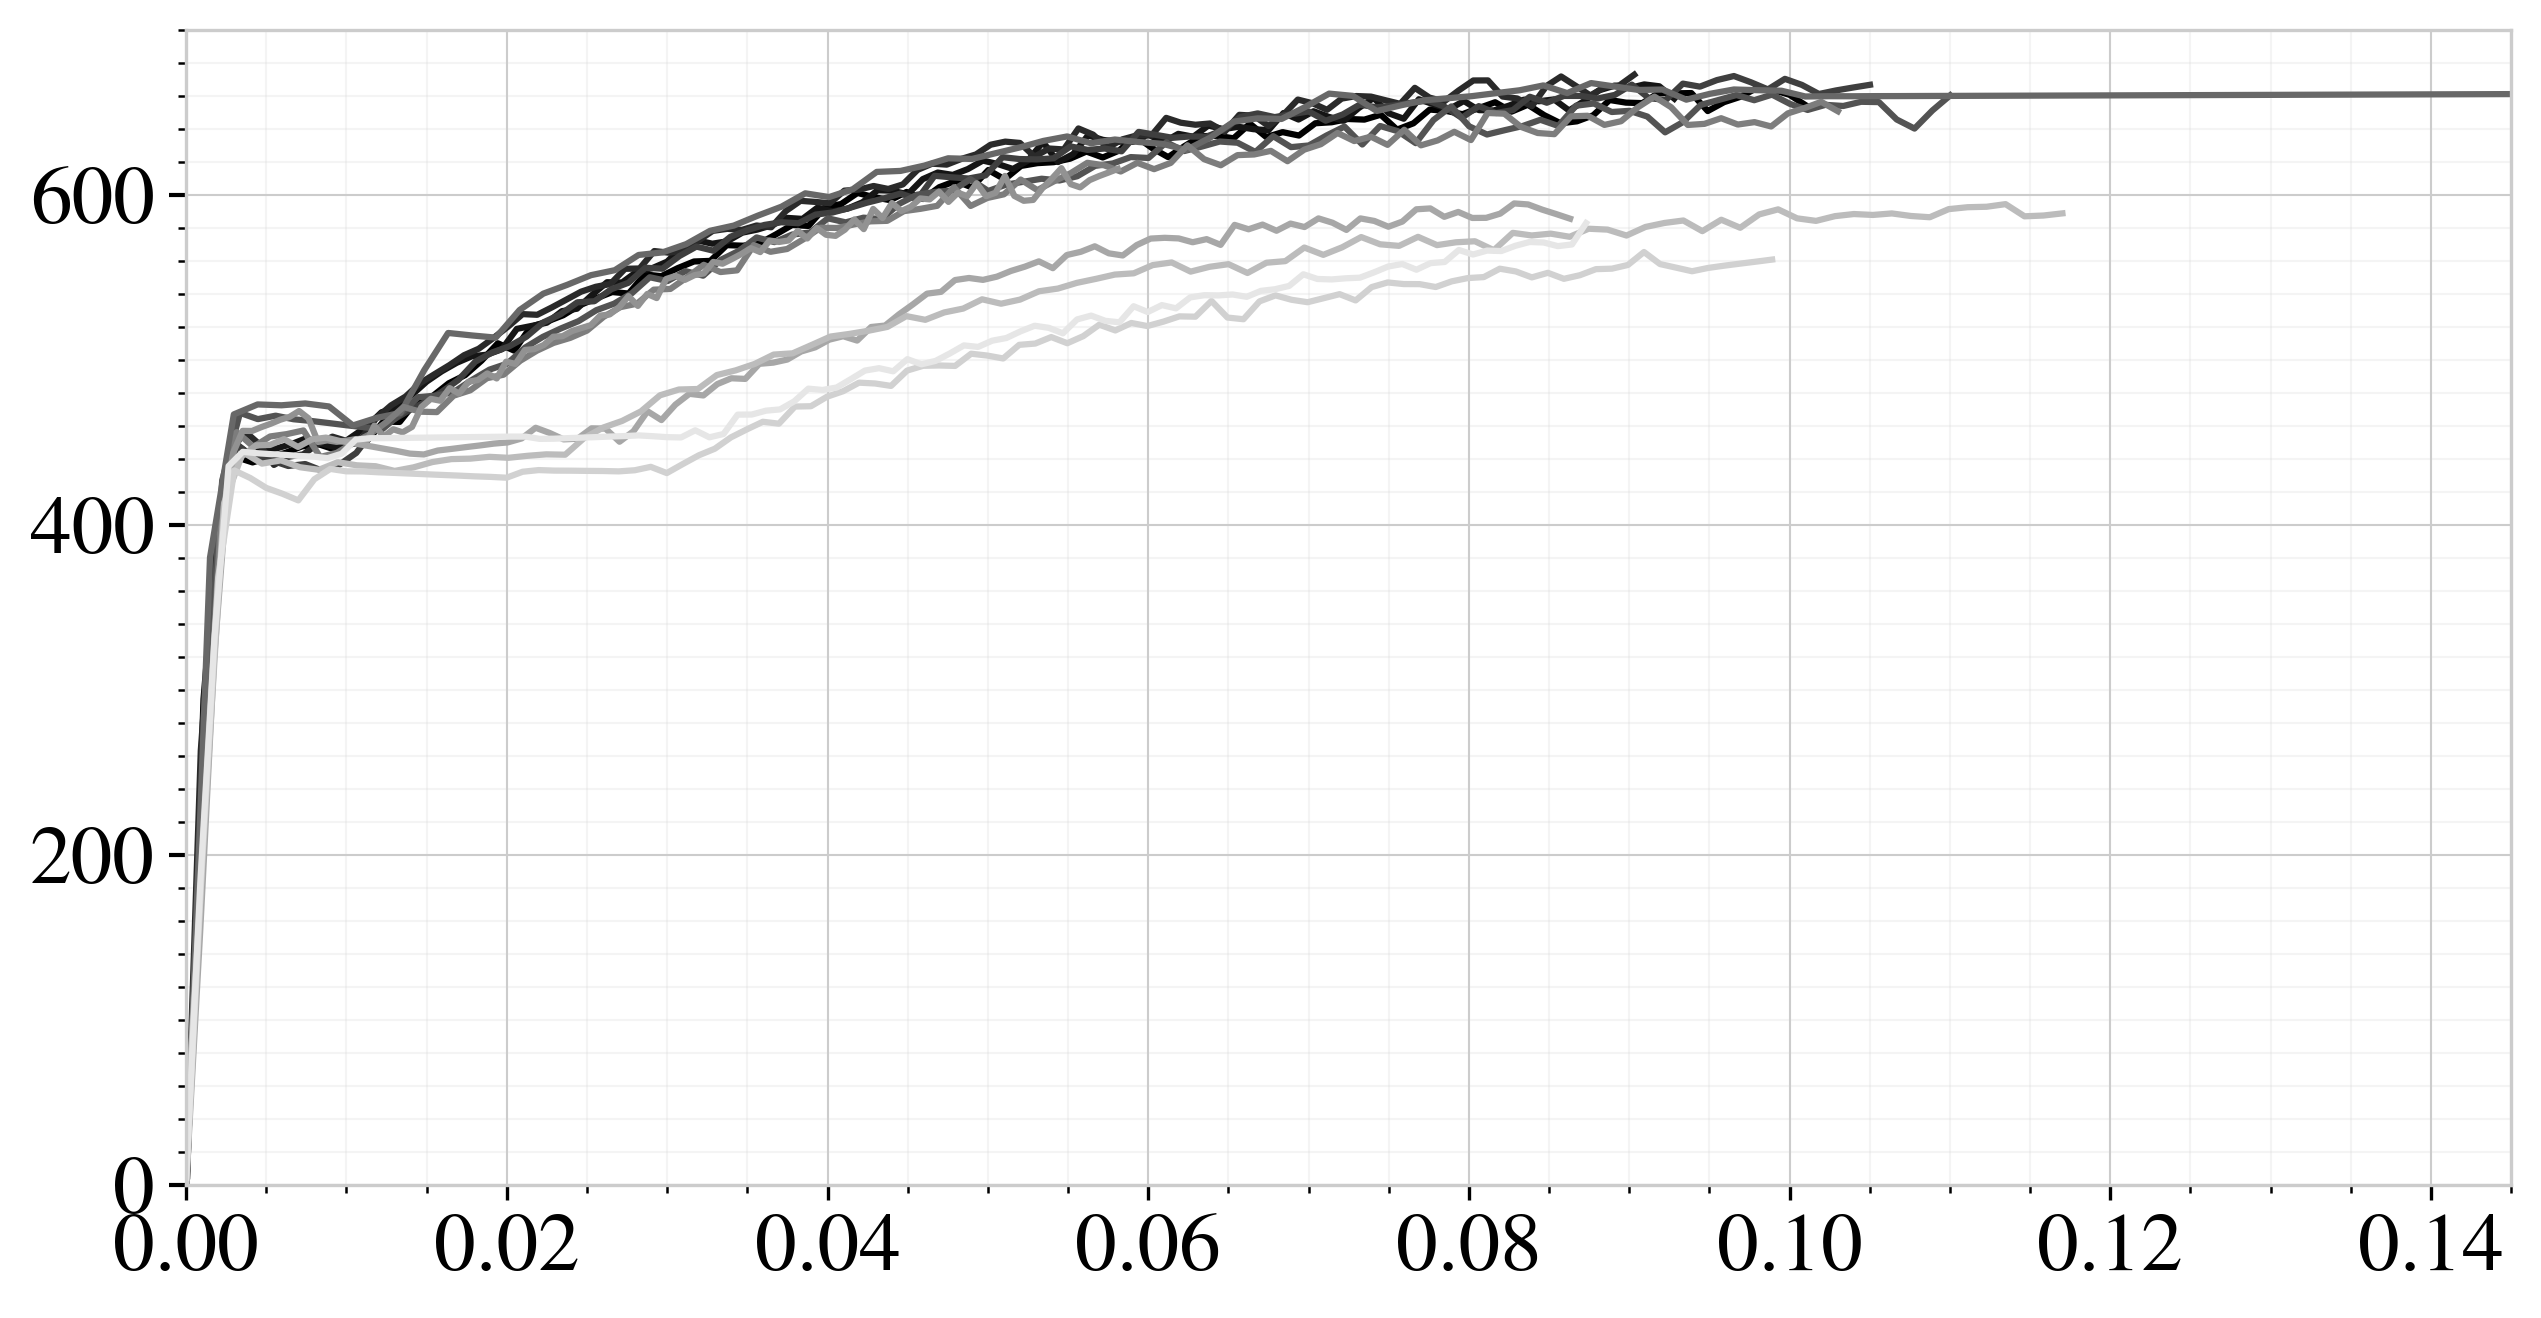

In [ ]:
def funRS(con, n_steps = 100):
  xi, yi = np.array(Data[con]['def']), np.array(Data[con]['Esf'])
  x = np.linspace(xi[0], xi[-1], n_steps)
  y = np.interp(x, xi, yi)
  return x, y

cont =  -1
fig, ax = plt.subplots(figsize=(10,5))
c = np.linspace(0, 0.90, 5)
Data2 = {}
cont2 = -1
c2 = np.linspace(0, 0.90, 12)
for i in range(3):
  for j in range(5):
    cont += 1
    if j in [0]:
      continue
    cont2 += 1
    Data2[cont2] =  {'def':[], 'Esf':[]}
    Data2[cont2]['def'], Data2[cont2]['Esf'] = funRS(cont)
    ax.plot(Data2[cont2]['def'],Data2[cont2]['Esf'],color=[c2[cont2]]*3)

ax.grid(which='minor', alpha=0.2)
ax.yaxis.grid(True, which='minor')
ax.xaxis.set_minor_locator(MultipleLocator(0.005))
ax.yaxis.set_minor_locator(MultipleLocator(20))
plt.xlim([0, 0.145])
plt.ylim([0, 700])
plt.show()

#### Units
m, cm, mm = 1, 0.1, 0.001
N, kN = 1, 1000
Pa, MPa, GPa = 1, 1e6, 1e9

## Log-like 2

In [6]:
# define a pytensor Op for our likelihood function
class LogLike(pt.Op):

    itypes = [pt.dmatrix, pt.dscalar]   # expects a vector of parameter values when called
    otypes = [pt.dvector]  # outputs a single scalar value (the log likelihood)

    def __init__(self, loglike, x, data):
      #, sigma):
        """
        Initialise the Op with various things that our log-likelihood function
        requires. Below are the things that are needed in this particular
        example.

        Parameters
        ----------
        loglike:
            The log-likelihood (or whatever) function we've defined
        data:
            The "observed" data that our log-likelihood function takes in
        x:
            The dependent variable (aka 'x') that our model requires
        sigma:
            The noise standard deviation that our function requires.
        """
        # add inputs as class attributes
        self.likelihood = loglike
        self.data = data
        self.x = x
        self.sigma = 1#sigma

    def perform(self, node, inputs, outputs):
        # the method that is used when calling the Op
        theta,sigma = inputs  # this will contain my variables

        # call the log-likelihood function
        logl = self.likelihood(theta, sigma, self.x, self.data)#, sigma)

        outputs[0][0] = np.array(logl)  # output the log-likelihood

## OpenSeesPy model

In [ ]:
def ModelSteel4(input, eps2):
    ops.logFile('logViga.txt', '-noEcho') 
    L = 0.3*m
    A = 440*mm*mm
    Fy, E0, bl, lyp, bk, Fu = input
    xi = [0]
    for i, v in enumerate(eps2[1:]):
        if v <= eps2[i]:
            xi.append(i+1)
    xi.append(len(eps2))
    y = []
    for n in range(len(xi)-1):
        eps = eps2[xi[n]:xi[n+1]]
        ni = xi[n]
        ops.wipe()
        # Modelo 1D (una dimensión) con 1 grado de libertad por nodo (solo desplazamiento X)
        ops.model('basic', '-ndm', 2, '-ndf', 2)
        matTag = 1
        # Crear nodos
        ops.node(1, 0.0, 0) # Nodo fijo
        ops.node(2, 0.0, L)   # Nodo de control de desplazamiento
        # Restricción: Fija el nodo 1
        ops.fix(1, 1, 1)
        ops.fix(2, 1, 0)
        # Material Uniaxial (Steel4)
        Ru, Ri, bi, rhoi, R0, r1, r2 = 0, 0, 0, 0, 20, 0.9, 0.15
        ops.uniaxialMaterial('Steel4', matTag, Fy[ni]*MPa, E0[ni]*GPa, '-iso', bi, rhoi, bl[ni], Ri, lyp[ni],'-kin', bk[ni], R0, r1, r2, '-ult',Fu[ni]*MPa, Ru)
        # Elemento: Truss (Celosía)
        # El elemento truss aplica el material uniaxial directamente a lo largo de su eje
        ops.element('Truss', 1, 1, 2, A, matTag)
        
        Disp_final = eps[-1] * L # Desplazamiento final
        n_steps = len(eps)              # Número de pasos
        
        # Definición del patrón de carga (Necesario incluso en DisplacementControl)
        ops.timeSeries('Constant', 1)
        ops.pattern('Plain', 1, 1)
        ops.load(2, 0, 1.0)
        # Integrador de desplazamiento
        Disp_incr = Disp_final / n_steps
        ControlNode = 2
        ControlDOF = 2
        ops.integrator('DisplacementControl', ControlNode, ControlDOF, Disp_incr)
        
        # Configuración del Solucionador
        ops.system('BandGeneral')
        ops.numberer('RCM')
        ops.constraints('Plain')
        
        ops.test('NormDispIncr', 1.0e-12, 10, 3)
        ops.algorithm('NewtonLineSearch')
        ops.analysis('Static')
        
        esfuerzos = []
        deformaciones = []
    
        for i in range(n_steps):
            # Ejecutar el análisis para un paso
            ok = ops.analyze(1)
            # Manejo de no convergencia
            if ok != 0:
                # Intenta con otro algoritmo si falla el Newton
                ops.algorithm('BFGS')
                ok = ops.analyze(1)
                ops.algorithm('NewtonLineSearch')
    
            current_disp = ops.nodeDisp(ControlNode, ControlDOF)
            ops.reactions()
            current_force = -ops.nodeReaction(1, 2)
            current_strain = current_disp / L
            current_stress = current_force / A
            
            deformaciones.append(current_strain)
            esfuerzos.append(current_stress)
    
        y.extend(esfuerzos)
    return np.array(y)/MPa

## PYMC Model

In [9]:
def loglikeSteel(theta, sigma0, eps, data):#, sigma):
  # data: Datos observados
  # theta: Vector de parámetros a ajustar
  model = ModelSteel4(theta, eps)
  sigma = sigma0
  try:
    log = -(0.5 * (np.log(2 * np.pi * sigma ** 2) + ((data - model) / sigma) ** 2))
  except:
    log = -(0.5 * (np.log(2 * np.pi * sigma ** 2) + ((data - 0) / sigma) ** 2))
  return log
def HichericalData(Data):
  # Preparación de los datos
  x = np.array([])
  y = np.array([])
  indicator = np.array([])
  BarNames = []
  for i in range(len(Data)):
    xi = Data[i]['def']
    lendata = len(xi)
    x = np.append(x, xi)
    BarNames.append('N'+str(i+1))
    yi =  Data[i]['Esf']
    y = np.concatenate([y, yi])
    # esh = np.append(esh, Data[i]['esh'])
    # eu = np.append(eu, Data[i]['eu'])
    indicator = np.append(indicator, np.ones(lendata)*(i))
  groups = i
  indicator = indicator.astype(int)
  COORDS = {"Bar":BarNames}
  return COORDS, indicator, x, y#, esh, eu
COORDS, ind, x, y = HichericalData(Data2)

In [10]:
logl = LogLike(loglikeSteel, x, y)
with pm.Model(coords = COORDS) as m_Steel:
    ## -------------------------- HYPERPRIORS --------------------------
    ## ----- Informadas
    mu_Fy = pm.Normal('mu_Fy', mu=436.3)
    sigma_Fy = pm.HalfNormal('sigma_Fy', sigma=26.7)
    mu_E0 = pm.Normal('mu_E0', mu=207.4)
    sigma_E0 = pm.HalfNormal('sigma_E0', sigma=36.4)
    mu_Fu = pm.Normal('mu_Fu', mu=620.7)
    sigma_Fu = pm.HalfNormal('sigma_Fu', sigma=44.9)
    ## ----- No informadas
    mu_bl = pm.Uniform('mu_bl',lower=0.01, upper=0.05)
    sigma_bl = pm.HalfNormal('sigma_bl', sigma=0.01)
    mu_lyp = pm.Uniform('mu_lyp', lower=0.1, upper=5)
    sigma_lyp = pm.HalfNormal('sigma_lyp', sigma=0.1)
    mu_bk = pm.Uniform('mu_bk', lower=0.01, upper=0.1)
    sigma_bk = pm.HalfNormal('sigma_bk', sigma=0.05)
    #
    # mu_Ru = pm.Normal('mu_Ru', mu=300, sigma=10)
    # sigma_Ru = pm.HalfNormal('sigma_Ru', sigma=10)
    
    ## -------------------------- PRIORS --------------------------
    Fy = pm.Normal('Fy', mu=mu_Fy, sigma=sigma_Fy, dims='Bar')
    E0 = pm.Normal('E0', mu=mu_E0, sigma=sigma_E0, dims='Bar')
    Fu = pm.Normal('Fu', mu=mu_Fu, sigma=sigma_Fu, dims='Bar')
    bl = pm.Normal('bl', mu=mu_bl, sigma=sigma_bl, dims='Bar')
    lyp = pm.Normal('lyp', mu=mu_lyp, sigma=sigma_lyp, dims='Bar')
    bk = pm.Normal('bk', mu=mu_bk, sigma=sigma_bk, dims='Bar')
    # Ru = pm.Normal('Ru', mu=mu_Ru, sigma=sigma_Ru, dims='Bar')
    
    sigma = pm.HalfNormal('sigma')
    theta = pt.as_tensor_variable([Fy[ind], E0[ind], bl[ind], lyp[ind], bk[ind], Fu[ind]])
    ## -------------------------- LIKELIHOOD --------------------------
    pm.Potential("likelihood", logl(theta, sigma))
    ## -------------------------- STEP AND SAMPLE --------------------------
    idata = pm.sample(2000, tune=500, chains=4)

C:\Users\Felipe\anaconda3\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1030: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
C:\Users\Felipe\anaconda3\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1030: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [mu_Fy, sigma_Fy, mu_E0, sigma_E0, mu_Fu, sigma_Fu, mu_bl, sigma_bl, mu_lyp, sigma_lyp, mu_bk, sigma_bk]
>CompoundStep
>>Metropolis: [Fy]
>>Metropolis: [E0]
>>Metropolis: [Fu]
>>Metropolis: [bl]
>>Metropolis: [lyp]
>>Metropolis: [bk]
>Slice: [sigma]


Output()

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 49775 seconds.
There were 1911 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


### distribuciones

In [26]:
rng = np.random.default_rng(20250511)
vars = ['Fy', 'E0', 'bl', 'lyp', 'bk', 'Fu'] 
idataR = {}
for var in vars:
  mu = idata.posterior['mu_'+var]#.stack(sample=("chain", "draw")).values
  sigma = idata.posterior['sigma_'+var]#.stack(sample=("chain", "draw")).values
  idataR[var] = rng.normal(loc=mu, scale=sigma)
idataR['sigma'] = idata.posterior['sigma']#.stack(sample=("chain", "draw")).values

array([[<Axes: title={'center': 'Fy'}>, <Axes: title={'center': 'E0'}>,
        <Axes: title={'center': 'bl'}>],
       [<Axes: title={'center': 'lyp'}>, <Axes: title={'center': 'bk'}>,
        <Axes: title={'center': 'Fu'}>],
       [<Axes: title={'center': 'sigma'}>, <Axes: >, <Axes: >]],
      dtype=object)

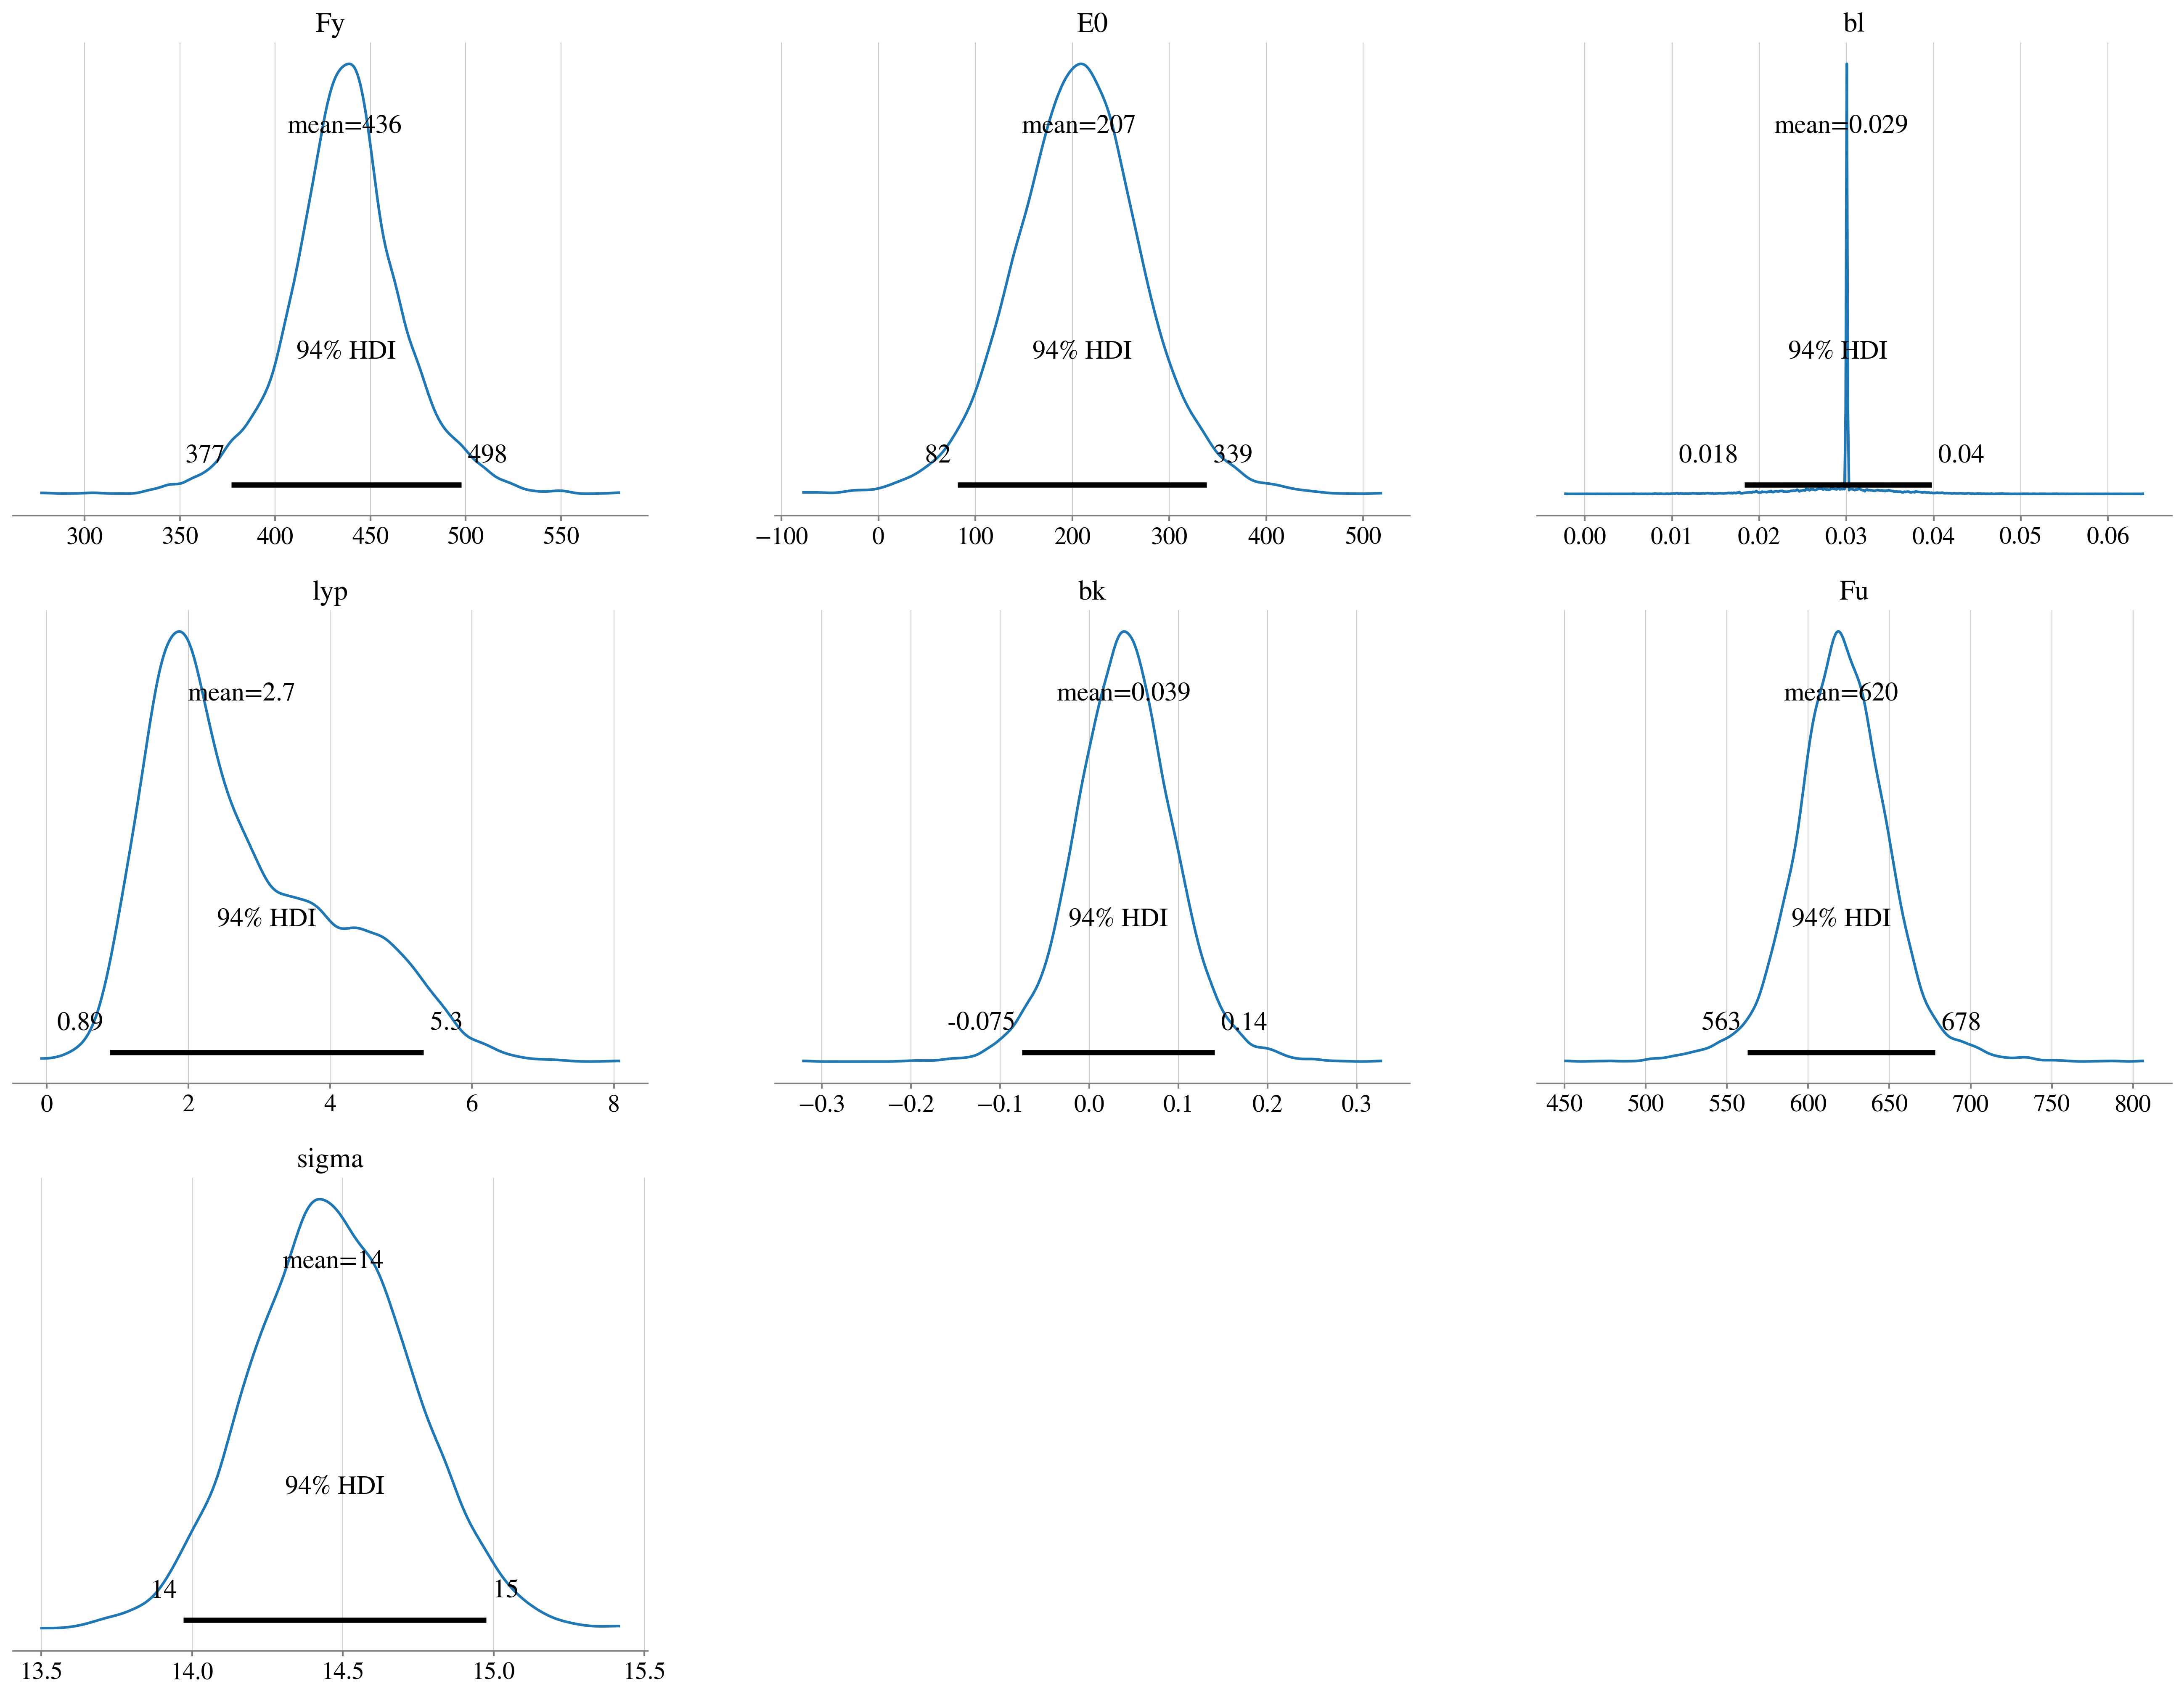

In [27]:
az.plot_posterior(idataR)

## Prueba parametrización no centrada

In [33]:
with pm.Model(coords=COORDS) as m_Steel2:
    ## -------------------------- HYPERPRIORS --------------------------
    mu_Fy = pm.Normal('mu_Fy', mu=436.3)
    sigma_Fy = pm.HalfNormal('sigma_Fy', sigma=26.7)
    
    mu_E0 = pm.Normal('mu_E0', mu=207.4)
    sigma_E0 = pm.HalfNormal('sigma_E0', sigma=36.4)
    
    mu_Fu = pm.Normal('mu_Fu', mu=620.7)
    sigma_Fu = pm.HalfNormal('sigma_Fu', sigma=44.9)
    
    mu_bl = pm.Uniform('mu_bl', lower=0.01, upper=0.05)
    sigma_bl = pm.HalfNormal('sigma_bl', sigma=0.01)
    
    mu_lyp = pm.Uniform('mu_lyp', lower=0.1, upper=5)
    sigma_lyp = pm.HalfNormal('sigma_lyp', sigma=0.1)
    
    mu_bk = pm.Uniform('mu_bk', lower=0.01, upper=0.1)
    sigma_bk = pm.HalfNormal('sigma_bk', sigma=0.05)
    
    ## -------------------------- PRIORS (NO CENTRADAS) --------------------------
    # 1. Creamos el offset (el "error" estándar por cada barra)
    # 2. Calculamos el valor real: mu + offset * sigma
    
    Fy_off = pm.Normal('Fy_off', mu=0, sigma=1, dims='Bar')
    Fy = pm.Deterministic('Fy', mu_Fy + Fy_off * sigma_Fy, dims='Bar')
    
    E0_off = pm.Normal('E0_off', mu=0, sigma=1, dims='Bar')
    E0 = pm.Deterministic('E0', mu_E0 + E0_off * sigma_E0, dims='Bar')
    
    Fu_off = pm.Normal('Fu_off', mu=0, sigma=1, dims='Bar')
    Fu = pm.Deterministic('Fu', mu_Fu + Fu_off * sigma_Fu, dims='Bar')
    
    bl_off = pm.Normal('bl_off', mu=0, sigma=1, dims='Bar')
    bl = pm.Deterministic('bl', mu_bl + bl_off * sigma_bl, dims='Bar')
    
    lyp_off = pm.Normal('lyp_off', mu=0, sigma=1, dims='Bar')
    lyp = pm.Deterministic('lyp', mu_lyp + lyp_off * sigma_lyp, dims='Bar')
    
    bk_off = pm.Normal('bk_off', mu=0, sigma=1, dims='Bar')
    bk = pm.Deterministic('bk', mu_bk + bk_off * sigma_bk, dims='Bar')
    
    # Error del modelo
    sigma = pm.HalfNormal('sigma')
    
    # Theta se sigue armando igual porque Fy, E0, etc. siguen existiendo como Deterministic
    theta = pt.as_tensor_variable([Fy[ind], E0[ind], bl[ind], lyp[ind], bk[ind], Fu[ind]])
    
    ## -------------------------- LIKELIHOOD --------------------------
    pm.Potential("likelihood", logl(theta, sigma))
    
    ## -------------------------- STEP AND SAMPLE --------------------------
    # Aumentamos target_accept para mayor seguridad contra divergencias residuales
    idata2 = pm.sample(
        draws=2000, 
        tune=1 000, 
        chains=4,
    )


C:\Users\Felipe\anaconda3\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1030: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
C:\Users\Felipe\anaconda3\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1030: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
C:\Users\Felipe\anaconda3\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1030: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
C:\Users\Felipe\anaconda3\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1030: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
C:\Users\Felipe\anaconda3\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1030: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
C:\Users\Felipe\anaconda3

Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 20817 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [44]:
idatas=az.summary(idata2)

In [ ]:
rng = np.random.default_rng(20260610)
vars = ['Fy', 'E0', 'bl', 'lyp', 'bk', 'Fu'] 
idataR2 = {}
for var in vars:
  mu = idata2.posterior['mu_'+var]#.stack(sample=("chain", "draw")).values
  sigma = idata2.posterior['sigma_'+var]#.stack(sample=("chain", "draw")).values
  idataR2[var] = rng.normal(loc=mu, scale=sigma)
idataR2['sigma'] = idata2.posterior['sigma']#.stack(sample=("chain", "draw")).values

In [ ]:
az.plot_posterior(idataR2)

# Watermark

In [ ]:
import watermark
%load_ext watermark
%watermark -n -u -v -iv -w -p xarray